
Loaded basin metadata
Metadata path: /data/basin2vec/cache/metadata/basin_metadata.parquet
Site ID column: site_id
Integer ID column: site_id_int
Number of metadata basins: 9067
Metadata features: ['log_area_km2_z', 'log_bbox_width_km_z', 'log_bbox_height_km_z', 'log_patch_pixel_width_km_z', 'log_patch_pixel_height_km_z', 'log_patch_pixel_area_km2_z', 'bbox_fill_fraction_z', 'compactness_z', 'solidity_z', 'log_shape_index_z', 'log_overlap_degree_z']

Using overlap score column: overlap_score
Overlap threshold: > 0.5
Overlap/nested basin pairs: 34291

##########################################################################################
Processing model: Basin2Vec
##########################################################################################

Basin2Vec NPZ keys: ../src/evaluation_outputs/HCLV4_grouped_monthly_static_meta_areaaux_64d/basin_embeddings_full.npz
embeddings                          shape=(362680, 64), dtype=float32
hydrologic_repr                     shape=(

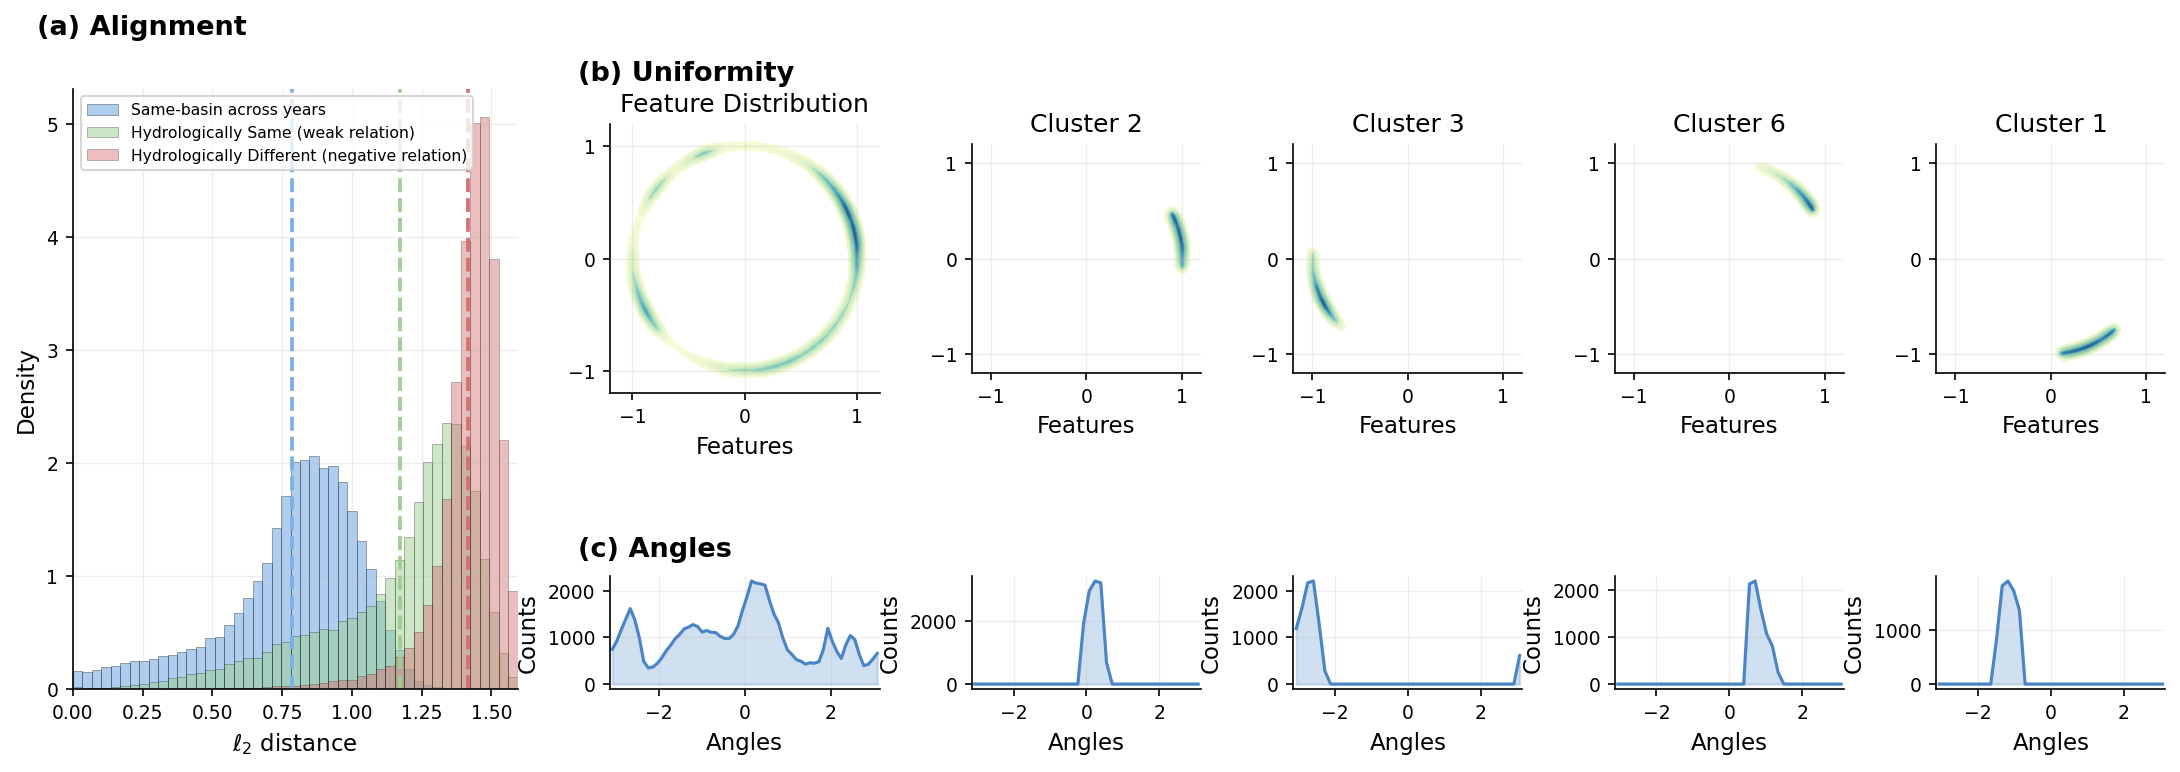


Saved Basin2Vec detailed summary:
paper_results_basin2vec_alignment_uniformity/tables/basin2vec_alignment_detailed_summary.csv

Saved Basin2Vec grouped summary:
paper_results_basin2vec_alignment_uniformity/tables/basin2vec_alignment_grouped_summary.csv

Done.
Figure outputs:
paper_results_basin2vec_alignment_uniformity/figures/fig_basin2vec_alignment_uniformity.pdf
paper_results_basin2vec_alignment_uniformity/figures/fig_basin2vec_alignment_uniformity.png


In [3]:
#!/usr/bin/env python3
# ==========================================================
# Basin2Vec-only alignment + uniformity plots
#
# This keeps the same representation/style as the original code:
#   (a) grouped relation-aware pair-distance histogram
#   (b) overall feature distribution
#   (c) overall angular distribution
#   + cluster-level feature/angle panels
#
# Basin2Vec relations:
#   - Same-basin across years
#   - Hydrologically related / weak relation
#       = overlap/nested + metadata-similar non-overlap
#   - Strong negative relation
#       = metadata-dissimilar non-overlap + random non-overlap
#
# Output:
#   paper_results_basin2vec_alignment_uniformity/
#       figures/
#           fig_basin2vec_alignment_uniformity.png
#           fig_basin2vec_alignment_uniformity.pdf
#       tables/
#           basin2vec_alignment_detailed_summary.csv
#           basin2vec_alignment_grouped_summary.csv
# ==========================================================

from __future__ import annotations

from pathlib import Path
from collections import defaultdict
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from scipy.ndimage import gaussian_filter
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")


# ==========================================================
# CONFIG
# ==========================================================

SEED = 42
RNG = np.random.default_rng(SEED)

BASIN2VEC_NPZ = Path(
    "../src/evaluation_outputs/HCLV4_grouped_monthly_static_meta_areaaux_64d/"
    "basin_embeddings_full.npz"
)

BASIN_METADATA = Path(
    "/data/basin2vec/cache/metadata/basin_metadata.parquet"
)

OVERLAP_PAIRS_PARQUET = Path(
    "/data/basin2vec/cache/basin_overlap_pairs.parquet"
)

MODEL_NAME = "Basin2Vec"
PREFERRED_EMBEDDING_KEY = "embeddings"
PREFER_3D_POINTS = False

OVERLAP_THRESHOLD = 0.50

RESULTS_DIR = Path("paper_results_basin2vec_alignment_uniformity")
FIG_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

MAX_SAME_BASIN_PAIRS = 50_000
MAX_OVERLAP_PAIRS = 50_000
MAX_META_SIMILAR_PAIRS = 50_000
MAX_META_DISSIMILAR_PAIRS = 50_000
MAX_RANDOM_NEG_PAIRS = 50_000

META_SIMILAR_NEIGHBORS = 40
META_DISSIMILAR_CANDIDATES = 500_000

N_VIS = 60_000
N_CLUSTERS = 8
N_CLUSTER_PANELS = 4

DEFAULT_METADATA_COLUMNS = [
    "log_area_km2_z",
    "log_bbox_width_km_z",
    "log_bbox_height_km_z",
    "log_patch_pixel_width_km_z",
    "log_patch_pixel_height_km_z",
    "log_patch_pixel_area_km2_z",
    "bbox_fill_fraction_z",
    "compactness_z",
    "solidity_z",
    "log_shape_index_z",
    "log_overlap_degree_z",
]

plt.rcParams.update({
    "figure.figsize": (18, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "figure.dpi": 150,
    "savefig.dpi": 300,
})


# ==========================================================
# BASIC HELPERS
# ==========================================================

def normalize_site_id(x) -> str | None:
    if pd.isna(x):
        return None

    s = str(x).strip()

    if s.endswith(".0"):
        s = s[:-2]

    digits = re.sub(r"\D", "", s)

    if len(digits) > 0:
        if len(digits) <= 8:
            return digits.zfill(8)
        return digits

    if len(s) == 0:
        return None

    return s


def l2_normalize(x, eps=1e-12):
    x = np.asarray(x, dtype=np.float32)
    return x / np.clip(np.linalg.norm(x, axis=1, keepdims=True), eps, None)


def pair_distances(x, pairs):
    pairs = np.asarray(pairs, dtype=np.int64)

    if pairs.size == 0:
        return np.empty(0, dtype=np.float32)

    pairs = pairs.reshape(-1, 2)
    i = pairs[:, 0]
    j = pairs[:, 1]

    return np.linalg.norm(x[i] - x[j], axis=1).astype(np.float32)


def savefig(path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, bbox_inches="tight", dpi=300)
    print(f"Saved: {path}")


def slugify(s):
    return re.sub(r"[^a-z0-9]+", "_", s.lower()).strip("_")


def is_numeric_array(arr):
    return np.issubdtype(np.asarray(arr).dtype, np.number)


def infer_year_from_filename(npz_path: Path) -> int | None:
    matches = re.findall(r"(?<!\d)(19\d{2}|20\d{2})(?!\d)", npz_path.name)

    if len(matches) == 0:
        return None

    return int(matches[-1])


def infer_site_id_column(df):
    candidates = [
        "site_id",
        "siteid",
        "gage_id",
        "gageid",
        "gauge_id",
        "gaugeid",
        "station_id",
        "staid",
        "site_no",
        "usgs_id",
        "basin_id",
        "GAGE_ID",
        "STAID",
    ]

    lower = {str(c).lower(): c for c in df.columns}

    for c in candidates:
        if c.lower() in lower:
            return lower[c.lower()]

    return None


def infer_site_id_int_column(df):
    candidates = [
        "site_id_int",
        "site_int",
        "gage_id_int",
        "basin_id_int",
        "basin_index",
        "basin_idx",
        "index",
    ]

    lower = {str(c).lower(): c for c in df.columns}

    for c in candidates:
        if c.lower() in lower:
            return lower[c.lower()]

    return None


# ==========================================================
# NPZ LOADER
# ==========================================================

def print_npz_keys(npz_path, model_name):
    data = np.load(npz_path, allow_pickle=True)

    print("\n" + "=" * 80)
    print(f"{model_name} NPZ keys: {npz_path}")
    print("=" * 80)

    for k in data.files:
        arr = data[k]
        print(f"{k:35s} shape={arr.shape}, dtype={arr.dtype}")

    return data


def choose_embedding_array(
    data,
    preferred_key: str | None,
    model_name: str,
    prefer_3d_points: bool = False,
):
    if preferred_key is not None and preferred_key in data.files:
        arr = np.asarray(data[preferred_key])
        return preferred_key, arr.astype(np.float32)

    candidates = [
        "point_embeddings",
        "pointwise_embeddings",
        "embeddings_8point",
        "embeddings_8points",
        "basin_point_embeddings",
        "embeddings",
        "embedding",
        "raw_embeddings",
        "basin_embeddings",
        "avg_embeddings",
        "hydrologic_repr",
        "z",
        "features",
    ]

    if prefer_3d_points:
        for key in candidates:
            if key in data.files:
                arr = np.asarray(data[key])
                if is_numeric_array(arr) and arr.ndim == 3:
                    return key, arr.astype(np.float32)

        numeric_3d = []

        for key in data.files:
            arr = np.asarray(data[key])
            if is_numeric_array(arr) and arr.ndim == 3:
                numeric_3d.append((arr.size, key, arr))

        if len(numeric_3d) > 0:
            _, key, arr = max(numeric_3d, key=lambda x: x[0])
            print(f"Warning: using auto-detected 3D embedding key for {model_name}: {key}")
            return key, arr.astype(np.float32)

    for key in candidates:
        if key in data.files:
            arr = np.asarray(data[key])
            if is_numeric_array(arr) and arr.ndim in (2, 3):
                return key, arr.astype(np.float32)

    numeric = []

    for key in data.files:
        arr = np.asarray(data[key])
        if is_numeric_array(arr) and arr.ndim in (2, 3):
            numeric.append((arr.size, key, arr))

    if len(numeric) > 0:
        _, key, arr = max(numeric, key=lambda x: x[0])
        print(f"Warning: using auto-detected embedding key for {model_name}: {key}")
        return key, arr.astype(np.float32)

    raise KeyError(
        f"Could not find embedding array for {model_name}. "
        f"Available keys: {data.files}"
    )


def choose_site_ids(data, model_name, n_expected):
    candidates = [
        "labels",
        "avg_labels",
        "site_ids",
        "site_id",
        "gage_ids",
        "gauge_ids",
        "basin_ids",
        "basin_id",
        "ids",
        "id",
    ]

    for key in candidates:
        if key in data.files:
            arr = np.asarray(data[key])
            if arr.ndim == 1 and len(arr) == n_expected:
                return key, arr

    skip_patterns = [
        "year",
        "embedding",
        "feature",
        "coord",
        "lat",
        "lon",
        "x",
        "y",
        "point",
        "dim",
    ]

    for key in data.files:
        key_lower = key.lower()

        if any(p in key_lower for p in skip_patterns):
            continue

        arr = np.asarray(data[key])

        if arr.ndim != 1 or len(arr) != n_expected:
            continue

        if arr.dtype.kind not in {"O", "U", "S", "i", "u"}:
            continue

        if np.issubdtype(arr.dtype, np.number):
            arr_min = np.nanmin(arr)
            arr_max = np.nanmax(arr)

            if 1900 <= arr_min <= 2100 and 1900 <= arr_max <= 2100:
                continue

        print(f"Warning: using auto-detected site-id key for {model_name}: {key}")
        return key, arr

    raise KeyError(
        f"Could not find site/basin ID array for {model_name} with length {n_expected}. "
        f"Available keys: {data.files}"
    )


def choose_site_ids_int(data, n_expected):
    candidates = [
        "site_ids_int",
        "site_id_int",
        "label_ints",
        "basin_ids_int",
        "basin_id_int",
    ]

    for key in candidates:
        if key in data.files:
            arr = np.asarray(data[key])
            if arr.ndim == 1 and len(arr) == n_expected:
                return key, arr.astype(int)

    return None, None


def choose_years(data, model_name, n_expected, npz_path):
    candidates = [
        "years",
        "year",
        "sample_years",
        "embedding_years",
    ]

    for key in candidates:
        if key in data.files:
            arr = np.asarray(data[key])
            if arr.ndim == 1 and len(arr) == n_expected:
                return key, arr.astype(int)

    inferred_year = infer_year_from_filename(npz_path)

    if inferred_year is not None:
        years = np.full(n_expected, inferred_year, dtype=int)
        print(
            f"{model_name}: no year array found; inferred year={inferred_year} "
            f"from filename {npz_path.name}."
        )
        return "inferred_from_filename", years

    raise KeyError(
        f"Could not find years array for {model_name}, and no year could be "
        f"inferred from filename: {npz_path.name}. Available keys: {data.files}"
    )


def flatten_or_keep_embeddings(emb_raw, df_base, model_name, emb_key):
    emb_raw = np.asarray(emb_raw, dtype=np.float32)

    if emb_raw.ndim == 2:
        df = df_base.copy()
        df["point_id"] = 0

        if df["year"].nunique() > 1:
            same_mode = "years"
            same_label = "Same-basin across years"
        else:
            same_mode = "single_sample"
            same_label = "Same-basin"

        return df, emb_raw, same_mode, same_label

    if emb_raw.ndim == 3:
        n_basins, n_points, dim = emb_raw.shape

        if len(df_base) != n_basins:
            raise ValueError(
                f"{model_name}: 3D embedding first dimension does not match metadata. "
                f"emb.shape[0]={n_basins}, len(df_base)={len(df_base)}"
            )

        print(
            f"{model_name}: embedding key '{emb_key}' is 3D {emb_raw.shape}; "
            "flattening sampled points instead of averaging."
        )

        emb = emb_raw.reshape(n_basins * n_points, dim).astype(np.float32)

        df = df_base.loc[df_base.index.repeat(n_points)].copy().reset_index(drop=True)
        df["point_id"] = np.tile(np.arange(n_points), n_basins)

        same_mode = "points"
        same_label = f"Same-basin across {n_points} sampled points"

        return df, emb, same_mode, same_label

    raise ValueError(
        f"{model_name}: embedding array must be 2D or 3D. "
        f"Got shape={emb_raw.shape}."
    )


def load_embedding_npz(
    npz_path,
    model_name,
    preferred_embedding_key=None,
    prefer_3d_points=False,
):
    npz_path = Path(npz_path)

    if not npz_path.exists():
        raise FileNotFoundError(f"{model_name} NPZ not found: {npz_path}")

    data = print_npz_keys(npz_path, model_name)

    emb_key, emb_raw = choose_embedding_array(
        data=data,
        preferred_key=preferred_embedding_key,
        model_name=model_name,
        prefer_3d_points=prefer_3d_points,
    )

    n_base = emb_raw.shape[0]

    site_key, site_ids_raw = choose_site_ids(
        data=data,
        model_name=model_name,
        n_expected=n_base,
    )

    site_int_key, site_ids_int = choose_site_ids_int(
        data=data,
        n_expected=n_base,
    )

    year_key, years = choose_years(
        data=data,
        model_name=model_name,
        n_expected=n_base,
        npz_path=npz_path,
    )

    site_ids = np.array([normalize_site_id(x) for x in site_ids_raw], dtype=object)

    df_base = pd.DataFrame({
        "site_id": site_ids,
        "year": years.astype(int),
    })

    if site_ids_int is not None:
        df_base["site_id_int"] = site_ids_int.astype(int)

    valid = df_base["site_id"].notna().to_numpy()
    df_base = df_base.loc[valid].reset_index(drop=True)
    emb_raw = emb_raw[valid]

    df, emb, same_mode, same_label = flatten_or_keep_embeddings(
        emb_raw=emb_raw,
        df_base=df_base,
        model_name=model_name,
        emb_key=emb_key,
    )

    emb = l2_normalize(emb)

    metadata = {
        "model_name": model_name,
        "npz_path": str(npz_path),
        "embedding_key": emb_key,
        "site_key": site_key,
        "site_int_key": site_int_key,
        "year_key": year_key,
        "raw_embedding_shape": tuple(emb_raw.shape),
        "n_samples": int(len(df)),
        "n_unique_basins_before_metadata": int(df["site_id"].nunique()),
        "n_years": int(df["year"].nunique()),
        "min_year": int(df["year"].min()),
        "max_year": int(df["year"].max()),
        "embedding_dim": int(emb.shape[1]),
        "same_mode": same_mode,
        "same_label": same_label,
    }

    print("\nLoaded:", model_name)
    for k, v in metadata.items():
        print(f"  {k}: {v}")

    return df, emb, metadata


# ==========================================================
# METADATA + OVERLAP
# ==========================================================

def load_basin_metadata(metadata_path):
    metadata_path = Path(metadata_path)

    if not metadata_path.exists():
        raise FileNotFoundError(f"Could not find metadata parquet: {metadata_path}")

    meta = pd.read_parquet(metadata_path).copy()

    site_col = infer_site_id_column(meta)
    int_col = infer_site_id_int_column(meta)

    if site_col is not None:
        meta["site_id"] = meta[site_col].apply(normalize_site_id)
    else:
        raise RuntimeError("Could not infer site ID column from metadata parquet.")

    if int_col is not None:
        meta["site_id_int"] = pd.to_numeric(meta[int_col], errors="coerce").astype("Int64")
    else:
        raise RuntimeError("Could not infer integer basin ID column from metadata parquet.")

    feature_cols = [c for c in DEFAULT_METADATA_COLUMNS if c in meta.columns]

    if len(feature_cols) == 0:
        exclude = {
            site_col,
            int_col,
            "site_id",
            "site_id_int",
            "year",
            "lat",
            "lon",
            "latitude",
            "longitude",
        }

        numeric_cols = []

        for c in meta.columns:
            if c in exclude:
                continue

            x = pd.to_numeric(meta[c], errors="coerce")

            if x.notna().mean() >= 0.70 and x.std(skipna=True) > 1e-12:
                meta[c] = x
                numeric_cols.append(c)

        feature_cols = numeric_cols

    if len(feature_cols) == 0:
        raise RuntimeError("No usable metadata feature columns found.")

    for c in feature_cols:
        meta[c] = pd.to_numeric(meta[c], errors="coerce")
        meta[c] = meta[c].fillna(meta[c].median(skipna=True))

    X = meta[feature_cols].to_numpy(dtype=np.float32)
    X = (X - X.mean(axis=0, keepdims=True)) / np.clip(
        X.std(axis=0, keepdims=True),
        1e-6,
        None,
    )

    meta_features = meta[["site_id", "site_id_int"] + feature_cols].copy()
    meta_features[feature_cols] = X

    meta_features = meta_features.dropna(subset=["site_id", "site_id_int"]).copy()
    meta_features["site_id_int"] = meta_features["site_id_int"].astype(int)

    meta_features = meta_features.drop_duplicates(
        subset=["site_id_int"],
        keep="first",
    )

    print("\nLoaded basin metadata")
    print("Metadata path:", metadata_path)
    print("Site ID column:", site_col)
    print("Integer ID column:", int_col)
    print("Number of metadata basins:", len(meta_features))
    print("Metadata features:", feature_cols)

    return meta_features, feature_cols


def attach_int_ids_from_metadata(sample_df, emb, meta_features, model_name):
    sample_df = sample_df.copy()

    mapper = (
        meta_features[["site_id", "site_id_int"]]
        .dropna()
        .drop_duplicates(subset=["site_id"])
        .set_index("site_id")["site_id_int"]
        .to_dict()
    )

    mapped = sample_df["site_id"].map(mapper)

    if "site_id_int" in sample_df.columns:
        sample_df["site_id_int_original"] = sample_df["site_id_int"]
        sample_df["site_id_int"] = mapped.combine_first(sample_df["site_id_int"])
    else:
        sample_df["site_id_int"] = mapped

    missing = int(sample_df["site_id_int"].isna().sum())

    if missing > 0:
        print(
            f"Warning: {model_name}: {missing} rows could not be mapped to metadata site_id_int. "
            "Dropping those rows."
        )

    valid = sample_df["site_id_int"].notna().to_numpy()
    sample_df = sample_df.loc[valid].reset_index(drop=True)
    emb = emb[valid]

    sample_df["site_id_int"] = sample_df["site_id_int"].astype(int)

    print(
        f"{model_name}: after metadata mapping: "
        f"samples={len(sample_df)}, basins={sample_df['site_id_int'].nunique()}"
    )

    return sample_df, emb


def load_overlap_pairs_for_eval(path, threshold=0.5):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Could not find overlap pair parquet: {path}")

    df = pd.read_parquet(path).copy()

    required = {"site_id_int_a", "site_id_int_b"}
    missing = required - set(df.columns)

    if missing:
        raise ValueError(f"{path} missing required columns: {sorted(missing)}")

    score_candidates = [
        "overlap_score",
        "score",
        "overlap",
        "iou",
        "overlap_frac",
        "overlap_fraction",
    ]

    score_col = None

    for c in score_candidates:
        if c in df.columns:
            score_col = c
            break

    if score_col is not None:
        df = df[df[score_col] > threshold].copy()
        print(f"\nUsing overlap score column: {score_col}")
        print(f"Overlap threshold: > {threshold}")
    else:
        print("\nNo overlap score column found. Using all overlap pairs.")

    df["site_id_int_a"] = df["site_id_int_a"].astype(int)
    df["site_id_int_b"] = df["site_id_int_b"].astype(int)

    df = df[df["site_id_int_a"] != df["site_id_int_b"]].copy()

    print("Overlap/nested basin pairs:", len(df))

    return df, score_col


def build_overlap_set(overlap_df):
    overlap_set = set()

    for _, row in overlap_df.iterrows():
        a = int(row["site_id_int_a"])
        b = int(row["site_id_int_b"])

        if a == b:
            continue

        overlap_set.add((a, b))
        overlap_set.add((b, a))

    return overlap_set


# ==========================================================
# BASIN-LEVEL AVERAGE EMBEDDINGS
# ==========================================================

def compute_basin_average_embeddings(sample_df, emb, model_name):
    df = sample_df.copy()
    df["row"] = np.arange(len(df))

    rows = []
    avg_embs = []

    for sid_int, sub in df.groupby("site_id_int", sort=True):
        idx = sub["row"].to_numpy(dtype=int)

        z = emb[idx].mean(axis=0, keepdims=True)
        z = l2_normalize(z)[0]

        if sub["site_id"].notna().any():
            site_id = sub["site_id"].dropna().astype(str).iloc[0]
        else:
            site_id = str(sid_int)

        rows.append({
            "site_id_int": int(sid_int),
            "site_id": site_id,
            "n_samples": int(len(sub)),
            "n_years": int(sub["year"].nunique()),
            "min_year": int(sub["year"].min()),
            "max_year": int(sub["year"].max()),
        })

        avg_embs.append(z)

    avg_df = pd.DataFrame(rows)
    avg_emb = np.stack(avg_embs, axis=0).astype(np.float32)

    print(f"\n{model_name}: computed basin-level averaged embeddings")
    print("Basin-level embeddings:", avg_emb.shape)
    print("Basins:", len(avg_df))
    print("Samples per basin summary:")
    print(avg_df["n_samples"].describe())

    return avg_df, avg_emb


def prepare_avg_metadata(avg_df, avg_emb, meta_features, feature_cols, model_name):
    avg_df2 = avg_df.copy()
    avg_df2["avg_index"] = np.arange(len(avg_df2))

    merged = avg_df2.merge(
        meta_features[["site_id_int"] + feature_cols],
        on="site_id_int",
        how="inner",
    )

    if len(merged) == 0:
        raise RuntimeError(f"{model_name}: no basin-level embeddings matched to metadata.")

    emb2 = avg_emb[merged["avg_index"].to_numpy(dtype=int)]

    X_meta = merged[feature_cols].to_numpy(dtype=np.float32)
    X_meta = (X_meta - X_meta.mean(axis=0, keepdims=True)) / np.clip(
        X_meta.std(axis=0, keepdims=True),
        1e-6,
        None,
    )

    merged = merged.reset_index(drop=True)

    print(f"\n{model_name}: prepared metadata-matched basin-level embeddings")
    print("Matched basins:", len(merged))
    print("Metadata feature dim:", X_meta.shape[1])

    return merged, emb2, X_meta


# ==========================================================
# PAIR SAMPLING
# ==========================================================

def sample_same_basin_pairs(sample_df, same_mode, max_pairs=50_000):
    """
    same_mode == years:
        same basin, different years.

    same_mode == points:
        same basin, different sampled points.

    same_mode == single_sample:
        no same-basin relation available.
    """
    if same_mode == "single_sample":
        return np.empty((0, 2), dtype=np.int64)

    df = sample_df.reset_index(drop=True)

    basin_to_rows = defaultdict(list)

    for i, row in df.iterrows():
        basin_to_rows[int(row["site_id_int"])].append(
            (
                int(i),
                int(row["year"]),
                int(row.get("point_id", 0)),
            )
        )

    valid_groups = []

    for _, items in basin_to_rows.items():
        if same_mode == "years":
            vals = {yr for _, yr, _ in items}
        elif same_mode == "points":
            vals = {pt for _, _, pt in items}
        else:
            vals = set()

        if len(items) >= 2 and len(vals) >= 2:
            valid_groups.append(items)

    if len(valid_groups) == 0:
        return np.empty((0, 2), dtype=np.int64)

    pairs = []
    attempts = 0
    max_attempts = max_pairs * 80

    while len(pairs) < max_pairs and attempts < max_attempts:
        items = valid_groups[RNG.integers(0, len(valid_groups))]

        a, b = RNG.choice(len(items), size=2, replace=False)

        ia, ya, pa = items[a]
        ib, yb, pb = items[b]

        if same_mode == "years" and ya == yb:
            attempts += 1
            continue

        if same_mode == "points" and pa == pb:
            attempts += 1
            continue

        pairs.append((ia, ib))
        attempts += 1

    return np.asarray(pairs, dtype=np.int64).reshape(-1, 2)


def sample_overlap_positive_pairs(avg_df, overlap_df, max_pairs=50_000):
    label_to_idx = {
        int(row.site_id_int): int(i)
        for i, row in avg_df.reset_index(drop=True).iterrows()
    }

    pairs = []

    for _, row in overlap_df.iterrows():
        a = int(row["site_id_int_a"])
        b = int(row["site_id_int_b"])

        if a in label_to_idx and b in label_to_idx:
            pairs.append((label_to_idx[a], label_to_idx[b]))

    if len(pairs) > max_pairs:
        keep = RNG.choice(len(pairs), size=max_pairs, replace=False)
        pairs = [pairs[i] for i in keep]

    return np.asarray(pairs, dtype=np.int64).reshape(-1, 2)


def sample_random_nonoverlap_pairs(avg_df, overlap_set, max_pairs=50_000):
    labels = avg_df["site_id_int"].to_numpy(dtype=int)
    n = len(labels)

    pairs = []
    attempts = 0
    max_attempts = max_pairs * 80

    while len(pairs) < max_pairs and attempts < max_attempts:
        i = int(RNG.integers(0, n))
        j = int(RNG.integers(0, n))

        attempts += 1

        if i == j:
            continue

        a = int(labels[i])
        b = int(labels[j])

        if a == b:
            continue

        if (a, b) in overlap_set:
            continue

        pairs.append((i, j))

    return np.asarray(pairs, dtype=np.int64).reshape(-1, 2)


def sample_metadata_similar_nonoverlap_pairs(
    avg_meta_df,
    X_meta,
    overlap_set,
    max_pairs=50_000,
    n_neighbors=40,
):
    labels = avg_meta_df["site_id_int"].to_numpy(dtype=int)
    n = len(labels)

    if n < 2:
        return np.empty((0, 2), dtype=np.int64)

    nn = NearestNeighbors(
        n_neighbors=min(n_neighbors + 1, n),
        metric="euclidean",
        algorithm="auto",
    )

    nn.fit(X_meta)
    _, indices = nn.kneighbors(X_meta)

    pairs = []

    for i in range(n):
        a = int(labels[i])

        for jj in indices[i, 1:]:
            j = int(jj)
            b = int(labels[j])

            if a == b:
                continue

            if (a, b) in overlap_set:
                continue

            pairs.append((i, j))

            if len(pairs) >= max_pairs:
                break

        if len(pairs) >= max_pairs:
            break

    return np.asarray(pairs, dtype=np.int64).reshape(-1, 2)


def sample_metadata_dissimilar_nonoverlap_pairs(
    avg_meta_df,
    X_meta,
    overlap_set,
    max_pairs=50_000,
    n_candidates=500_000,
):
    labels = avg_meta_df["site_id_int"].to_numpy(dtype=int)
    n = len(labels)

    if n < 2:
        return np.empty((0, 2), dtype=np.int64)

    cand_i = []
    cand_j = []
    cand_d = []

    total_collected = 0
    attempts = 0
    max_attempts = n_candidates * 20

    while total_collected < n_candidates and attempts < max_attempts:
        batch = min(50_000, n_candidates - total_collected)

        i = RNG.integers(0, n, size=batch)
        j = RNG.integers(0, n, size=batch)

        attempts += batch

        valid = i != j
        i = i[valid]
        j = j[valid]

        if len(i) == 0:
            continue

        a = labels[i]
        b = labels[j]

        keep = np.ones(len(i), dtype=bool)

        for idx, (aa, bb) in enumerate(zip(a, b)):
            if aa == bb:
                keep[idx] = False
            elif (int(aa), int(bb)) in overlap_set:
                keep[idx] = False

        if keep.sum() == 0:
            continue

        i2 = i[keep]
        j2 = j[keep]

        d = np.linalg.norm(X_meta[i2] - X_meta[j2], axis=1)

        cand_i.append(i2)
        cand_j.append(j2)
        cand_d.append(d)

        total_collected += len(i2)

    if len(cand_i) == 0:
        return np.empty((0, 2), dtype=np.int64)

    cand_i = np.concatenate(cand_i)
    cand_j = np.concatenate(cand_j)
    cand_d = np.concatenate(cand_d)

    order = np.argsort(-cand_d)
    order = order[:min(max_pairs, len(order))]

    pairs = np.stack([cand_i[order], cand_j[order]], axis=1).astype(np.int64)

    return pairs.reshape(-1, 2)


# ==========================================================
# UNIFORMITY HELPERS
# ==========================================================

def project_to_unit_circle_shared(x):
    x = np.asarray(x, dtype=np.float32)

    if len(x) < 2:
        raise RuntimeError("Need at least two samples for PCA projection.")

    pca = PCA(n_components=2, random_state=SEED)
    xy = pca.fit_transform(x)

    xy_unit = xy / np.clip(
        np.linalg.norm(xy, axis=1, keepdims=True),
        1e-12,
        None,
    )

    return xy_unit.astype(np.float32)


def angles_from_xy(xy_unit):
    return np.arctan2(xy_unit[:, 1], xy_unit[:, 0])


def choose_clusters_by_size(cluster_labels, top_k=4):
    unique, counts = np.unique(cluster_labels, return_counts=True)
    order = np.argsort(-counts)
    return unique[order[:top_k]]


def add_panel_label(ax, label, x=-0.08, y=1.08, fontsize=13):
    ax.text(
        x,
        y,
        label,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=fontsize,
        fontweight="bold",
        clip_on=False,
    )


def plot_ring_density_soft(
    ax,
    xy_unit,
    title="",
    bins=220,
    sigma_mid=4.0,
    sigma_inner=2.0,
    alpha_mid=0.45,
    alpha_inner=0.65,
    show_points=False,
):
    x = xy_unit[:, 0]
    y = xy_unit[:, 1]

    H, _, _ = np.histogram2d(
        x,
        y,
        bins=bins,
        range=[[-1.25, 1.25], [-1.25, 1.25]],
    )

    extent = [-1.25, 1.25, -1.25, 1.25]

    H_mid = gaussian_filter(H, sigma=sigma_mid)
    H_inner = gaussian_filter(H, sigma=sigma_inner)

    def normalize(A):
        A = A.astype(float)
        if A.max() > 0:
            A = A / A.max()
        return A

    H_mid = normalize(H_mid)
    H_inner = normalize(H_inner)

    mid = np.ma.masked_where(H_mid < 0.12, H_mid)
    inner = np.ma.masked_where(H_inner < 0.35, H_inner)

    ax.imshow(
        mid.T,
        origin="lower",
        extent=extent,
        cmap="YlGn",
        alpha=alpha_mid,
        interpolation="bilinear",
        aspect="equal",
        vmin=0,
        vmax=1,
    )

    ax.imshow(
        inner.T,
        origin="lower",
        extent=extent,
        cmap="GnBu",
        alpha=alpha_inner,
        interpolation="bilinear",
        aspect="equal",
        vmin=0,
        vmax=1,
    )

    if show_points:
        ax.scatter(
            x,
            y,
            s=5,
            alpha=0.015,
            color="black",
            edgecolors="none",
            rasterized=True,
        )

    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_aspect("equal")

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Features")
    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-1, 0, 1])

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)


def plot_angle_hist(ax, angles, color="#4a86c5", bins=50):
    hist, edges = np.histogram(
        angles,
        bins=bins,
        range=(-np.pi, np.pi),
        density=False,
    )

    centers = 0.5 * (edges[:-1] + edges[1:])

    ax.fill_between(centers, hist, alpha=0.25, color=color)
    ax.plot(centers, hist, linewidth=1.5, color=color)

    ax.set_xlim(-np.pi, np.pi)
    ax.set_xlabel("Angles")
    ax.set_ylabel("Counts")


# ==========================================================
# MODEL ANALYSIS + PLOT
# ==========================================================

def summarize_relation(model_name, relation_name, grouped_relation, distances):
    d = np.asarray(distances, dtype=np.float64)

    if len(d) == 0:
        return {
            "model": model_name,
            "relation": relation_name,
            "grouped_relation": grouped_relation,
            "n_pairs": 0,
            "mean_l2_distance": np.nan,
            "median_l2_distance": np.nan,
            "std_l2_distance": np.nan,
            "p05_l2_distance": np.nan,
            "p95_l2_distance": np.nan,
        }

    return {
        "model": model_name,
        "relation": relation_name,
        "grouped_relation": grouped_relation,
        "n_pairs": int(len(d)),
        "mean_l2_distance": float(np.mean(d)),
        "median_l2_distance": float(np.median(d)),
        "std_l2_distance": float(np.std(d)),
        "p05_l2_distance": float(np.percentile(d, 5)),
        "p95_l2_distance": float(np.percentile(d, 95)),
    }


def analyze_one_model(
    model_name,
    sample_df,
    emb,
    meta,
    meta_features,
    feature_cols,
    overlap_df,
    overlap_set,
):
    same_mode = meta["same_mode"]
    same_label = meta["same_label"]

    avg_df, avg_emb = compute_basin_average_embeddings(
        sample_df=sample_df,
        emb=emb,
        model_name=model_name,
    )

    avg_meta_df, avg_meta_emb, X_meta = prepare_avg_metadata(
        avg_df=avg_df,
        avg_emb=avg_emb,
        meta_features=meta_features,
        feature_cols=feature_cols,
        model_name=model_name,
    )

    # ------------------------------------------------------
    # 1. Same-basin relation
    # ------------------------------------------------------
    same_pairs = sample_same_basin_pairs(
        sample_df=sample_df,
        same_mode=same_mode,
        max_pairs=MAX_SAME_BASIN_PAIRS,
    )

    same_dist = pair_distances(
        emb,
        same_pairs,
    )

    # ------------------------------------------------------
    # 2. Overlap / nested relation
    # ------------------------------------------------------
    overlap_pairs = sample_overlap_positive_pairs(
        avg_df=avg_df,
        overlap_df=overlap_df,
        max_pairs=MAX_OVERLAP_PAIRS,
    )

    overlap_dist = pair_distances(
        avg_emb,
        overlap_pairs,
    )

    # ------------------------------------------------------
    # 3. Metadata-similar non-overlap relation
    # ------------------------------------------------------
    meta_sim_pairs = sample_metadata_similar_nonoverlap_pairs(
        avg_meta_df=avg_meta_df,
        X_meta=X_meta,
        overlap_set=overlap_set,
        max_pairs=MAX_META_SIMILAR_PAIRS,
        n_neighbors=META_SIMILAR_NEIGHBORS,
    )

    meta_sim_dist = pair_distances(
        avg_meta_emb,
        meta_sim_pairs,
    )

    # ------------------------------------------------------
    # 4. Metadata-dissimilar non-overlap relation
    # ------------------------------------------------------
    meta_dis_pairs = sample_metadata_dissimilar_nonoverlap_pairs(
        avg_meta_df=avg_meta_df,
        X_meta=X_meta,
        overlap_set=overlap_set,
        max_pairs=MAX_META_DISSIMILAR_PAIRS,
        n_candidates=META_DISSIMILAR_CANDIDATES,
    )

    meta_dis_dist = pair_distances(
        avg_meta_emb,
        meta_dis_pairs,
    )

    # ------------------------------------------------------
    # 5. Random non-overlap negative relation
    # ------------------------------------------------------
    random_neg_pairs = sample_random_nonoverlap_pairs(
        avg_df=avg_df,
        overlap_set=overlap_set,
        max_pairs=MAX_RANDOM_NEG_PAIRS,
    )

    random_neg_dist = pair_distances(
        avg_emb,
        random_neg_pairs,
    )

    related_or_weak_parts = [
        d for d in [overlap_dist, meta_sim_dist]
        if len(d) > 0
    ]

    strong_negative_parts = [
        d for d in [meta_dis_dist, random_neg_dist]
        if len(d) > 0
    ]

    related_or_weak_dist = (
        np.concatenate(related_or_weak_parts).astype(np.float32)
        if len(related_or_weak_parts) > 0
        else np.empty(0, dtype=np.float32)
    )

    strong_negative_dist = (
        np.concatenate(strong_negative_parts).astype(np.float32)
        if len(strong_negative_parts) > 0
        else np.empty(0, dtype=np.float32)
    )

    relation_distances = []

    if len(same_dist) > 0:
        relation_distances.append({
            "name": same_label,
            "short": "Same basin",
            "dist": same_dist,
            "color": "#7cafe6",
            "alpha": 0.62,
        })

    relation_distances.extend([
        {
            "name": "Hydrologically Same (weak relation)",
            "short": "Related / weak",
            "dist": related_or_weak_dist,
            "color": "#9ccf90",
            "alpha": 0.50,
        },
        {
            "name": "Hydrologically Different (negative relation)",
            "short": "Strong negative",
            "dist": strong_negative_dist,
            "color": "#d47272",
            "alpha": 0.46,
        },
    ])

    detailed_rows = [
        summarize_relation(
            model_name,
            same_label,
            "Same-basin relation",
            same_dist,
        ),
        summarize_relation(
            model_name,
            f"Overlap/nested+: overlap > {OVERLAP_THRESHOLD}",
            "Hydrologically related / weak relation",
            overlap_dist,
        ),
        summarize_relation(
            model_name,
            "Metadata-similar non-overlap",
            "Hydrologically related / weak relation",
            meta_sim_dist,
        ),
        summarize_relation(
            model_name,
            "Metadata-dissimilar non-overlap",
            "Strong negative relation",
            meta_dis_dist,
        ),
        summarize_relation(
            model_name,
            "Random non-overlap negative",
            "Strong negative relation",
            random_neg_dist,
        ),
    ]

    grouped_rows = []

    for r in relation_distances:
        grouped_rows.append(
            summarize_relation(
                model_name=model_name,
                relation_name=r["name"],
                grouped_relation=r["name"],
                distances=r["dist"],
            )
        )

    return {
        "model_name": model_name,
        "sample_df": sample_df,
        "emb": emb,
        "avg_df": avg_df,
        "avg_emb": avg_emb,
        "same_label": same_label,
        "same_mode": same_mode,
        "relation_distances": relation_distances,
        "detailed_rows": detailed_rows,
        "grouped_rows": grouped_rows,
    }


def plot_one_model(result):
    model_name = result["model_name"]
    emb = result["emb"]
    relation_distances = result["relation_distances"]

    valid_relation_distances = [
        r for r in relation_distances
        if len(r["dist"]) > 0
    ]

    if len(valid_relation_distances) == 0:
        print(f"Skipping plot for {model_name}: no valid relation distances.")
        return

    # ------------------------------------------------------
    # Uniformity data
    # ------------------------------------------------------
    n_vis = min(N_VIS, len(emb))

    if n_vis < 10:
        print(f"Skipping uniformity plot for {model_name}: too few samples.")
        return

    sample_proj_idx = RNG.choice(len(emb), size=n_vis, replace=False)
    emb_vis = emb[sample_proj_idx]

    xy_unit_all = project_to_unit_circle_shared(emb_vis)
    angles_all = angles_from_xy(xy_unit_all)

    n_clusters = min(N_CLUSTERS, len(xy_unit_all))

    kmeans = MiniBatchKMeans(
        n_clusters=n_clusters,
        random_state=SEED,
        batch_size=4096,
        n_init=10,
    )

    sample_clusters = kmeans.fit_predict(xy_unit_all)

    selected_clusters = choose_clusters_by_size(
        sample_clusters,
        top_k=min(N_CLUSTER_PANELS, n_clusters),
    )

    print(f"\n{model_name}: selected clusters:", selected_clusters.tolist())

    # ------------------------------------------------------
    # Plot
    # ------------------------------------------------------
    fig = plt.figure(figsize=(18, 5.2))

    gs = GridSpec(
        2,
        2 + len(selected_clusters),
        width_ratios=[1.65, 1.0] + [0.85] * len(selected_clusters),
        height_ratios=[3, 1],
        wspace=0.34,
        hspace=0.65,
    )

    # ------------------------------------------------------
    # (a) Grouped alignment histogram
    # ------------------------------------------------------
    ax_align = fig.add_subplot(gs[:, 0])

    max_x = max(
        np.percentile(r["dist"], 99)
        for r in valid_relation_distances
        if len(r["dist"]) > 0
    )

    bins = np.linspace(0, max_x, 48)

    for r in valid_relation_distances:
        d = np.asarray(r["dist"], dtype=np.float32)

        ax_align.hist(
            d,
            bins=bins,
            density=True,
            alpha=r["alpha"],
            color=r["color"],
            edgecolor="black",
            linewidth=0.25,
            label=r["name"],
        )

        ax_align.axvline(
            np.mean(d),
            linestyle="--",
            color=r["color"],
            linewidth=1.8,
        )

    add_panel_label(ax_align, "(a) Alignment", x=-0.08, y=1.08)

    # ax_align.set_title(
    #     f"{model_name}: grouped relation-aware pair distances",
    #     fontsize=12,
    # )

    ax_align.set_xlabel(r"$\ell_2$ distance")
    ax_align.set_ylabel("Density")

    ax_align.legend(
        fontsize=7.5,
        frameon=True,
        loc="upper left",
    )

    ax_align.set_xlim(0, max_x)

    # ------------------------------------------------------
    # (b) Overall uniformity
    # ------------------------------------------------------
    ax_uniform_top = fig.add_subplot(gs[0, 1])

    plot_ring_density_soft(
        ax_uniform_top,
        xy_unit_all,
        title="Feature Distribution",
        bins=240,
        sigma_mid=4.5,
        sigma_inner=2.2,
        alpha_mid=0.50,
        alpha_inner=0.70,
    )

    add_panel_label(ax_uniform_top, "(b) Uniformity", x=-0.12, y=1.14)

    # ------------------------------------------------------
    # (c) Overall angle distribution
    # ------------------------------------------------------
    ax_uniform_bottom = fig.add_subplot(gs[1, 1])

    plot_angle_hist(
        ax_uniform_bottom,
        angles_all,
        color="#4a86c5",
        bins=60,
    )

    add_panel_label(ax_uniform_bottom, "(c) Angles", x=-0.12, y=1.12)

    # ------------------------------------------------------
    # Cluster-level uniformity and angle panels
    # ------------------------------------------------------
    cluster_top_axes = []
    cluster_bottom_axes = []

    for col_offset, cluster_id in enumerate(selected_clusters, start=2):
        mask = sample_clusters == cluster_id

        xy_cluster = xy_unit_all[mask]
        angles_cluster = angles_from_xy(xy_cluster)

        ax_top = fig.add_subplot(gs[0, col_offset])

        plot_ring_density_soft(
            ax_top,
            xy_cluster,
            title=f"Cluster {cluster_id}",
            bins=200,
            sigma_mid=4.0,
            sigma_inner=2.0,
            alpha_mid=0.48,
            alpha_inner=0.72,
        )

        cluster_top_axes.append(ax_top)

        ax_bottom = fig.add_subplot(gs[1, col_offset])

        plot_angle_hist(
            ax_bottom,
            angles_cluster,
            color="#4a86c5",
            bins=40,
        )

        cluster_bottom_axes.append(ax_bottom)

    all_axes = (
        [ax_align, ax_uniform_top, ax_uniform_bottom]
        + cluster_top_axes
        + cluster_bottom_axes
    )

    for ax in all_axes:
        ax.grid(True, alpha=0.22, linewidth=0.6)
        ax.tick_params(axis="both", labelsize=9)

        for spine in ax.spines.values():
            spine.set_linewidth(0.8)

    # fig.suptitle(
    #     f"{model_name} embedding alignment and uniformity",
    #     fontsize=14,
    #     y=1.03,
    # )

    out_slug = slugify(model_name)

    out_pdf = FIG_DIR / f"fig_{out_slug}_alignment_uniformity.pdf"
    out_png = FIG_DIR / f"fig_{out_slug}_alignment_uniformity.png"

    savefig(out_pdf)
    savefig(out_png)

    plt.show()


# ==========================================================
# MAIN
# ==========================================================

def main():
    # ------------------------------------------------------
    # Load shared metadata and overlap pairs
    # ------------------------------------------------------
    meta_features, feature_cols = load_basin_metadata(BASIN_METADATA)

    overlap_df, overlap_score_col = load_overlap_pairs_for_eval(
        OVERLAP_PAIRS_PARQUET,
        threshold=OVERLAP_THRESHOLD,
    )

    overlap_set = build_overlap_set(overlap_df)

    print("\n" + "#" * 90)
    print(f"Processing model: {MODEL_NAME}")
    print("#" * 90)

    sample_df, emb, model_meta = load_embedding_npz(
        npz_path=BASIN2VEC_NPZ,
        model_name=MODEL_NAME,
        preferred_embedding_key=PREFERRED_EMBEDDING_KEY,
        prefer_3d_points=PREFER_3D_POINTS,
    )

    sample_df, emb = attach_int_ids_from_metadata(
        sample_df=sample_df,
        emb=emb,
        meta_features=meta_features,
        model_name=MODEL_NAME,
    )

    if len(sample_df) == 0:
        raise RuntimeError("No Basin2Vec samples after metadata mapping.")

    result = analyze_one_model(
        model_name=MODEL_NAME,
        sample_df=sample_df,
        emb=emb,
        meta=model_meta,
        meta_features=meta_features,
        feature_cols=feature_cols,
        overlap_df=overlap_df,
        overlap_set=overlap_set,
    )

    detailed_summary = pd.DataFrame(result["detailed_rows"])
    grouped_summary = pd.DataFrame(result["grouped_rows"])

    print(f"\n{MODEL_NAME}: detailed alignment summary:")
    print(detailed_summary.to_string(index=False))

    print(f"\n{MODEL_NAME}: grouped alignment summary:")
    print(grouped_summary.to_string(index=False))

    plot_one_model(result)

    # ------------------------------------------------------
    # Save summaries
    # ------------------------------------------------------
    detailed_path = TABLE_DIR / "basin2vec_alignment_detailed_summary.csv"
    grouped_path = TABLE_DIR / "basin2vec_alignment_grouped_summary.csv"

    detailed_summary.to_csv(detailed_path, index=False)
    grouped_summary.to_csv(grouped_path, index=False)

    print("\nSaved Basin2Vec detailed summary:")
    print(detailed_path)

    print("\nSaved Basin2Vec grouped summary:")
    print(grouped_path)

    print("\nDone.")
    print("Figure outputs:")
    print(FIG_DIR / "fig_basin2vec_alignment_uniformity.pdf")
    print(FIG_DIR / "fig_basin2vec_alignment_uniformity.png")


if __name__ == "__main__":
    main()


Loaded basin metadata
Metadata path: /data/basin2vec/cache/metadata/basin_metadata.parquet
Site ID column: site_id
Integer ID column: site_id_int
Number of metadata basins: 9067
Metadata features: ['log_area_km2_z', 'log_bbox_width_km_z', 'log_bbox_height_km_z', 'log_patch_pixel_width_km_z', 'log_patch_pixel_height_km_z', 'log_patch_pixel_area_km2_z', 'bbox_fill_fraction_z', 'compactness_z', 'solidity_z', 'log_shape_index_z', 'log_overlap_degree_z']

Using overlap score column: overlap_score
Overlap threshold: > 0.5
Overlap/nested basin pairs: 34291

##########################################################################################
Processing model: Basin2Vec
##########################################################################################

Basin2Vec NPZ keys: ../src/evaluation_outputs/HCLV4_grouped_monthly_static_meta_areaaux_64d/basin_embeddings_full.npz
embeddings                          shape=(362680, 64), dtype=float32
hydrologic_repr                     shape=(

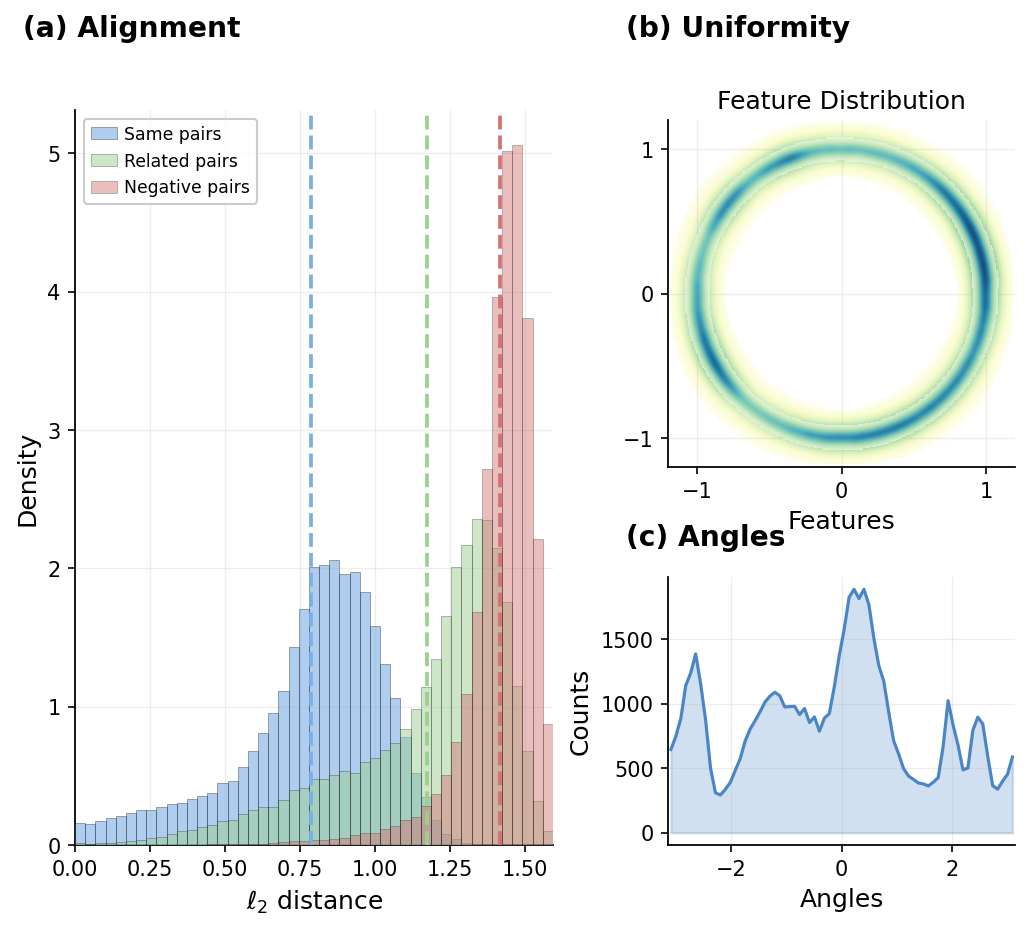


Saved Basin2Vec detailed summary:
paper_results_basin2vec_alignment_uniformity/tables/basin2vec_alignment_detailed_summary.csv

Saved Basin2Vec grouped summary:
paper_results_basin2vec_alignment_uniformity/tables/basin2vec_alignment_grouped_summary.csv

Done.
Figure outputs:
paper_results_basin2vec_alignment_uniformity/figures/fig_basin2vec_alignment_uniformity.pdf
paper_results_basin2vec_alignment_uniformity/figures/fig_basin2vec_alignment_uniformity.png
paper_results_basin2vec_alignment_uniformity/figures/fig_basin2vec_alignment_uniformity_overall.pdf
paper_results_basin2vec_alignment_uniformity/figures/fig_basin2vec_alignment_uniformity_overall.png


In [71]:
#!/usr/bin/env python3
# ==========================================================
# Basin2Vec-only alignment + uniformity plot
#
# Square aligned paper figure:
#   (a) Alignment histogram
#   (b) Overall feature/uniformity distribution
#   (c) Overall angular distribution
#
# Cluster panels are removed.
#
# Key layout controls:
#   fig = plt.figure(figsize=(7, 7)) keeps the canvas square.
#   fig.add_axes([left, bottom, width, height]) gives exact panel placement.
#   savefig does not use bbox_inches="tight", so output remains square.
# ==========================================================

from __future__ import annotations

from pathlib import Path
from collections import defaultdict
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")


# ==========================================================
# CONFIG
# ==========================================================

SEED = 42
RNG = np.random.default_rng(SEED)

BASIN2VEC_NPZ = Path(
    "../src/evaluation_outputs/HCLV4_grouped_monthly_static_meta_areaaux_64d/"
    "basin_embeddings_full.npz"
)

BASIN_METADATA = Path(
    "/data/basin2vec/cache/metadata/basin_metadata.parquet"
)

OVERLAP_PAIRS_PARQUET = Path(
    "/data/basin2vec/cache/basin_overlap_pairs.parquet"
)

MODEL_NAME = "Basin2Vec"
PREFERRED_EMBEDDING_KEY = "embeddings"
PREFER_3D_POINTS = False

OVERLAP_THRESHOLD = 0.50

RESULTS_DIR = Path("paper_results_basin2vec_alignment_uniformity")
FIG_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

MAX_SAME_BASIN_PAIRS = 50_000
MAX_OVERLAP_PAIRS = 50_000
MAX_META_SIMILAR_PAIRS = 50_000
MAX_META_DISSIMILAR_PAIRS = 50_000
MAX_RANDOM_NEG_PAIRS = 50_000

META_SIMILAR_NEIGHBORS = 40
META_DISSIMILAR_CANDIDATES = 500_000

N_VIS = 60_000

DEFAULT_METADATA_COLUMNS = [
    "log_area_km2_z",
    "log_bbox_width_km_z",
    "log_bbox_height_km_z",
    "log_patch_pixel_width_km_z",
    "log_patch_pixel_height_km_z",
    "log_patch_pixel_area_km2_z",
    "bbox_fill_fraction_z",
    "compactness_z",
    "solidity_z",
    "log_shape_index_z",
    "log_overlap_degree_z",
]

THEME = {
    "same_blue": "#7cafe6",
    "related_green": "#9ccf90",
    "negative_red": "#d47272",
    "line_blue": "#4a86c5",
    "grid_alpha": 0.22,
    "grid_lw": 0.60,
    "spine_lw": 0.85,
}

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": THEME["grid_alpha"],
    "grid.linewidth": THEME["grid_lw"],
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 8.3,
})


# ==========================================================
# BASIC HELPERS
# ==========================================================

def normalize_site_id(x) -> str | None:
    if pd.isna(x):
        return None

    s = str(x).strip()

    if s.endswith(".0"):
        s = s[:-2]

    digits = re.sub(r"\D", "", s)

    if len(digits) > 0:
        if len(digits) <= 8:
            return digits.zfill(8)
        return digits

    if len(s) == 0:
        return None

    return s


def l2_normalize(x, eps=1e-12):
    x = np.asarray(x, dtype=np.float32)
    return x / np.clip(np.linalg.norm(x, axis=1, keepdims=True), eps, None)


def pair_distances(x, pairs):
    pairs = np.asarray(pairs, dtype=np.int64)

    if pairs.size == 0:
        return np.empty(0, dtype=np.float32)

    pairs = pairs.reshape(-1, 2)
    i = pairs[:, 0]
    j = pairs[:, 1]

    return np.linalg.norm(x[i] - x[j], axis=1).astype(np.float32)


def savefig(path):
    """
    Important: no bbox_inches='tight'.
    bbox_inches='tight' crops the canvas and can destroy the square output.
    """
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, dpi=300, facecolor="white")
    print(f"Saved: {path}")


def slugify(s):
    return re.sub(r"[^a-z0-9]+", "_", s.lower()).strip("_")


def is_numeric_array(arr):
    return np.issubdtype(np.asarray(arr).dtype, np.number)


def infer_year_from_filename(npz_path: Path) -> int | None:
    matches = re.findall(r"(?<!\d)(19\d{2}|20\d{2})(?!\d)", npz_path.name)

    if len(matches) == 0:
        return None

    return int(matches[-1])


def infer_site_id_column(df):
    candidates = [
        "site_id",
        "siteid",
        "gage_id",
        "gageid",
        "gauge_id",
        "gaugeid",
        "station_id",
        "staid",
        "site_no",
        "usgs_id",
        "basin_id",
        "GAGE_ID",
        "STAID",
    ]

    lower = {str(c).lower(): c for c in df.columns}

    for c in candidates:
        if c.lower() in lower:
            return lower[c.lower()]

    return None


def infer_site_id_int_column(df):
    candidates = [
        "site_id_int",
        "site_int",
        "gage_id_int",
        "basin_id_int",
        "basin_index",
        "basin_idx",
        "index",
    ]

    lower = {str(c).lower(): c for c in df.columns}

    for c in candidates:
        if c.lower() in lower:
            return lower[c.lower()]

    return None


# ==========================================================
# NPZ LOADER
# ==========================================================

def print_npz_keys(npz_path, model_name):
    data = np.load(npz_path, allow_pickle=True)

    print("\n" + "=" * 80)
    print(f"{model_name} NPZ keys: {npz_path}")
    print("=" * 80)

    for k in data.files:
        arr = data[k]
        print(f"{k:35s} shape={arr.shape}, dtype={arr.dtype}")

    return data


def choose_embedding_array(
    data,
    preferred_key: str | None,
    model_name: str,
    prefer_3d_points: bool = False,
):
    if preferred_key is not None and preferred_key in data.files:
        arr = np.asarray(data[preferred_key])
        return preferred_key, arr.astype(np.float32)

    candidates = [
        "point_embeddings",
        "pointwise_embeddings",
        "embeddings_8point",
        "embeddings_8points",
        "basin_point_embeddings",
        "embeddings",
        "embedding",
        "raw_embeddings",
        "basin_embeddings",
        "avg_embeddings",
        "hydrologic_repr",
        "z",
        "features",
    ]

    if prefer_3d_points:
        for key in candidates:
            if key in data.files:
                arr = np.asarray(data[key])
                if is_numeric_array(arr) and arr.ndim == 3:
                    return key, arr.astype(np.float32)

        numeric_3d = []

        for key in data.files:
            arr = np.asarray(data[key])
            if is_numeric_array(arr) and arr.ndim == 3:
                numeric_3d.append((arr.size, key, arr))

        if len(numeric_3d) > 0:
            _, key, arr = max(numeric_3d, key=lambda x: x[0])
            print(f"Warning: using auto-detected 3D embedding key for {model_name}: {key}")
            return key, arr.astype(np.float32)

    for key in candidates:
        if key in data.files:
            arr = np.asarray(data[key])
            if is_numeric_array(arr) and arr.ndim in (2, 3):
                return key, arr.astype(np.float32)

    numeric = []

    for key in data.files:
        arr = np.asarray(data[key])
        if is_numeric_array(arr) and arr.ndim in (2, 3):
            numeric.append((arr.size, key, arr))

    if len(numeric) > 0:
        _, key, arr = max(numeric, key=lambda x: x[0])
        print(f"Warning: using auto-detected embedding key for {model_name}: {key}")
        return key, arr.astype(np.float32)

    raise KeyError(
        f"Could not find embedding array for {model_name}. "
        f"Available keys: {data.files}"
    )


def choose_site_ids(data, model_name, n_expected):
    candidates = [
        "labels",
        "avg_labels",
        "site_ids",
        "site_id",
        "gage_ids",
        "gauge_ids",
        "basin_ids",
        "basin_id",
        "ids",
        "id",
    ]

    for key in candidates:
        if key in data.files:
            arr = np.asarray(data[key])
            if arr.ndim == 1 and len(arr) == n_expected:
                return key, arr

    skip_patterns = [
        "year",
        "embedding",
        "feature",
        "coord",
        "lat",
        "lon",
        "x",
        "y",
        "point",
        "dim",
    ]

    for key in data.files:
        key_lower = key.lower()

        if any(p in key_lower for p in skip_patterns):
            continue

        arr = np.asarray(data[key])

        if arr.ndim != 1 or len(arr) != n_expected:
            continue

        if arr.dtype.kind not in {"O", "U", "S", "i", "u"}:
            continue

        if np.issubdtype(arr.dtype, np.number):
            arr_min = np.nanmin(arr)
            arr_max = np.nanmax(arr)

            if 1900 <= arr_min <= 2100 and 1900 <= arr_max <= 2100:
                continue

        print(f"Warning: using auto-detected site-id key for {model_name}: {key}")
        return key, arr

    raise KeyError(
        f"Could not find site/basin ID array for {model_name} with length {n_expected}. "
        f"Available keys: {data.files}"
    )


def choose_site_ids_int(data, n_expected):
    candidates = [
        "site_ids_int",
        "site_id_int",
        "label_ints",
        "basin_ids_int",
        "basin_id_int",
    ]

    for key in candidates:
        if key in data.files:
            arr = np.asarray(data[key])
            if arr.ndim == 1 and len(arr) == n_expected:
                return key, arr.astype(int)

    return None, None


def choose_years(data, model_name, n_expected, npz_path):
    candidates = [
        "years",
        "year",
        "sample_years",
        "embedding_years",
    ]

    for key in candidates:
        if key in data.files:
            arr = np.asarray(data[key])
            if arr.ndim == 1 and len(arr) == n_expected:
                return key, arr.astype(int)

    inferred_year = infer_year_from_filename(npz_path)

    if inferred_year is not None:
        years = np.full(n_expected, inferred_year, dtype=int)
        print(
            f"{model_name}: no year array found; inferred year={inferred_year} "
            f"from filename {npz_path.name}."
        )
        return "inferred_from_filename", years

    raise KeyError(
        f"Could not find years array for {model_name}, and no year could be "
        f"inferred from filename: {npz_path.name}. Available keys: {data.files}"
    )


def flatten_or_keep_embeddings(emb_raw, df_base, model_name, emb_key):
    emb_raw = np.asarray(emb_raw, dtype=np.float32)

    if emb_raw.ndim == 2:
        df = df_base.copy()
        df["point_id"] = 0

        if df["year"].nunique() > 1:
            same_mode = "years"
            same_label = "Same pairs"
        else:
            same_mode = "single_sample"
            same_label = "Same-basin"

        return df, emb_raw, same_mode, same_label

    if emb_raw.ndim == 3:
        n_basins, n_points, dim = emb_raw.shape

        if len(df_base) != n_basins:
            raise ValueError(
                f"{model_name}: 3D embedding first dimension does not match metadata. "
                f"emb.shape[0]={n_basins}, len(df_base)={len(df_base)}"
            )

        print(
            f"{model_name}: embedding key '{emb_key}' is 3D {emb_raw.shape}; "
            "flattening sampled points instead of averaging."
        )

        emb = emb_raw.reshape(n_basins * n_points, dim).astype(np.float32)

        df = df_base.loc[df_base.index.repeat(n_points)].copy().reset_index(drop=True)
        df["point_id"] = np.tile(np.arange(n_points), n_basins)

        same_mode = "points"
        same_label = f"Same-basin across {n_points} sampled points"

        return df, emb, same_mode, same_label

    raise ValueError(
        f"{model_name}: embedding array must be 2D or 3D. "
        f"Got shape={emb_raw.shape}."
    )


def load_embedding_npz(
    npz_path,
    model_name,
    preferred_embedding_key=None,
    prefer_3d_points=False,
):
    npz_path = Path(npz_path)

    if not npz_path.exists():
        raise FileNotFoundError(f"{model_name} NPZ not found: {npz_path}")

    data = print_npz_keys(npz_path, model_name)

    emb_key, emb_raw = choose_embedding_array(
        data=data,
        preferred_key=preferred_embedding_key,
        model_name=model_name,
        prefer_3d_points=prefer_3d_points,
    )

    n_base = emb_raw.shape[0]

    site_key, site_ids_raw = choose_site_ids(
        data=data,
        model_name=model_name,
        n_expected=n_base,
    )

    site_int_key, site_ids_int = choose_site_ids_int(
        data=data,
        n_expected=n_base,
    )

    year_key, years = choose_years(
        data=data,
        model_name=model_name,
        n_expected=n_base,
        npz_path=npz_path,
    )

    site_ids = np.array([normalize_site_id(x) for x in site_ids_raw], dtype=object)

    df_base = pd.DataFrame({
        "site_id": site_ids,
        "year": years.astype(int),
    })

    if site_ids_int is not None:
        df_base["site_id_int"] = site_ids_int.astype(int)

    valid = df_base["site_id"].notna().to_numpy()
    df_base = df_base.loc[valid].reset_index(drop=True)
    emb_raw = emb_raw[valid]

    df, emb, same_mode, same_label = flatten_or_keep_embeddings(
        emb_raw=emb_raw,
        df_base=df_base,
        model_name=model_name,
        emb_key=emb_key,
    )

    emb = l2_normalize(emb)

    metadata = {
        "model_name": model_name,
        "npz_path": str(npz_path),
        "embedding_key": emb_key,
        "site_key": site_key,
        "site_int_key": site_int_key,
        "year_key": year_key,
        "raw_embedding_shape": tuple(emb_raw.shape),
        "n_samples": int(len(df)),
        "n_unique_basins_before_metadata": int(df["site_id"].nunique()),
        "n_years": int(df["year"].nunique()),
        "min_year": int(df["year"].min()),
        "max_year": int(df["year"].max()),
        "embedding_dim": int(emb.shape[1]),
        "same_mode": same_mode,
        "same_label": same_label,
    }

    print("\nLoaded:", model_name)
    for k, v in metadata.items():
        print(f"  {k}: {v}")

    return df, emb, metadata


# ==========================================================
# METADATA + OVERLAP
# ==========================================================

def load_basin_metadata(metadata_path):
    metadata_path = Path(metadata_path)

    if not metadata_path.exists():
        raise FileNotFoundError(f"Could not find metadata parquet: {metadata_path}")

    meta = pd.read_parquet(metadata_path).copy()

    site_col = infer_site_id_column(meta)
    int_col = infer_site_id_int_column(meta)

    if site_col is not None:
        meta["site_id"] = meta[site_col].apply(normalize_site_id)
    else:
        raise RuntimeError("Could not infer site ID column from metadata parquet.")

    if int_col is not None:
        meta["site_id_int"] = pd.to_numeric(meta[int_col], errors="coerce").astype("Int64")
    else:
        raise RuntimeError("Could not infer integer basin ID column from metadata parquet.")

    feature_cols = [c for c in DEFAULT_METADATA_COLUMNS if c in meta.columns]

    if len(feature_cols) == 0:
        exclude = {
            site_col,
            int_col,
            "site_id",
            "site_id_int",
            "year",
            "lat",
            "lon",
            "latitude",
            "longitude",
        }

        numeric_cols = []

        for c in meta.columns:
            if c in exclude:
                continue

            x = pd.to_numeric(meta[c], errors="coerce")

            if x.notna().mean() >= 0.70 and x.std(skipna=True) > 1e-12:
                meta[c] = x
                numeric_cols.append(c)

        feature_cols = numeric_cols

    if len(feature_cols) == 0:
        raise RuntimeError("No usable metadata feature columns found.")

    for c in feature_cols:
        meta[c] = pd.to_numeric(meta[c], errors="coerce")
        meta[c] = meta[c].fillna(meta[c].median(skipna=True))

    X = meta[feature_cols].to_numpy(dtype=np.float32)
    X = (X - X.mean(axis=0, keepdims=True)) / np.clip(
        X.std(axis=0, keepdims=True),
        1e-6,
        None,
    )

    meta_features = meta[["site_id", "site_id_int"] + feature_cols].copy()
    meta_features[feature_cols] = X

    meta_features = meta_features.dropna(subset=["site_id", "site_id_int"]).copy()
    meta_features["site_id_int"] = meta_features["site_id_int"].astype(int)

    meta_features = meta_features.drop_duplicates(
        subset=["site_id_int"],
        keep="first",
    )

    print("\nLoaded basin metadata")
    print("Metadata path:", metadata_path)
    print("Site ID column:", site_col)
    print("Integer ID column:", int_col)
    print("Number of metadata basins:", len(meta_features))
    print("Metadata features:", feature_cols)

    return meta_features, feature_cols


def attach_int_ids_from_metadata(sample_df, emb, meta_features, model_name):
    sample_df = sample_df.copy()

    mapper = (
        meta_features[["site_id", "site_id_int"]]
        .dropna()
        .drop_duplicates(subset=["site_id"])
        .set_index("site_id")["site_id_int"]
        .to_dict()
    )

    mapped = sample_df["site_id"].map(mapper)

    if "site_id_int" in sample_df.columns:
        sample_df["site_id_int_original"] = sample_df["site_id_int"]
        sample_df["site_id_int"] = mapped.combine_first(sample_df["site_id_int"])
    else:
        sample_df["site_id_int"] = mapped

    missing = int(sample_df["site_id_int"].isna().sum())

    if missing > 0:
        print(
            f"Warning: {model_name}: {missing} rows could not be mapped to metadata site_id_int. "
            "Dropping those rows."
        )

    valid = sample_df["site_id_int"].notna().to_numpy()
    sample_df = sample_df.loc[valid].reset_index(drop=True)
    emb = emb[valid]

    sample_df["site_id_int"] = sample_df["site_id_int"].astype(int)

    print(
        f"{model_name}: after metadata mapping: "
        f"samples={len(sample_df)}, basins={sample_df['site_id_int'].nunique()}"
    )

    return sample_df, emb


def load_overlap_pairs_for_eval(path, threshold=0.5):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Could not find overlap pair parquet: {path}")

    df = pd.read_parquet(path).copy()

    required = {"site_id_int_a", "site_id_int_b"}
    missing = required - set(df.columns)

    if missing:
        raise ValueError(f"{path} missing required columns: {sorted(missing)}")

    score_candidates = [
        "overlap_score",
        "score",
        "overlap",
        "iou",
        "overlap_frac",
        "overlap_fraction",
    ]

    score_col = None

    for c in score_candidates:
        if c in df.columns:
            score_col = c
            break

    if score_col is not None:
        df = df[df[score_col] > threshold].copy()
        print(f"\nUsing overlap score column: {score_col}")
        print(f"Overlap threshold: > {threshold}")
    else:
        print("\nNo overlap score column found. Using all overlap pairs.")

    df["site_id_int_a"] = df["site_id_int_a"].astype(int)
    df["site_id_int_b"] = df["site_id_int_b"].astype(int)

    df = df[df["site_id_int_a"] != df["site_id_int_b"]].copy()

    print("Overlap/nested basin pairs:", len(df))

    return df, score_col


def build_overlap_set(overlap_df):
    overlap_set = set()

    for _, row in overlap_df.iterrows():
        a = int(row["site_id_int_a"])
        b = int(row["site_id_int_b"])

        if a == b:
            continue

        overlap_set.add((a, b))
        overlap_set.add((b, a))

    return overlap_set


# ==========================================================
# BASIN-LEVEL AVERAGE EMBEDDINGS
# ==========================================================

def compute_basin_average_embeddings(sample_df, emb, model_name):
    df = sample_df.copy()
    df["row"] = np.arange(len(df))

    rows = []
    avg_embs = []

    for sid_int, sub in df.groupby("site_id_int", sort=True):
        idx = sub["row"].to_numpy(dtype=int)

        z = emb[idx].mean(axis=0, keepdims=True)
        z = l2_normalize(z)[0]

        if sub["site_id"].notna().any():
            site_id = sub["site_id"].dropna().astype(str).iloc[0]
        else:
            site_id = str(sid_int)

        rows.append({
            "site_id_int": int(sid_int),
            "site_id": site_id,
            "n_samples": int(len(sub)),
            "n_years": int(sub["year"].nunique()),
            "min_year": int(sub["year"].min()),
            "max_year": int(sub["year"].max()),
        })

        avg_embs.append(z)

    avg_df = pd.DataFrame(rows)
    avg_emb = np.stack(avg_embs, axis=0).astype(np.float32)

    print(f"\n{model_name}: computed basin-level averaged embeddings")
    print("Basin-level embeddings:", avg_emb.shape)
    print("Basins:", len(avg_df))
    print("Samples per basin summary:")
    print(avg_df["n_samples"].describe())

    return avg_df, avg_emb


def prepare_avg_metadata(avg_df, avg_emb, meta_features, feature_cols, model_name):
    avg_df2 = avg_df.copy()
    avg_df2["avg_index"] = np.arange(len(avg_df2))

    merged = avg_df2.merge(
        meta_features[["site_id_int"] + feature_cols],
        on="site_id_int",
        how="inner",
    )

    if len(merged) == 0:
        raise RuntimeError(f"{model_name}: no basin-level embeddings matched to metadata.")

    emb2 = avg_emb[merged["avg_index"].to_numpy(dtype=int)]

    X_meta = merged[feature_cols].to_numpy(dtype=np.float32)
    X_meta = (X_meta - X_meta.mean(axis=0, keepdims=True)) / np.clip(
        X_meta.std(axis=0, keepdims=True),
        1e-6,
        None,
    )

    merged = merged.reset_index(drop=True)

    print(f"\n{model_name}: prepared metadata-matched basin-level embeddings")
    print("Matched basins:", len(merged))
    print("Metadata feature dim:", X_meta.shape[1])

    return merged, emb2, X_meta


# ==========================================================
# PAIR SAMPLING
# ==========================================================

def sample_same_basin_pairs(sample_df, same_mode, max_pairs=50_000):
    if same_mode == "single_sample":
        return np.empty((0, 2), dtype=np.int64)

    df = sample_df.reset_index(drop=True)
    basin_to_rows = defaultdict(list)

    for i, row in df.iterrows():
        basin_to_rows[int(row["site_id_int"])].append(
            (
                int(i),
                int(row["year"]),
                int(row.get("point_id", 0)),
            )
        )

    valid_groups = []

    for _, items in basin_to_rows.items():
        if same_mode == "years":
            vals = {yr for _, yr, _ in items}
        elif same_mode == "points":
            vals = {pt for _, _, pt in items}
        else:
            vals = set()

        if len(items) >= 2 and len(vals) >= 2:
            valid_groups.append(items)

    if len(valid_groups) == 0:
        return np.empty((0, 2), dtype=np.int64)

    pairs = []
    attempts = 0
    max_attempts = max_pairs * 80

    while len(pairs) < max_pairs and attempts < max_attempts:
        items = valid_groups[RNG.integers(0, len(valid_groups))]
        a, b = RNG.choice(len(items), size=2, replace=False)

        ia, ya, pa = items[a]
        ib, yb, pb = items[b]

        if same_mode == "years" and ya == yb:
            attempts += 1
            continue

        if same_mode == "points" and pa == pb:
            attempts += 1
            continue

        pairs.append((ia, ib))
        attempts += 1

    return np.asarray(pairs, dtype=np.int64).reshape(-1, 2)


def sample_overlap_positive_pairs(avg_df, overlap_df, max_pairs=50_000):
    label_to_idx = {
        int(row.site_id_int): int(i)
        for i, row in avg_df.reset_index(drop=True).iterrows()
    }

    pairs = []

    for _, row in overlap_df.iterrows():
        a = int(row["site_id_int_a"])
        b = int(row["site_id_int_b"])

        if a in label_to_idx and b in label_to_idx:
            pairs.append((label_to_idx[a], label_to_idx[b]))

    if len(pairs) > max_pairs:
        keep = RNG.choice(len(pairs), size=max_pairs, replace=False)
        pairs = [pairs[i] for i in keep]

    return np.asarray(pairs, dtype=np.int64).reshape(-1, 2)


def sample_random_nonoverlap_pairs(avg_df, overlap_set, max_pairs=50_000):
    labels = avg_df["site_id_int"].to_numpy(dtype=int)
    n = len(labels)

    pairs = []
    attempts = 0
    max_attempts = max_pairs * 80

    while len(pairs) < max_pairs and attempts < max_attempts:
        i = int(RNG.integers(0, n))
        j = int(RNG.integers(0, n))

        attempts += 1

        if i == j:
            continue

        a = int(labels[i])
        b = int(labels[j])

        if a == b:
            continue

        if (a, b) in overlap_set:
            continue

        pairs.append((i, j))

    return np.asarray(pairs, dtype=np.int64).reshape(-1, 2)


def sample_metadata_similar_nonoverlap_pairs(
    avg_meta_df,
    X_meta,
    overlap_set,
    max_pairs=50_000,
    n_neighbors=40,
):
    labels = avg_meta_df["site_id_int"].to_numpy(dtype=int)
    n = len(labels)

    if n < 2:
        return np.empty((0, 2), dtype=np.int64)

    nn = NearestNeighbors(
        n_neighbors=min(n_neighbors + 1, n),
        metric="euclidean",
        algorithm="auto",
    )

    nn.fit(X_meta)
    _, indices = nn.kneighbors(X_meta)

    pairs = []

    for i in range(n):
        a = int(labels[i])

        for jj in indices[i, 1:]:
            j = int(jj)
            b = int(labels[j])

            if a == b:
                continue

            if (a, b) in overlap_set:
                continue

            pairs.append((i, j))

            if len(pairs) >= max_pairs:
                break

        if len(pairs) >= max_pairs:
            break

    return np.asarray(pairs, dtype=np.int64).reshape(-1, 2)


def sample_metadata_dissimilar_nonoverlap_pairs(
    avg_meta_df,
    X_meta,
    overlap_set,
    max_pairs=50_000,
    n_candidates=500_000,
):
    labels = avg_meta_df["site_id_int"].to_numpy(dtype=int)
    n = len(labels)

    if n < 2:
        return np.empty((0, 2), dtype=np.int64)

    cand_i = []
    cand_j = []
    cand_d = []

    total_collected = 0
    attempts = 0
    max_attempts = n_candidates * 20

    while total_collected < n_candidates and attempts < max_attempts:
        batch = min(50_000, n_candidates - total_collected)

        i = RNG.integers(0, n, size=batch)
        j = RNG.integers(0, n, size=batch)

        attempts += batch

        valid = i != j
        i = i[valid]
        j = j[valid]

        if len(i) == 0:
            continue

        a = labels[i]
        b = labels[j]

        keep = np.ones(len(i), dtype=bool)

        for idx, (aa, bb) in enumerate(zip(a, b)):
            if aa == bb:
                keep[idx] = False
            elif (int(aa), int(bb)) in overlap_set:
                keep[idx] = False

        if keep.sum() == 0:
            continue

        i2 = i[keep]
        j2 = j[keep]

        d = np.linalg.norm(X_meta[i2] - X_meta[j2], axis=1)

        cand_i.append(i2)
        cand_j.append(j2)
        cand_d.append(d)

        total_collected += len(i2)

    if len(cand_i) == 0:
        return np.empty((0, 2), dtype=np.int64)

    cand_i = np.concatenate(cand_i)
    cand_j = np.concatenate(cand_j)
    cand_d = np.concatenate(cand_d)

    order = np.argsort(-cand_d)
    order = order[:min(max_pairs, len(order))]

    pairs = np.stack([cand_i[order], cand_j[order]], axis=1).astype(np.int64)

    return pairs.reshape(-1, 2)


# ==========================================================
# UNIFORMITY HELPERS
# ==========================================================

def project_to_unit_circle_shared(x):
    x = np.asarray(x, dtype=np.float32)

    if len(x) < 2:
        raise RuntimeError("Need at least two samples for PCA projection.")

    pca = PCA(n_components=2, random_state=SEED)
    xy = pca.fit_transform(x)

    xy_unit = xy / np.clip(
        np.linalg.norm(xy, axis=1, keepdims=True),
        1e-12,
        None,
    )

    return xy_unit.astype(np.float32)


def angles_from_xy(xy_unit):
    return np.arctan2(xy_unit[:, 1], xy_unit[:, 0])


def plot_ring_density_soft(
    ax,
    xy_unit,
    title="",
    bins=300,
    sigma_mid=5.5,
    sigma_inner=2.7,
    alpha_mid=0.66,
    alpha_inner=0.74,
    low_threshold=0.010,
    core_threshold=0.055,
    gamma=0.34,
    show_points=False,
    draw_unit_circle=True,
):
    xy_unit = np.asarray(xy_unit, dtype=np.float32)
    x = xy_unit[:, 0]
    y = xy_unit[:, 1]

    H, _, _ = np.histogram2d(
        x,
        y,
        bins=bins,
        range=[[-1.25, 1.25], [-1.25, 1.25]],
    )

    extent = [-1.25, 1.25, -1.25, 1.25]

    H_mid = gaussian_filter(H, sigma=sigma_mid)
    H_inner = gaussian_filter(H, sigma=sigma_inner)

    def normalize_and_stretch(A, gamma_value):
        A = np.asarray(A, dtype=np.float64)
        if A.max() > 0:
            A = A / A.max()
        A = np.power(A, gamma_value)
        return A

    H_mid = normalize_and_stretch(H_mid, gamma)
    H_inner = normalize_and_stretch(H_inner, gamma)

    mid = np.ma.masked_where(H_mid < low_threshold, H_mid)
    inner = np.ma.masked_where(H_inner < core_threshold, H_inner)

    ax.imshow(
        mid.T,
        origin="lower",
        extent=extent,
        cmap="YlGn",
        alpha=alpha_mid,
        interpolation="bilinear",
        aspect="equal",
        vmin=0,
        vmax=1,
        zorder=1,
    )

    ax.imshow(
        inner.T,
        origin="lower",
        extent=extent,
        cmap="GnBu",
        alpha=alpha_inner,
        interpolation="bilinear",
        aspect="equal",
        vmin=0,
        vmax=1,
        zorder=2,
    )

    if draw_unit_circle:
        circle = plt.Circle(
            (0, 0),
            1.0,
            fill=False,
            color="0.75",
            linewidth=0.70,
            alpha=0.55,
            zorder=0,
        )
        ax.add_patch(circle)

    if show_points:
        ax.scatter(
            x,
            y,
            s=4,
            alpha=0.020,
            color="black",
            edgecolors="none",
            rasterized=True,
            zorder=3,
        )

    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_aspect("equal", adjustable="box")
    ax.set_anchor("C")

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Features")
    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-1, 0, 1])

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)


def plot_angle_hist(ax, angles, color="#4a86c5", bins=70):
    hist, edges = np.histogram(
        angles,
        bins=bins,
        range=(-np.pi, np.pi),
        density=False,
    )

    centers = 0.5 * (edges[:-1] + edges[1:])

    ax.fill_between(centers, hist, alpha=0.25, color=color)
    ax.plot(centers, hist, linewidth=1.5, color=color)

    ax.set_xlim(-np.pi, np.pi)
    ax.set_xlabel("Angles")
    ax.set_ylabel("Counts")


# ==========================================================
# MODEL ANALYSIS
# ==========================================================

def summarize_relation(model_name, relation_name, grouped_relation, distances):
    d = np.asarray(distances, dtype=np.float64)

    if len(d) == 0:
        return {
            "model": model_name,
            "relation": relation_name,
            "grouped_relation": grouped_relation,
            "n_pairs": 0,
            "mean_l2_distance": np.nan,
            "median_l2_distance": np.nan,
            "std_l2_distance": np.nan,
            "p05_l2_distance": np.nan,
            "p95_l2_distance": np.nan,
        }

    return {
        "model": model_name,
        "relation": relation_name,
        "grouped_relation": grouped_relation,
        "n_pairs": int(len(d)),
        "mean_l2_distance": float(np.mean(d)),
        "median_l2_distance": float(np.median(d)),
        "std_l2_distance": float(np.std(d)),
        "p05_l2_distance": float(np.percentile(d, 5)),
        "p95_l2_distance": float(np.percentile(d, 95)),
    }


def analyze_one_model(
    model_name,
    sample_df,
    emb,
    meta,
    meta_features,
    feature_cols,
    overlap_df,
    overlap_set,
):
    same_mode = meta["same_mode"]
    same_label = meta["same_label"]

    avg_df, avg_emb = compute_basin_average_embeddings(
        sample_df=sample_df,
        emb=emb,
        model_name=model_name,
    )

    avg_meta_df, avg_meta_emb, X_meta = prepare_avg_metadata(
        avg_df=avg_df,
        avg_emb=avg_emb,
        meta_features=meta_features,
        feature_cols=feature_cols,
        model_name=model_name,
    )

    same_pairs = sample_same_basin_pairs(
        sample_df=sample_df,
        same_mode=same_mode,
        max_pairs=MAX_SAME_BASIN_PAIRS,
    )
    same_dist = pair_distances(emb, same_pairs)

    overlap_pairs = sample_overlap_positive_pairs(
        avg_df=avg_df,
        overlap_df=overlap_df,
        max_pairs=MAX_OVERLAP_PAIRS,
    )
    overlap_dist = pair_distances(avg_emb, overlap_pairs)

    meta_sim_pairs = sample_metadata_similar_nonoverlap_pairs(
        avg_meta_df=avg_meta_df,
        X_meta=X_meta,
        overlap_set=overlap_set,
        max_pairs=MAX_META_SIMILAR_PAIRS,
        n_neighbors=META_SIMILAR_NEIGHBORS,
    )
    meta_sim_dist = pair_distances(avg_meta_emb, meta_sim_pairs)

    meta_dis_pairs = sample_metadata_dissimilar_nonoverlap_pairs(
        avg_meta_df=avg_meta_df,
        X_meta=X_meta,
        overlap_set=overlap_set,
        max_pairs=MAX_META_DISSIMILAR_PAIRS,
        n_candidates=META_DISSIMILAR_CANDIDATES,
    )
    meta_dis_dist = pair_distances(avg_meta_emb, meta_dis_pairs)

    random_neg_pairs = sample_random_nonoverlap_pairs(
        avg_df=avg_df,
        overlap_set=overlap_set,
        max_pairs=MAX_RANDOM_NEG_PAIRS,
    )
    random_neg_dist = pair_distances(avg_emb, random_neg_pairs)

    related_or_weak_parts = [
        d for d in [overlap_dist, meta_sim_dist]
        if len(d) > 0
    ]

    strong_negative_parts = [
        d for d in [meta_dis_dist, random_neg_dist]
        if len(d) > 0
    ]

    related_or_weak_dist = (
        np.concatenate(related_or_weak_parts).astype(np.float32)
        if len(related_or_weak_parts) > 0
        else np.empty(0, dtype=np.float32)
    )

    strong_negative_dist = (
        np.concatenate(strong_negative_parts).astype(np.float32)
        if len(strong_negative_parts) > 0
        else np.empty(0, dtype=np.float32)
    )

    relation_distances = []

    if len(same_dist) > 0:
        relation_distances.append({
            "name": same_label,
            "short": "Same basin",
            "dist": same_dist,
            "color": THEME["same_blue"],
            "alpha": 0.62,
        })

    relation_distances.extend([
        {
            "name": "Related pairs",
            "short": "Related / weak",
            "dist": related_or_weak_dist,
            "color": THEME["related_green"],
            "alpha": 0.50,
        },
        {
            "name": "Negative pairs",
            "short": "Strong negative",
            "dist": strong_negative_dist,
            "color": THEME["negative_red"],
            "alpha": 0.46,
        },
    ])

    detailed_rows = [
        summarize_relation(
            model_name,
            same_label,
            "Same-basin relation",
            same_dist,
        ),
        summarize_relation(
            model_name,
            f"Overlap/nested+: overlap > {OVERLAP_THRESHOLD}",
            "Hydrologically related / weak relation",
            overlap_dist,
        ),
        summarize_relation(
            model_name,
            "Metadata-similar non-overlap",
            "Hydrologically related / weak relation",
            meta_sim_dist,
        ),
        summarize_relation(
            model_name,
            "Metadata-dissimilar non-overlap",
            "Strong negative relation",
            meta_dis_dist,
        ),
        summarize_relation(
            model_name,
            "Random non-overlap negative",
            "Strong negative relation",
            random_neg_dist,
        ),
    ]

    grouped_rows = []

    for r in relation_distances:
        grouped_rows.append(
            summarize_relation(
                model_name=model_name,
                relation_name=r["name"],
                grouped_relation=r["name"],
                distances=r["dist"],
            )
        )

    return {
        "model_name": model_name,
        "sample_df": sample_df,
        "emb": emb,
        "avg_df": avg_df,
        "avg_emb": avg_emb,
        "same_label": same_label,
        "same_mode": same_mode,
        "relation_distances": relation_distances,
        "detailed_rows": detailed_rows,
        "grouped_rows": grouped_rows,
    }


# ==========================================================
# PLOT
# ==========================================================

def plot_one_model(result):
    model_name = result["model_name"]
    emb = result["emb"]
    relation_distances = result["relation_distances"]

    valid_relation_distances = [
        r for r in relation_distances
        if len(r["dist"]) > 0
    ]

    if len(valid_relation_distances) == 0:
        print(f"Skipping plot for {model_name}: no valid relation distances.")
        return

    n_vis = min(N_VIS, len(emb))

    if n_vis < 10:
        print(f"Skipping uniformity plot for {model_name}: too few samples.")
        return

    sample_proj_idx = RNG.choice(len(emb), size=n_vis, replace=False)
    emb_vis = emb[sample_proj_idx]

    xy_unit_all = project_to_unit_circle_shared(emb_vis)
    angles_all = angles_from_xy(xy_unit_all)

    # ------------------------------------------------------
    # Square canvas
    # ------------------------------------------------------
    fig = plt.figure(figsize=(7, 7), facecolor="white")

    # ------------------------------------------------------
    # Manual aligned axes: [left, bottom, width, height]
    #
    # Left and right blocks share visual top/bottom:
    # alignment bottom = 0.140, top = 0.840
    # uniformity top   = 0.840
    # angle bottom     = 0.140
    # ------------------------------------------------------
    ax_align = fig.add_axes([0.075, 0.140, 0.455, 0.700])
    ax_uniform = fig.add_axes([0.640, 0.500, 0.330, 0.330])
    ax_angle = fig.add_axes([0.640, 0.140, 0.330, 0.255])

    fig.text(0.025, 0.910, "(a) Alignment", fontsize=13.5, fontweight="bold")
    fig.text(0.600, 0.910, "(b) Uniformity", fontsize=13.5, fontweight="bold")
    fig.text(0.600, 0.425, "(c) Angles", fontsize=13.5, fontweight="bold")

    # ------------------------------------------------------
    # (a) Alignment histogram
    # ------------------------------------------------------
    max_x = max(
        np.percentile(r["dist"], 99)
        for r in valid_relation_distances
        if len(r["dist"]) > 0
    )

    bins = np.linspace(0, max_x, 48)

    for r in valid_relation_distances:
        d = np.asarray(r["dist"], dtype=np.float32)

        ax_align.hist(
            d,
            bins=bins,
            density=True,
            alpha=r["alpha"],
            color=r["color"],
            edgecolor="black",
            linewidth=0.25,
            label=r["name"],
            zorder=3,
        )

        ax_align.axvline(
            np.mean(d),
            linestyle="--",
            color=r["color"],
            linewidth=1.8,
            zorder=4,
        )

    ax_align.set_xlabel(r"$\ell_2$ distance")
    ax_align.set_ylabel("Density")
    ax_align.set_xlim(0, max_x)

    ax_align.legend(
        fontsize=8.3,
        frameon=True,
        loc="upper left",
        edgecolor="0.75",
        handlelength=1.5,
        handletextpad=0.45,
    )

    # ------------------------------------------------------
    # (b) Overall uniformity
    # ------------------------------------------------------
    plot_ring_density_soft(
        ax_uniform,
        xy_unit_all,
        title="Feature Distribution",
        bins=300,
        sigma_mid=5.5,
        sigma_inner=2.7,
        alpha_mid=0.66,
        alpha_inner=0.74,
        low_threshold=0.010,
        core_threshold=0.055,
        gamma=0.34,
        show_points=False,
        draw_unit_circle=True,
    )

    # ------------------------------------------------------
    # (c) Overall angles
    # ------------------------------------------------------
    plot_angle_hist(
        ax_angle,
        angles_all,
        color=THEME["line_blue"],
        bins=70,
    )

    # ------------------------------------------------------
    # Styling
    # ------------------------------------------------------
    all_axes = [ax_align, ax_uniform, ax_angle]

    for ax in all_axes:
        ax.grid(True, alpha=THEME["grid_alpha"], linewidth=THEME["grid_lw"])
        ax.tick_params(axis="both", labelsize=10, width=0.8)

        for spine in ax.spines.values():
            spine.set_linewidth(THEME["spine_lw"])

    # ------------------------------------------------------
    # Save
    # ------------------------------------------------------
    out_slug = slugify(model_name)

    out_pdf_overall = FIG_DIR / f"fig_{out_slug}_alignment_uniformity_overall.pdf"
    out_png_overall = FIG_DIR / f"fig_{out_slug}_alignment_uniformity_overall.png"
    out_pdf = FIG_DIR / f"fig_{out_slug}_alignment_uniformity.pdf"
    out_png = FIG_DIR / f"fig_{out_slug}_alignment_uniformity.png"

    savefig(out_pdf_overall)
    savefig(out_png_overall)
    savefig(out_pdf)
    savefig(out_png)

    plt.show()


# ==========================================================
# MAIN
# ==========================================================

def main():
    meta_features, feature_cols = load_basin_metadata(BASIN_METADATA)

    overlap_df, overlap_score_col = load_overlap_pairs_for_eval(
        OVERLAP_PAIRS_PARQUET,
        threshold=OVERLAP_THRESHOLD,
    )

    overlap_set = build_overlap_set(overlap_df)

    print("\n" + "#" * 90)
    print(f"Processing model: {MODEL_NAME}")
    print("#" * 90)

    sample_df, emb, model_meta = load_embedding_npz(
        npz_path=BASIN2VEC_NPZ,
        model_name=MODEL_NAME,
        preferred_embedding_key=PREFERRED_EMBEDDING_KEY,
        prefer_3d_points=PREFER_3D_POINTS,
    )

    sample_df, emb = attach_int_ids_from_metadata(
        sample_df=sample_df,
        emb=emb,
        meta_features=meta_features,
        model_name=MODEL_NAME,
    )

    if len(sample_df) == 0:
        raise RuntimeError("No Basin2Vec samples after metadata mapping.")

    result = analyze_one_model(
        model_name=MODEL_NAME,
        sample_df=sample_df,
        emb=emb,
        meta=model_meta,
        meta_features=meta_features,
        feature_cols=feature_cols,
        overlap_df=overlap_df,
        overlap_set=overlap_set,
    )

    detailed_summary = pd.DataFrame(result["detailed_rows"])
    grouped_summary = pd.DataFrame(result["grouped_rows"])

    print(f"\n{MODEL_NAME}: detailed alignment summary:")
    print(detailed_summary.to_string(index=False))

    print(f"\n{MODEL_NAME}: grouped alignment summary:")
    print(grouped_summary.to_string(index=False))

    plot_one_model(result)

    detailed_path = TABLE_DIR / "basin2vec_alignment_detailed_summary.csv"
    grouped_path = TABLE_DIR / "basin2vec_alignment_grouped_summary.csv"

    detailed_summary.to_csv(detailed_path, index=False)
    grouped_summary.to_csv(grouped_path, index=False)

    print("\nSaved Basin2Vec detailed summary:")
    print(detailed_path)

    print("\nSaved Basin2Vec grouped summary:")
    print(grouped_path)

    print("\nDone.")
    print("Figure outputs:")
    print(FIG_DIR / "fig_basin2vec_alignment_uniformity.pdf")
    print(FIG_DIR / "fig_basin2vec_alignment_uniformity.png")
    print(FIG_DIR / "fig_basin2vec_alignment_uniformity_overall.pdf")
    print(FIG_DIR / "fig_basin2vec_alignment_uniformity_overall.png")


if __name__ == "__main__":
    main()


Loaded basin metadata
Metadata path: /data/basin2vec/cache/metadata/basin_metadata.parquet
Site ID column: site_id
Integer ID column: site_id_int
Number of metadata basins: 9067
Metadata features: ['log_area_km2_z', 'log_bbox_width_km_z', 'log_bbox_height_km_z', 'log_patch_pixel_width_km_z', 'log_patch_pixel_height_km_z', 'log_patch_pixel_area_km2_z', 'bbox_fill_fraction_z', 'compactness_z', 'solidity_z', 'log_shape_index_z', 'log_overlap_degree_z']

Using overlap score column: overlap_score
Overlap threshold: > 0.5
Overlap/nested basin pairs: 34291

##########################################################################################
Processing model: Basin2Vec
##########################################################################################

Basin2Vec NPZ keys: ../src/evaluation_outputs/HCLV4_grouped_monthly_static_meta_areaaux_64d/basin_embeddings_full.npz
embeddings                          shape=(362680, 64), dtype=float32
hydrologic_repr                     shape=(

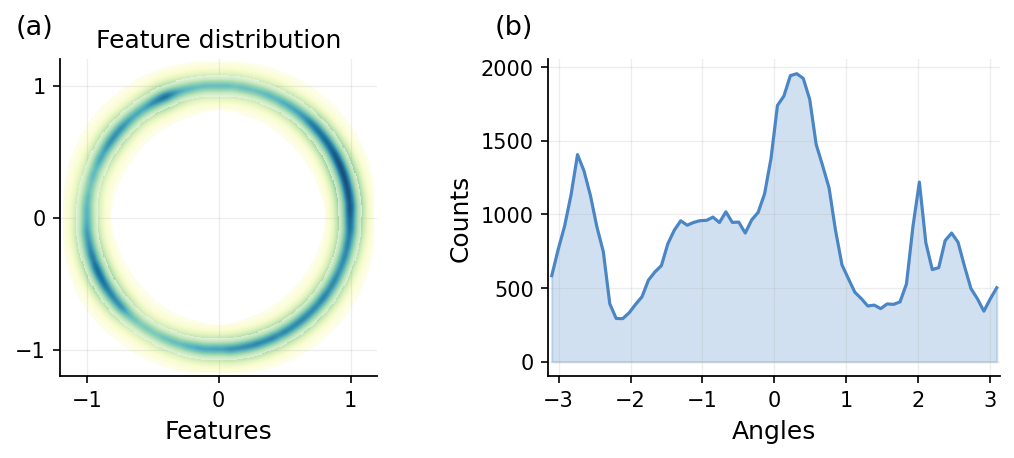

Saved: paper_results_basin2vec_alphaearth_intrinsic/figures/fig_alignment_basin2vec_alphaearth.pdf
Saved: paper_results_basin2vec_alphaearth_intrinsic/figures/fig_alignment_basin2vec_alphaearth.png


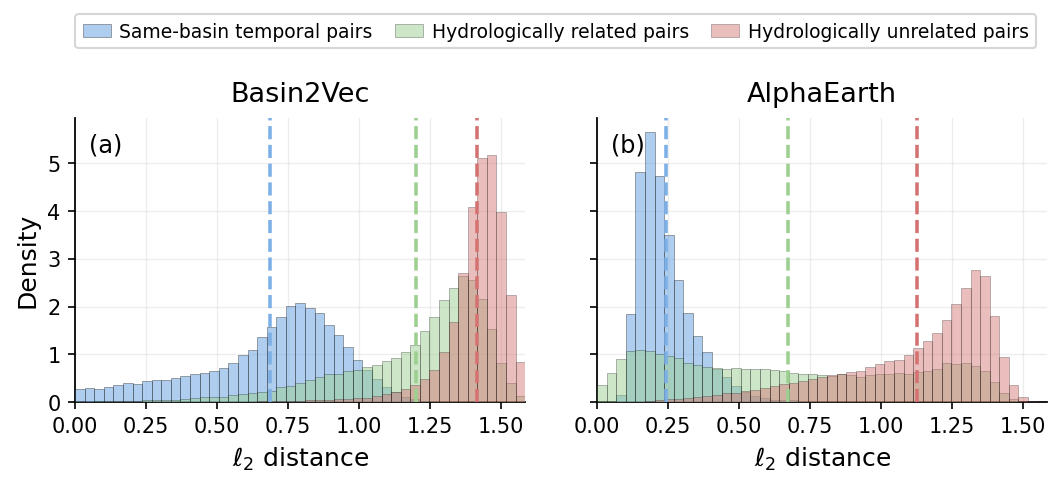


Done.
Figure outputs:
paper_results_basin2vec_alphaearth_intrinsic/figures/fig_basin2vec_uniformity_angles.pdf
paper_results_basin2vec_alphaearth_intrinsic/figures/fig_basin2vec_uniformity_angles.png
paper_results_basin2vec_alphaearth_intrinsic/figures/fig_alignment_basin2vec_alphaearth.pdf
paper_results_basin2vec_alphaearth_intrinsic/figures/fig_alignment_basin2vec_alphaearth.png


In [6]:
#!/usr/bin/env python3
# ==========================================================
# Basin2Vec / AlphaEarth intrinsic diagnostic figures
#
# Outputs:
#   1) Basin2Vec uniformity + angles, horizontally aligned
#      figures/fig_basin2vec_uniformity_angles.pdf/png
#
#   2) Alignment comparison: Basin2Vec vs AlphaEarth
#      figures/fig_alignment_basin2vec_alphaearth.pdf/png
#
# Notes:
#   - Alignment compares same, related, and negative pair distances.
#   - Related pairs = overlap/nested + metadata-similar non-overlap.
#   - Negative pairs = metadata-dissimilar + random non-overlap.
#   - For fair comparison with AlphaEarth, Basin2Vec is filtered to
#     the AlphaEarth temporal window by default: 2017--2024.
#     Set ALIGN_YEAR_MIN = None and ALIGN_YEAR_MAX = None to use all years.
# ==========================================================

from __future__ import annotations

from pathlib import Path
from collections import defaultdict
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")


# ==========================================================
# CONFIG
# ==========================================================

SEED = 42
RNG = np.random.default_rng(SEED)

BASIN2VEC_NPZ = Path(
    "../src/evaluation_outputs/HCLV4_grouped_monthly_static_meta_areaaux_64d/"
    "basin_embeddings_full.npz"
)

ALPHAEARTH_NPZ = Path(
    "alphaearth_embeddings/embeddings/"
    "alphaearth_annual_basin_embeddings_2017_2024_scale500m.npz"
)

BASIN_METADATA = Path(
    "/data/basin2vec/cache/metadata/basin_metadata.parquet"
)

OVERLAP_PAIRS_PARQUET = Path(
    "/data/basin2vec/cache/basin_overlap_pairs.parquet"
)

# Use common AlphaEarth temporal window for alignment comparison.
# Set both to None to use all available Basin2Vec years.
ALIGN_YEAR_MIN = 2017
ALIGN_YEAR_MAX = 2024

OVERLAP_THRESHOLD = 0.50

RESULTS_DIR = Path("paper_results_basin2vec_alphaearth_intrinsic")
FIG_DIR = RESULTS_DIR / "figures"
TABLE_DIR = RESULTS_DIR / "tables"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

MAX_SAME_BASIN_PAIRS = 50_000
MAX_OVERLAP_PAIRS = 50_000
MAX_META_SIMILAR_PAIRS = 50_000
MAX_META_DISSIMILAR_PAIRS = 50_000
MAX_RANDOM_NEG_PAIRS = 50_000

META_SIMILAR_NEIGHBORS = 40
META_DISSIMILAR_CANDIDATES = 500_000

N_VIS = 60_000

DEFAULT_METADATA_COLUMNS = [
    "log_area_km2_z",
    "log_bbox_width_km_z",
    "log_bbox_height_km_z",
    "log_patch_pixel_width_km_z",
    "log_patch_pixel_height_km_z",
    "log_patch_pixel_area_km2_z",
    "bbox_fill_fraction_z",
    "compactness_z",
    "solidity_z",
    "log_shape_index_z",
    "log_overlap_degree_z",
]

THEME = {
    "same_blue": "#7cafe6",
    "related_green": "#9ccf90",
    "negative_red": "#d47272",
    "line_blue": "#4a86c5",
    "grid_alpha": 0.22,
    "grid_lw": 0.60,
    "spine_lw": 0.85,
}
RELATION_LABELS = {
    "Same pairs": "Same-basin temporal pairs",
    "Related pairs": "Hydrologically related pairs",
    "Negative pairs": "Hydrologically unrelated pairs",
}
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": THEME["grid_alpha"],
    "grid.linewidth": THEME["grid_lw"],
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 8.5,
})


# ==========================================================
# BASIC HELPERS
# ==========================================================

def normalize_site_id(x) -> str | None:
    if pd.isna(x):
        return None

    s = str(x).strip()

    if s.endswith(".0"):
        s = s[:-2]

    digits = re.sub(r"\D", "", s)

    if len(digits) > 0:
        if len(digits) <= 8:
            return digits.zfill(8)
        return digits

    if len(s) == 0:
        return None

    return s


def l2_normalize(x, eps=1e-12):
    x = np.asarray(x, dtype=np.float32)
    return x / np.clip(np.linalg.norm(x, axis=1, keepdims=True), eps, None)


def pair_distances(x, pairs):
    pairs = np.asarray(pairs, dtype=np.int64)

    if pairs.size == 0:
        return np.empty(0, dtype=np.float32)

    pairs = pairs.reshape(-1, 2)
    i = pairs[:, 0]
    j = pairs[:, 1]

    return np.linalg.norm(x[i] - x[j], axis=1).astype(np.float32)


def savefig(path, tight=True):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    if tight:
        plt.savefig(path, dpi=300, facecolor="white", bbox_inches="tight")
    else:
        plt.savefig(path, dpi=300, facecolor="white")

    print(f"Saved: {path}")


def slugify(s):
    return re.sub(r"[^a-z0-9]+", "_", str(s).lower()).strip("_")


def is_numeric_array(arr):
    return np.issubdtype(np.asarray(arr).dtype, np.number)


def infer_year_from_filename(npz_path: Path) -> int | None:
    matches = re.findall(r"(?<!\d)(19\d{2}|20\d{2})(?!\d)", npz_path.name)

    if len(matches) == 0:
        return None

    return int(matches[-1])


def infer_site_id_column(df):
    candidates = [
        "site_id", "siteid", "gage_id", "gageid", "gauge_id", "gaugeid",
        "station_id", "staid", "site_no", "usgs_id", "basin_id",
        "GAGE_ID", "STAID",
    ]

    lower = {str(c).lower(): c for c in df.columns}

    for c in candidates:
        if c.lower() in lower:
            return lower[c.lower()]

    return None


def infer_site_id_int_column(df):
    candidates = [
        "site_id_int", "site_int", "gage_id_int", "basin_id_int",
        "basin_index", "basin_idx", "index",
    ]

    lower = {str(c).lower(): c for c in df.columns}

    for c in candidates:
        if c.lower() in lower:
            return lower[c.lower()]

    return None


# ==========================================================
# NPZ LOADER
# ==========================================================

def print_npz_keys(npz_path, model_name):
    data = np.load(npz_path, allow_pickle=True)

    print("\n" + "=" * 80)
    print(f"{model_name} NPZ keys: {npz_path}")
    print("=" * 80)

    for k in data.files:
        arr = data[k]
        print(f"{k:35s} shape={arr.shape}, dtype={arr.dtype}")

    return data


def choose_embedding_array(
    data,
    preferred_key: str | None,
    model_name: str,
    prefer_3d_points: bool = False,
):
    if preferred_key is not None and preferred_key in data.files:
        arr = np.asarray(data[preferred_key])
        return preferred_key, arr.astype(np.float32)

    candidates = [
        "point_embeddings",
        "pointwise_embeddings",
        "embeddings_8point",
        "embeddings_8points",
        "basin_point_embeddings",
        "embeddings",
        "embedding",
        "raw_embeddings",
        "basin_embeddings",
        "avg_embeddings",
        "hydrologic_repr",
        "z",
        "features",
    ]

    if prefer_3d_points:
        for key in candidates:
            if key in data.files:
                arr = np.asarray(data[key])
                if is_numeric_array(arr) and arr.ndim == 3:
                    return key, arr.astype(np.float32)

    for key in candidates:
        if key in data.files:
            arr = np.asarray(data[key])
            if is_numeric_array(arr) and arr.ndim in (2, 3):
                return key, arr.astype(np.float32)

    numeric = []

    for key in data.files:
        arr = np.asarray(data[key])
        if is_numeric_array(arr) and arr.ndim in (2, 3):
            numeric.append((arr.size, key, arr))

    if len(numeric) > 0:
        _, key, arr = max(numeric, key=lambda x: x[0])
        print(f"Warning: using auto-detected embedding key for {model_name}: {key}")
        return key, arr.astype(np.float32)

    raise KeyError(
        f"Could not find embedding array for {model_name}. "
        f"Available keys: {data.files}"
    )


def choose_site_ids(data, model_name, n_expected):
    candidates = [
        "labels",
        "avg_labels",
        "site_ids",
        "site_id",
        "gage_ids",
        "gauge_ids",
        "basin_ids",
        "basin_id",
        "ids",
        "id",
    ]

    for key in candidates:
        if key in data.files:
            arr = np.asarray(data[key])
            if arr.ndim == 1 and len(arr) == n_expected:
                return key, arr

    skip_patterns = [
        "year", "embedding", "feature", "coord", "lat", "lon",
        "x", "y", "point", "dim",
    ]

    for key in data.files:
        key_lower = key.lower()

        if any(p in key_lower for p in skip_patterns):
            continue

        arr = np.asarray(data[key])

        if arr.ndim != 1 or len(arr) != n_expected:
            continue

        if arr.dtype.kind not in {"O", "U", "S", "i", "u"}:
            continue

        if np.issubdtype(arr.dtype, np.number):
            arr_min = np.nanmin(arr)
            arr_max = np.nanmax(arr)

            if 1900 <= arr_min <= 2100 and 1900 <= arr_max <= 2100:
                continue

        print(f"Warning: using auto-detected site-id key for {model_name}: {key}")
        return key, arr

    raise KeyError(
        f"Could not find site/basin ID array for {model_name} with length {n_expected}. "
        f"Available keys: {data.files}"
    )


def choose_site_ids_int(data, n_expected):
    candidates = [
        "site_ids_int",
        "site_id_int",
        "label_ints",
        "basin_ids_int",
        "basin_id_int",
    ]

    for key in candidates:
        if key in data.files:
            arr = np.asarray(data[key])
            if arr.ndim == 1 and len(arr) == n_expected:
                return key, arr.astype(int)

    return None, None


def choose_years(data, model_name, n_expected, npz_path):
    candidates = [
        "years",
        "year",
        "sample_years",
        "embedding_years",
    ]

    for key in candidates:
        if key in data.files:
            arr = np.asarray(data[key])
            if arr.ndim == 1 and len(arr) == n_expected:
                return key, arr.astype(int)

    inferred_year = infer_year_from_filename(npz_path)

    if inferred_year is not None:
        years = np.full(n_expected, inferred_year, dtype=int)
        print(
            f"{model_name}: no year array found; inferred year={inferred_year} "
            f"from filename {npz_path.name}."
        )
        return "inferred_from_filename", years

    years = np.zeros(n_expected, dtype=int)
    print(f"{model_name}: no year array found; using year=0 for all samples.")
    return "missing_years", years


def filter_by_year(df_base, emb_raw, model_name, year_min=None, year_max=None):
    if year_min is None and year_max is None:
        return df_base, emb_raw

    years = df_base["year"].to_numpy(dtype=int)
    keep = np.ones(len(df_base), dtype=bool)

    if year_min is not None:
        keep &= years >= int(year_min)

    if year_max is not None:
        keep &= years <= int(year_max)

    before = len(df_base)
    df_base = df_base.loc[keep].reset_index(drop=True)
    emb_raw = emb_raw[keep]

    print(
        f"{model_name}: year filter {year_min}--{year_max}: "
        f"{before} -> {len(df_base)} samples"
    )

    return df_base, emb_raw


def flatten_or_keep_embeddings(emb_raw, df_base, model_name, emb_key):
    emb_raw = np.asarray(emb_raw, dtype=np.float32)

    if emb_raw.ndim == 2:
        df = df_base.copy()
        df["point_id"] = 0

        if df["year"].nunique() > 1:
            same_mode = "years"
            same_label = "Same pairs"
        else:
            same_mode = "single_sample"
            same_label = "Same pairs"

        return df, emb_raw, same_mode, same_label

    if emb_raw.ndim == 3:
        n_basins, n_points, dim = emb_raw.shape

        if len(df_base) != n_basins:
            raise ValueError(
                f"{model_name}: 3D embedding first dimension does not match metadata. "
                f"emb.shape[0]={n_basins}, len(df_base)={len(df_base)}"
            )

        print(
            f"{model_name}: embedding key '{emb_key}' is 3D {emb_raw.shape}; "
            "flattening sampled points instead of averaging."
        )

        emb = emb_raw.reshape(n_basins * n_points, dim).astype(np.float32)

        df = df_base.loc[df_base.index.repeat(n_points)].copy().reset_index(drop=True)
        df["point_id"] = np.tile(np.arange(n_points), n_basins)

        same_mode = "points"
        same_label = "Same pairs"

        return df, emb, same_mode, same_label

    raise ValueError(
        f"{model_name}: embedding array must be 2D or 3D. "
        f"Got shape={emb_raw.shape}."
    )


def load_embedding_npz(
    npz_path,
    model_name,
    preferred_embedding_key="embeddings",
    prefer_3d_points=False,
    year_min=None,
    year_max=None,
):
    npz_path = Path(npz_path)

    if not npz_path.exists():
        raise FileNotFoundError(f"{model_name} NPZ not found: {npz_path}")

    data = print_npz_keys(npz_path, model_name)

    emb_key, emb_raw = choose_embedding_array(
        data=data,
        preferred_key=preferred_embedding_key,
        model_name=model_name,
        prefer_3d_points=prefer_3d_points,
    )

    n_base = emb_raw.shape[0]

    site_key, site_ids_raw = choose_site_ids(
        data=data,
        model_name=model_name,
        n_expected=n_base,
    )

    site_int_key, site_ids_int = choose_site_ids_int(
        data=data,
        n_expected=n_base,
    )

    year_key, years = choose_years(
        data=data,
        model_name=model_name,
        n_expected=n_base,
        npz_path=npz_path,
    )

    site_ids = np.array([normalize_site_id(x) for x in site_ids_raw], dtype=object)

    df_base = pd.DataFrame({
        "site_id": site_ids,
        "year": years.astype(int),
    })

    if site_ids_int is not None:
        df_base["site_id_int"] = site_ids_int.astype(int)

    valid = df_base["site_id"].notna().to_numpy()
    df_base = df_base.loc[valid].reset_index(drop=True)
    emb_raw = emb_raw[valid]

    df_base, emb_raw = filter_by_year(
        df_base=df_base,
        emb_raw=emb_raw,
        model_name=model_name,
        year_min=year_min,
        year_max=year_max,
    )

    if len(df_base) == 0:
        raise RuntimeError(f"{model_name}: no samples remain after filtering.")

    df, emb, same_mode, same_label = flatten_or_keep_embeddings(
        emb_raw=emb_raw,
        df_base=df_base,
        model_name=model_name,
        emb_key=emb_key,
    )

    emb = l2_normalize(emb)

    metadata = {
        "model_name": model_name,
        "npz_path": str(npz_path),
        "embedding_key": emb_key,
        "site_key": site_key,
        "site_int_key": site_int_key,
        "year_key": year_key,
        "raw_embedding_shape": tuple(emb_raw.shape),
        "n_samples": int(len(df)),
        "n_unique_basins_before_metadata": int(df["site_id"].nunique()),
        "n_years": int(df["year"].nunique()),
        "min_year": int(df["year"].min()),
        "max_year": int(df["year"].max()),
        "embedding_dim": int(emb.shape[1]),
        "same_mode": same_mode,
        "same_label": same_label,
    }

    print("\nLoaded:", model_name)
    for k, v in metadata.items():
        print(f"  {k}: {v}")

    return df, emb, metadata


# ==========================================================
# METADATA + OVERLAP
# ==========================================================

def load_basin_metadata(metadata_path):
    metadata_path = Path(metadata_path)

    if not metadata_path.exists():
        raise FileNotFoundError(f"Could not find metadata parquet: {metadata_path}")

    meta = pd.read_parquet(metadata_path).copy()

    site_col = infer_site_id_column(meta)
    int_col = infer_site_id_int_column(meta)

    if site_col is None:
        raise RuntimeError("Could not infer site ID column from metadata parquet.")

    if int_col is None:
        raise RuntimeError("Could not infer integer basin ID column from metadata parquet.")

    meta["site_id"] = meta[site_col].apply(normalize_site_id)
    meta["site_id_int"] = pd.to_numeric(meta[int_col], errors="coerce").astype("Int64")

    feature_cols = [c for c in DEFAULT_METADATA_COLUMNS if c in meta.columns]

    if len(feature_cols) == 0:
        exclude = {
            site_col, int_col, "site_id", "site_id_int", "year",
            "lat", "lon", "latitude", "longitude",
        }

        numeric_cols = []

        for c in meta.columns:
            if c in exclude:
                continue

            x = pd.to_numeric(meta[c], errors="coerce")

            if x.notna().mean() >= 0.70 and x.std(skipna=True) > 1e-12:
                meta[c] = x
                numeric_cols.append(c)

        feature_cols = numeric_cols

    if len(feature_cols) == 0:
        raise RuntimeError("No usable metadata feature columns found.")

    for c in feature_cols:
        meta[c] = pd.to_numeric(meta[c], errors="coerce")
        meta[c] = meta[c].fillna(meta[c].median(skipna=True))

    X = meta[feature_cols].to_numpy(dtype=np.float32)
    X = (X - X.mean(axis=0, keepdims=True)) / np.clip(
        X.std(axis=0, keepdims=True), 1e-6, None
    )

    meta_features = meta[["site_id", "site_id_int"] + feature_cols].copy()
    meta_features[feature_cols] = X

    meta_features = meta_features.dropna(subset=["site_id", "site_id_int"]).copy()
    meta_features["site_id_int"] = meta_features["site_id_int"].astype(int)

    meta_features = meta_features.drop_duplicates(
        subset=["site_id_int"],
        keep="first",
    )

    print("\nLoaded basin metadata")
    print("Metadata path:", metadata_path)
    print("Site ID column:", site_col)
    print("Integer ID column:", int_col)
    print("Number of metadata basins:", len(meta_features))
    print("Metadata features:", feature_cols)

    return meta_features, feature_cols


def attach_int_ids_from_metadata(sample_df, emb, meta_features, model_name):
    sample_df = sample_df.copy()

    mapper = (
        meta_features[["site_id", "site_id_int"]]
        .dropna()
        .drop_duplicates(subset=["site_id"])
        .set_index("site_id")["site_id_int"]
        .to_dict()
    )

    mapped = sample_df["site_id"].map(mapper)

    if "site_id_int" in sample_df.columns:
        sample_df["site_id_int_original"] = sample_df["site_id_int"]
        sample_df["site_id_int"] = mapped.combine_first(sample_df["site_id_int"])
    else:
        sample_df["site_id_int"] = mapped

    missing = int(sample_df["site_id_int"].isna().sum())

    if missing > 0:
        print(
            f"Warning: {model_name}: {missing} rows could not be mapped "
            "to metadata site_id_int. Dropping those rows."
        )

    valid = sample_df["site_id_int"].notna().to_numpy()
    sample_df = sample_df.loc[valid].reset_index(drop=True)
    emb = emb[valid]

    sample_df["site_id_int"] = sample_df["site_id_int"].astype(int)

    print(
        f"{model_name}: after metadata mapping: "
        f"samples={len(sample_df)}, basins={sample_df['site_id_int'].nunique()}"
    )

    return sample_df, emb


def load_overlap_pairs_for_eval(path, threshold=0.5):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Could not find overlap pair parquet: {path}")

    df = pd.read_parquet(path).copy()

    required = {"site_id_int_a", "site_id_int_b"}
    missing = required - set(df.columns)

    if missing:
        raise ValueError(f"{path} missing required columns: {sorted(missing)}")

    score_candidates = [
        "overlap_score",
        "score",
        "overlap",
        "iou",
        "overlap_frac",
        "overlap_fraction",
    ]

    score_col = None

    for c in score_candidates:
        if c in df.columns:
            score_col = c
            break

    if score_col is not None:
        df = df[df[score_col] > threshold].copy()
        print(f"\nUsing overlap score column: {score_col}")
        print(f"Overlap threshold: > {threshold}")
    else:
        print("\nNo overlap score column found. Using all overlap pairs.")

    df["site_id_int_a"] = df["site_id_int_a"].astype(int)
    df["site_id_int_b"] = df["site_id_int_b"].astype(int)

    df = df[df["site_id_int_a"] != df["site_id_int_b"]].copy()

    print("Overlap/nested basin pairs:", len(df))

    return df, score_col


def build_overlap_set(overlap_df):
    overlap_set = set()

    for _, row in overlap_df.iterrows():
        a = int(row["site_id_int_a"])
        b = int(row["site_id_int_b"])

        if a == b:
            continue

        overlap_set.add((a, b))
        overlap_set.add((b, a))

    return overlap_set


# ==========================================================
# BASIN-LEVEL AVERAGE EMBEDDINGS
# ==========================================================

def compute_basin_average_embeddings(sample_df, emb, model_name):
    df = sample_df.copy()
    df["row"] = np.arange(len(df))

    rows = []
    avg_embs = []

    for sid_int, sub in df.groupby("site_id_int", sort=True):
        idx = sub["row"].to_numpy(dtype=int)

        z = emb[idx].mean(axis=0, keepdims=True)
        z = l2_normalize(z)[0]

        if sub["site_id"].notna().any():
            site_id = sub["site_id"].dropna().astype(str).iloc[0]
        else:
            site_id = str(sid_int)

        rows.append({
            "site_id_int": int(sid_int),
            "site_id": site_id,
            "n_samples": int(len(sub)),
            "n_years": int(sub["year"].nunique()),
            "min_year": int(sub["year"].min()),
            "max_year": int(sub["year"].max()),
        })

        avg_embs.append(z)

    avg_df = pd.DataFrame(rows)
    avg_emb = np.stack(avg_embs, axis=0).astype(np.float32)

    print(f"\n{model_name}: computed basin-level averaged embeddings")
    print("Basin-level embeddings:", avg_emb.shape)
    print("Basins:", len(avg_df))
    print("Samples per basin summary:")
    print(avg_df["n_samples"].describe())

    return avg_df, avg_emb


def prepare_avg_metadata(avg_df, avg_emb, meta_features, feature_cols, model_name):
    avg_df2 = avg_df.copy()
    avg_df2["avg_index"] = np.arange(len(avg_df2))

    merged = avg_df2.merge(
        meta_features[["site_id_int"] + feature_cols],
        on="site_id_int",
        how="inner",
    )

    if len(merged) == 0:
        raise RuntimeError(f"{model_name}: no basin-level embeddings matched to metadata.")

    emb2 = avg_emb[merged["avg_index"].to_numpy(dtype=int)]

    X_meta = merged[feature_cols].to_numpy(dtype=np.float32)
    X_meta = (X_meta - X_meta.mean(axis=0, keepdims=True)) / np.clip(
        X_meta.std(axis=0, keepdims=True),
        1e-6,
        None,
    )

    merged = merged.reset_index(drop=True)

    print(f"\n{model_name}: prepared metadata-matched basin-level embeddings")
    print("Matched basins:", len(merged))
    print("Metadata feature dim:", X_meta.shape[1])

    return merged, emb2, X_meta


# ==========================================================
# PAIR SAMPLING
# ==========================================================

def sample_same_basin_pairs(sample_df, same_mode, max_pairs=50_000):
    if same_mode == "single_sample":
        return np.empty((0, 2), dtype=np.int64)

    df = sample_df.reset_index(drop=True)
    basin_to_rows = defaultdict(list)

    for i, row in df.iterrows():
        basin_to_rows[int(row["site_id_int"])].append(
            (
                int(i),
                int(row["year"]),
                int(row.get("point_id", 0)),
            )
        )

    valid_groups = []

    for _, items in basin_to_rows.items():
        if same_mode == "years":
            vals = {yr for _, yr, _ in items}
        elif same_mode == "points":
            vals = {pt for _, _, pt in items}
        else:
            vals = set()

        if len(items) >= 2 and len(vals) >= 2:
            valid_groups.append(items)

    if len(valid_groups) == 0:
        return np.empty((0, 2), dtype=np.int64)

    pairs = []
    attempts = 0
    max_attempts = max_pairs * 80

    while len(pairs) < max_pairs and attempts < max_attempts:
        items = valid_groups[RNG.integers(0, len(valid_groups))]
        a, b = RNG.choice(len(items), size=2, replace=False)

        ia, ya, pa = items[a]
        ib, yb, pb = items[b]

        if same_mode == "years" and ya == yb:
            attempts += 1
            continue

        if same_mode == "points" and pa == pb:
            attempts += 1
            continue

        pairs.append((ia, ib))
        attempts += 1

    return np.asarray(pairs, dtype=np.int64).reshape(-1, 2)


def sample_overlap_positive_pairs(avg_df, overlap_df, max_pairs=50_000):
    label_to_idx = {
        int(row.site_id_int): int(i)
        for i, row in avg_df.reset_index(drop=True).iterrows()
    }

    pairs = []

    for _, row in overlap_df.iterrows():
        a = int(row["site_id_int_a"])
        b = int(row["site_id_int_b"])

        if a in label_to_idx and b in label_to_idx:
            pairs.append((label_to_idx[a], label_to_idx[b]))

    if len(pairs) > max_pairs:
        keep = RNG.choice(len(pairs), size=max_pairs, replace=False)
        pairs = [pairs[i] for i in keep]

    return np.asarray(pairs, dtype=np.int64).reshape(-1, 2)


def sample_random_nonoverlap_pairs(avg_df, overlap_set, max_pairs=50_000):
    labels = avg_df["site_id_int"].to_numpy(dtype=int)
    n = len(labels)

    pairs = []
    attempts = 0
    max_attempts = max_pairs * 80

    while len(pairs) < max_pairs and attempts < max_attempts:
        i = int(RNG.integers(0, n))
        j = int(RNG.integers(0, n))

        attempts += 1

        if i == j:
            continue

        a = int(labels[i])
        b = int(labels[j])

        if a == b:
            continue

        if (a, b) in overlap_set:
            continue

        pairs.append((i, j))

    return np.asarray(pairs, dtype=np.int64).reshape(-1, 2)


def sample_metadata_similar_nonoverlap_pairs(
    avg_meta_df,
    X_meta,
    overlap_set,
    max_pairs=50_000,
    n_neighbors=40,
):
    labels = avg_meta_df["site_id_int"].to_numpy(dtype=int)
    n = len(labels)

    if n < 2:
        return np.empty((0, 2), dtype=np.int64)

    nn = NearestNeighbors(
        n_neighbors=min(n_neighbors + 1, n),
        metric="euclidean",
        algorithm="auto",
    )

    nn.fit(X_meta)
    _, indices = nn.kneighbors(X_meta)

    pairs = []

    for i in range(n):
        a = int(labels[i])

        for jj in indices[i, 1:]:
            j = int(jj)
            b = int(labels[j])

            if a == b:
                continue

            if (a, b) in overlap_set:
                continue

            pairs.append((i, j))

            if len(pairs) >= max_pairs:
                break

        if len(pairs) >= max_pairs:
            break

    return np.asarray(pairs, dtype=np.int64).reshape(-1, 2)


def sample_metadata_dissimilar_nonoverlap_pairs(
    avg_meta_df,
    X_meta,
    overlap_set,
    max_pairs=50_000,
    n_candidates=500_000,
):
    labels = avg_meta_df["site_id_int"].to_numpy(dtype=int)
    n = len(labels)

    if n < 2:
        return np.empty((0, 2), dtype=np.int64)

    cand_i = []
    cand_j = []
    cand_d = []

    total_collected = 0
    attempts = 0
    max_attempts = n_candidates * 20

    while total_collected < n_candidates and attempts < max_attempts:
        batch = min(50_000, n_candidates - total_collected)

        i = RNG.integers(0, n, size=batch)
        j = RNG.integers(0, n, size=batch)

        attempts += batch

        valid = i != j
        i = i[valid]
        j = j[valid]

        if len(i) == 0:
            continue

        a = labels[i]
        b = labels[j]

        keep = np.ones(len(i), dtype=bool)

        for idx, (aa, bb) in enumerate(zip(a, b)):
            if aa == bb:
                keep[idx] = False
            elif (int(aa), int(bb)) in overlap_set:
                keep[idx] = False

        if keep.sum() == 0:
            continue

        i2 = i[keep]
        j2 = j[keep]

        d = np.linalg.norm(X_meta[i2] - X_meta[j2], axis=1)

        cand_i.append(i2)
        cand_j.append(j2)
        cand_d.append(d)

        total_collected += len(i2)

    if len(cand_i) == 0:
        return np.empty((0, 2), dtype=np.int64)

    cand_i = np.concatenate(cand_i)
    cand_j = np.concatenate(cand_j)
    cand_d = np.concatenate(cand_d)

    order = np.argsort(-cand_d)
    order = order[:min(max_pairs, len(order))]

    pairs = np.stack([cand_i[order], cand_j[order]], axis=1).astype(np.int64)

    return pairs.reshape(-1, 2)


# ==========================================================
# UNIFORMITY HELPERS
# ==========================================================

def project_to_unit_circle_shared(x):
    x = np.asarray(x, dtype=np.float32)

    if len(x) < 2:
        raise RuntimeError("Need at least two samples for PCA projection.")

    pca = PCA(n_components=2, random_state=SEED)
    xy = pca.fit_transform(x)

    xy_unit = xy / np.clip(
        np.linalg.norm(xy, axis=1, keepdims=True),
        1e-12,
        None,
    )

    return xy_unit.astype(np.float32)


def angles_from_xy(xy_unit):
    return np.arctan2(xy_unit[:, 1], xy_unit[:, 0])


def plot_ring_density_soft(
    ax,
    xy_unit,
    title="Feature distribution",
    bins=300,
    sigma_mid=5.5,
    sigma_inner=2.7,
    alpha_mid=0.66,
    alpha_inner=0.74,
    low_threshold=0.010,
    core_threshold=0.055,
    gamma=0.34,
    show_points=False,
    draw_unit_circle=True,
):
    xy_unit = np.asarray(xy_unit, dtype=np.float32)
    x = xy_unit[:, 0]
    y = xy_unit[:, 1]

    H, _, _ = np.histogram2d(
        x,
        y,
        bins=bins,
        range=[[-1.25, 1.25], [-1.25, 1.25]],
    )

    extent = [-1.25, 1.25, -1.25, 1.25]

    H_mid = gaussian_filter(H, sigma=sigma_mid)
    H_inner = gaussian_filter(H, sigma=sigma_inner)

    def normalize_and_stretch(A, gamma_value):
        A = np.asarray(A, dtype=np.float64)
        if A.max() > 0:
            A = A / A.max()
        A = np.power(A, gamma_value)
        return A

    H_mid = normalize_and_stretch(H_mid, gamma)
    H_inner = normalize_and_stretch(H_inner, gamma)

    mid = np.ma.masked_where(H_mid < low_threshold, H_mid)
    inner = np.ma.masked_where(H_inner < core_threshold, H_inner)

    ax.imshow(
        mid.T,
        origin="lower",
        extent=extent,
        cmap="YlGn",
        alpha=alpha_mid,
        interpolation="bilinear",
        aspect="equal",
        vmin=0,
        vmax=1,
        zorder=1,
    )

    ax.imshow(
        inner.T,
        origin="lower",
        extent=extent,
        cmap="GnBu",
        alpha=alpha_inner,
        interpolation="bilinear",
        aspect="equal",
        vmin=0,
        vmax=1,
        zorder=2,
    )

    if draw_unit_circle:
        circle = plt.Circle(
            (0, 0),
            1.0,
            fill=False,
            color="0.75",
            linewidth=0.70,
            alpha=0.55,
            zorder=0,
        )
        ax.add_patch(circle)

    if show_points:
        ax.scatter(
            x,
            y,
            s=4,
            alpha=0.020,
            color="black",
            edgecolors="none",
            rasterized=True,
            zorder=3,
        )

    ax.set_xlim(-1.2, 1.2)
    ax.set_ylim(-1.2, 1.2)
    ax.set_aspect("equal", adjustable="box")
    ax.set_anchor("C")

    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Features")
    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-1, 0, 1])

    for spine in ax.spines.values():
        spine.set_linewidth(0.8)


def plot_angle_hist(ax, angles, color="#4a86c5", bins=70):
    hist, edges = np.histogram(
        angles,
        bins=bins,
        range=(-np.pi, np.pi),
        density=False,
    )

    centers = 0.5 * (edges[:-1] + edges[1:])

    ax.fill_between(centers, hist, alpha=0.25, color=color)
    ax.plot(centers, hist, linewidth=1.5, color=color)

    ax.set_xlim(-np.pi, np.pi)
    ax.set_xlabel("Angles")
    ax.set_ylabel("Counts")


# ==========================================================
# MODEL ANALYSIS
# ==========================================================

def summarize_relation(model_name, relation_name, grouped_relation, distances):
    d = np.asarray(distances, dtype=np.float64)

    if len(d) == 0:
        return {
            "model": model_name,
            "relation": relation_name,
            "grouped_relation": grouped_relation,
            "n_pairs": 0,
            "mean_l2_distance": np.nan,
            "median_l2_distance": np.nan,
            "std_l2_distance": np.nan,
            "p05_l2_distance": np.nan,
            "p95_l2_distance": np.nan,
        }

    return {
        "model": model_name,
        "relation": relation_name,
        "grouped_relation": grouped_relation,
        "n_pairs": int(len(d)),
        "mean_l2_distance": float(np.mean(d)),
        "median_l2_distance": float(np.median(d)),
        "std_l2_distance": float(np.std(d)),
        "p05_l2_distance": float(np.percentile(d, 5)),
        "p95_l2_distance": float(np.percentile(d, 95)),
    }


def analyze_one_model(
    model_name,
    sample_df,
    emb,
    meta,
    meta_features,
    feature_cols,
    overlap_df,
    overlap_set,
):
    same_mode = meta["same_mode"]
    same_label = "Same pairs"

    avg_df, avg_emb = compute_basin_average_embeddings(
        sample_df=sample_df,
        emb=emb,
        model_name=model_name,
    )

    avg_meta_df, avg_meta_emb, X_meta = prepare_avg_metadata(
        avg_df=avg_df,
        avg_emb=avg_emb,
        meta_features=meta_features,
        feature_cols=feature_cols,
        model_name=model_name,
    )

    same_pairs = sample_same_basin_pairs(
        sample_df=sample_df,
        same_mode=same_mode,
        max_pairs=MAX_SAME_BASIN_PAIRS,
    )
    same_dist = pair_distances(emb, same_pairs)

    overlap_pairs = sample_overlap_positive_pairs(
        avg_df=avg_df,
        overlap_df=overlap_df,
        max_pairs=MAX_OVERLAP_PAIRS,
    )
    overlap_dist = pair_distances(avg_emb, overlap_pairs)

    meta_sim_pairs = sample_metadata_similar_nonoverlap_pairs(
        avg_meta_df=avg_meta_df,
        X_meta=X_meta,
        overlap_set=overlap_set,
        max_pairs=MAX_META_SIMILAR_PAIRS,
        n_neighbors=META_SIMILAR_NEIGHBORS,
    )
    meta_sim_dist = pair_distances(avg_meta_emb, meta_sim_pairs)

    meta_dis_pairs = sample_metadata_dissimilar_nonoverlap_pairs(
        avg_meta_df=avg_meta_df,
        X_meta=X_meta,
        overlap_set=overlap_set,
        max_pairs=MAX_META_DISSIMILAR_PAIRS,
        n_candidates=META_DISSIMILAR_CANDIDATES,
    )
    meta_dis_dist = pair_distances(avg_meta_emb, meta_dis_pairs)

    random_neg_pairs = sample_random_nonoverlap_pairs(
        avg_df=avg_df,
        overlap_set=overlap_set,
        max_pairs=MAX_RANDOM_NEG_PAIRS,
    )
    random_neg_dist = pair_distances(avg_emb, random_neg_pairs)

    related_parts = [
        d for d in [overlap_dist, meta_sim_dist]
        if len(d) > 0
    ]

    negative_parts = [
        d for d in [meta_dis_dist, random_neg_dist]
        if len(d) > 0
    ]

    related_dist = (
        np.concatenate(related_parts).astype(np.float32)
        if len(related_parts) > 0
        else np.empty(0, dtype=np.float32)
    )

    negative_dist = (
        np.concatenate(negative_parts).astype(np.float32)
        if len(negative_parts) > 0
        else np.empty(0, dtype=np.float32)
    )

    relation_distances = []

    if len(same_dist) > 0:
        relation_distances.append({
            "name": same_label,
            "dist": same_dist,
            "color": THEME["same_blue"],
            "alpha": 0.62,
        })
    else:
        print(f"Warning: {model_name} has no valid same-basin temporal pairs.")

    relation_distances.extend([
        {
            "name": "Related pairs",
            "dist": related_dist,
            "color": THEME["related_green"],
            "alpha": 0.50,
        },
        {
            "name": "Negative pairs",
            "dist": negative_dist,
            "color": THEME["negative_red"],
            "alpha": 0.46,
        },
    ])

    detailed_rows = [
        summarize_relation(
            model_name,
            same_label,
            "Same-basin relation",
            same_dist,
        ),
        summarize_relation(
            model_name,
            f"Overlap/nested+: overlap > {OVERLAP_THRESHOLD}",
            "Related relation",
            overlap_dist,
        ),
        summarize_relation(
            model_name,
            "Metadata-similar non-overlap",
            "Related relation",
            meta_sim_dist,
        ),
        summarize_relation(
            model_name,
            "Metadata-dissimilar non-overlap",
            "Negative relation",
            meta_dis_dist,
        ),
        summarize_relation(
            model_name,
            "Random non-overlap negative",
            "Negative relation",
            random_neg_dist,
        ),
    ]

    grouped_rows = []

    for r in relation_distances:
        grouped_rows.append(
            summarize_relation(
                model_name=model_name,
                relation_name=r["name"],
                grouped_relation=r["name"],
                distances=r["dist"],
            )
        )

    return {
        "model_name": model_name,
        "sample_df": sample_df,
        "emb": emb,
        "avg_df": avg_df,
        "avg_emb": avg_emb,
        "same_mode": same_mode,
        "relation_distances": relation_distances,
        "detailed_rows": detailed_rows,
        "grouped_rows": grouped_rows,
    }


# ==========================================================
# PLOTS
# ==========================================================

def plot_basin2vec_uniformity_angles(result):
    model_name = result["model_name"]
    emb = result["emb"]

    n_vis = min(N_VIS, len(emb))

    if n_vis < 10:
        print(f"Skipping uniformity plot for {model_name}: too few samples.")
        return

    sample_proj_idx = RNG.choice(len(emb), size=n_vis, replace=False)
    emb_vis = emb[sample_proj_idx]

    xy_unit_all = project_to_unit_circle_shared(emb_vis)
    angles_all = angles_from_xy(xy_unit_all)

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(7.2, 3.2),
        facecolor="white",
        gridspec_kw={"width_ratios": [1.0, 1.12]},
    )

    ax_uniform, ax_angle = axes

    plot_ring_density_soft(
        ax_uniform,
        xy_unit_all,
        title="Feature distribution",
        bins=300,
        sigma_mid=5.5,
        sigma_inner=2.7,
        alpha_mid=0.66,
        alpha_inner=0.74,
        low_threshold=0.010,
        core_threshold=0.055,
        gamma=0.34,
        show_points=False,
        draw_unit_circle=True,
    )

    plot_angle_hist(
        ax_angle,
        angles_all,
        color=THEME["line_blue"],
        bins=70,
    )

    ax_uniform.text(
        -0.14,
        1.06,
        "(a)",
        transform=ax_uniform.transAxes,
        fontsize=13,
        # fontweight="bold",
        ha="left",
        va="bottom",
    )

    ax_angle.text(
        -0.12,
        1.06,
        "(b)",
        transform=ax_angle.transAxes,
        fontsize=13,
        # fontweight="bold",
        ha="left",
        va="bottom",
    )

    for ax in axes:
        ax.grid(True, alpha=THEME["grid_alpha"], linewidth=THEME["grid_lw"])
        ax.tick_params(axis="both", labelsize=10, width=0.8)

        for spine in ax.spines.values():
            spine.set_linewidth(THEME["spine_lw"])

    fig.subplots_adjust(
        left=0.075,
        right=0.985,
        bottom=0.20,
        top=0.86,
        wspace=0.30,
    )

    out_pdf = FIG_DIR / "fig_basin2vec_uniformity_angles.pdf"
    out_png = FIG_DIR / "fig_basin2vec_uniformity_angles.png"

    savefig(out_pdf, tight=True)
    savefig(out_png, tight=True)

    plt.show()


def plot_alignment_comparison(results):
    valid_results = []

    for result in results:
        rels = [r for r in result["relation_distances"] if len(r["dist"]) > 0]
        if len(rels) > 0:
            valid_results.append(result)

    if len(valid_results) == 0:
        print("No valid alignment distances to plot.")
        return

    all_distances = []

    for result in valid_results:
        for r in result["relation_distances"]:
            if len(r["dist"]) > 0:
                all_distances.append(np.asarray(r["dist"], dtype=np.float32))

    max_x = max(float(np.percentile(d, 99)) for d in all_distances)
    max_x = min(max_x, 1.65)
    bins = np.linspace(0, max_x, 48)

    fig, axes = plt.subplots(
        1,
        len(valid_results),
        figsize=(7.2, 3.15),
        sharex=True,
        sharey=True,
        facecolor="white",
    )

    if len(valid_results) == 1:
        axes = [axes]

    legend_handles = {}
    legend_labels = {}

    for i, (ax, result) in enumerate(zip(axes, valid_results)):
        model_name = result["model_name"]
        rels = [r for r in result["relation_distances"] if len(r["dist"]) > 0]

        for r in rels:
            d = np.asarray(r["dist"], dtype=np.float32)

            raw_label = r["name"]
            display_label = RELATION_LABELS.get(raw_label, raw_label)

            h = ax.hist(
                d,
                bins=bins,
                density=True,
                alpha=r["alpha"],
                color=r["color"],
                edgecolor="black",
                linewidth=0.25,
                label=display_label,
                zorder=3,
            )

            ax.axvline(
                np.mean(d),
                linestyle="--",
                color=r["color"],
                linewidth=1.7,
                zorder=4,
            )

            if raw_label not in legend_handles:
                legend_handles[raw_label] = h[2][0]
                legend_labels[raw_label] = display_label

        ax.set_title(model_name, fontsize=13, pad=8)
        ax.set_xlabel(r"$\ell_2$ distance")
        ax.set_xlim(0, max_x)
        ax.grid(True, alpha=THEME["grid_alpha"], linewidth=THEME["grid_lw"])

        panel = chr(ord("a") + i)
        ax.text(
            0.03,
            0.95,
            f"({panel})",
            transform=ax.transAxes,
            fontsize=11.5,
            # fontweight="bold",
            ha="left",
            va="top",
        )

        for spine in ax.spines.values():
            spine.set_linewidth(THEME["spine_lw"])

    axes[0].set_ylabel("Density")

    handles = [legend_handles[k] for k in ["Same pairs", "Related pairs", "Negative pairs"] if k in legend_handles]
    labels = [legend_labels[k] for k in ["Same pairs", "Related pairs", "Negative pairs"] if k in legend_labels]

    if len(handles) > 0:
        fig.legend(
            handles,
            labels,
            loc="upper center",
            bbox_to_anchor=(0.53, 1.02),
            ncol=len(handles),
            frameon=True,
            fontsize=9.0,
            columnspacing=1.2,
            handlelength=1.5,
            handletextpad=0.45,
        )

    fig.subplots_adjust(
        left=0.085,
        right=0.985,
        bottom=0.18,
        top=0.78,
        wspace=0.16,
    )

    out_pdf = FIG_DIR / "fig_alignment_basin2vec_alphaearth.pdf"
    out_png = FIG_DIR / "fig_alignment_basin2vec_alphaearth.png"

    savefig(out_pdf, tight=True)
    savefig(out_png, tight=True)

    plt.show()


# ==========================================================
# MAIN
# ==========================================================

def main():
    meta_features, feature_cols = load_basin_metadata(BASIN_METADATA)

    overlap_df, overlap_score_col = load_overlap_pairs_for_eval(
        OVERLAP_PAIRS_PARQUET,
        threshold=OVERLAP_THRESHOLD,
    )

    overlap_set = build_overlap_set(overlap_df)

    model_configs = [
        {
            "model_name": "Basin2Vec",
            "npz_path": BASIN2VEC_NPZ,
            "preferred_embedding_key": "embeddings",
            "prefer_3d_points": False,
            "year_min": ALIGN_YEAR_MIN,
            "year_max": ALIGN_YEAR_MAX,
        },
        {
            "model_name": "AlphaEarth",
            "npz_path": ALPHAEARTH_NPZ,
            "preferred_embedding_key": "embeddings",
            "prefer_3d_points": False,
            "year_min": ALIGN_YEAR_MIN,
            "year_max": ALIGN_YEAR_MAX,
        },
    ]

    results = []
    detailed_all = []
    grouped_all = []

    for cfg in model_configs:
        model_name = cfg["model_name"]

        print("\n" + "#" * 90)
        print(f"Processing model: {model_name}")
        print("#" * 90)

        sample_df, emb, model_meta = load_embedding_npz(
            npz_path=cfg["npz_path"],
            model_name=model_name,
            preferred_embedding_key=cfg["preferred_embedding_key"],
            prefer_3d_points=cfg["prefer_3d_points"],
            year_min=cfg["year_min"],
            year_max=cfg["year_max"],
        )

        sample_df, emb = attach_int_ids_from_metadata(
            sample_df=sample_df,
            emb=emb,
            meta_features=meta_features,
            model_name=model_name,
        )

        if len(sample_df) == 0:
            raise RuntimeError(f"No {model_name} samples after metadata mapping.")

        result = analyze_one_model(
            model_name=model_name,
            sample_df=sample_df,
            emb=emb,
            meta=model_meta,
            meta_features=meta_features,
            feature_cols=feature_cols,
            overlap_df=overlap_df,
            overlap_set=overlap_set,
        )

        detailed_summary = pd.DataFrame(result["detailed_rows"])
        grouped_summary = pd.DataFrame(result["grouped_rows"])

        print(f"\n{model_name}: detailed alignment summary:")
        print(detailed_summary.to_string(index=False))

        print(f"\n{model_name}: grouped alignment summary:")
        print(grouped_summary.to_string(index=False))

        results.append(result)
        detailed_all.append(detailed_summary)
        grouped_all.append(grouped_summary)

    # ------------------------------------------------------
    # Save summaries
    # ------------------------------------------------------
    detailed_all_df = pd.concat(detailed_all, ignore_index=True)
    grouped_all_df = pd.concat(grouped_all, ignore_index=True)

    detailed_path = TABLE_DIR / "alignment_detailed_summary_basin2vec_alphaearth.csv"
    grouped_path = TABLE_DIR / "alignment_grouped_summary_basin2vec_alphaearth.csv"

    detailed_all_df.to_csv(detailed_path, index=False)
    grouped_all_df.to_csv(grouped_path, index=False)

    print("\nSaved detailed summary:")
    print(detailed_path)

    print("\nSaved grouped summary:")
    print(grouped_path)

    # ------------------------------------------------------
    # Figure 1: Basin2Vec uniformity + angles
    # ------------------------------------------------------
    b2v_result = next(r for r in results if r["model_name"] == "Basin2Vec")
    plot_basin2vec_uniformity_angles(b2v_result)

    # ------------------------------------------------------
    # Figure 2: Alignment comparison
    # ------------------------------------------------------
    plot_alignment_comparison(results)

    print("\nDone.")
    print("Figure outputs:")
    print(FIG_DIR / "fig_basin2vec_uniformity_angles.pdf")
    print(FIG_DIR / "fig_basin2vec_uniformity_angles.png")
    print(FIG_DIR / "fig_alignment_basin2vec_alphaearth.pdf")
    print(FIG_DIR / "fig_alignment_basin2vec_alphaearth.png")


if __name__ == "__main__":
    main()


Loaded metadata
  path: /data/basin2vec/cache/metadata/basin_metadata.parquet
  site column: site_id
  int column: site_id_int
  basins: 9067
  features: ['log_area_km2_z', 'log_bbox_width_km_z', 'log_bbox_height_km_z', 'log_patch_pixel_width_km_z', 'log_patch_pixel_height_km_z', 'log_patch_pixel_area_km2_z', 'bbox_fill_fraction_z', 'compactness_z', 'solidity_z', 'log_shape_index_z', 'log_overlap_degree_z']

Loaded overlap graph
  path: /data/basin2vec/cache/basin_overlap_pairs.parquet
  overlap edges: 34291

##########################################################################################
Loading model: Basin2Vec
##########################################################################################

Basin2Vec NPZ keys: ../src/evaluation_outputs/HCLV4_grouped_monthly_static_meta_areaaux_64d/basin_embeddings_full.npz
embeddings                          shape=(362680, 64), dtype=float32
hydrologic_repr                     shape=(362680, 64), dtype=float32
z_multisource     

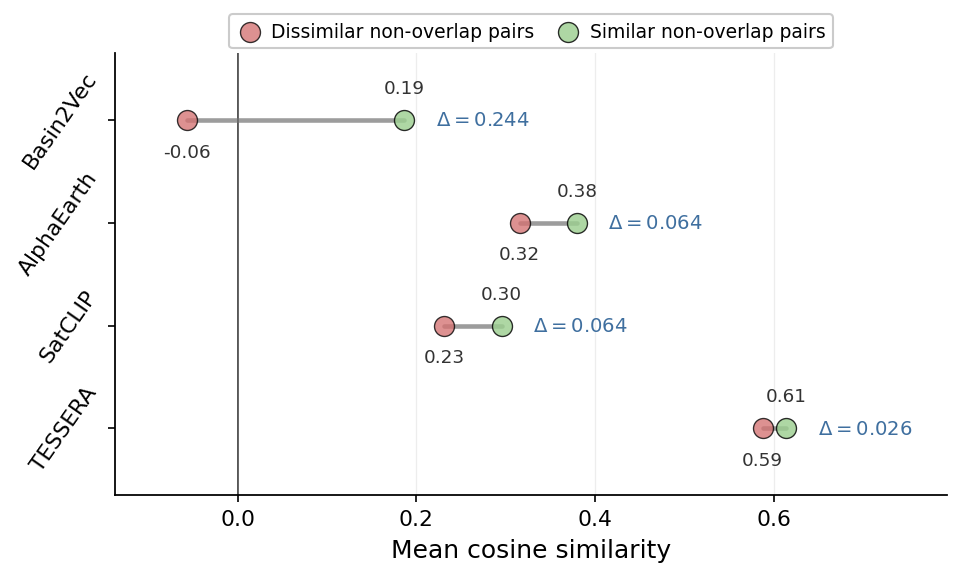

Saved: paper_results_simple_hydrologic_awareness/figures/fig_hydrologic_awareness_pair_ranking.png
Saved: paper_results_simple_hydrologic_awareness/figures/fig_hydrologic_awareness_pair_ranking.pdf
Saved figure: paper_results_simple_hydrologic_awareness/figures/fig_hydrologic_awareness_pair_ranking.png
Saved figure: paper_results_simple_hydrologic_awareness/figures/fig_hydrologic_awareness_pair_ranking.pdf


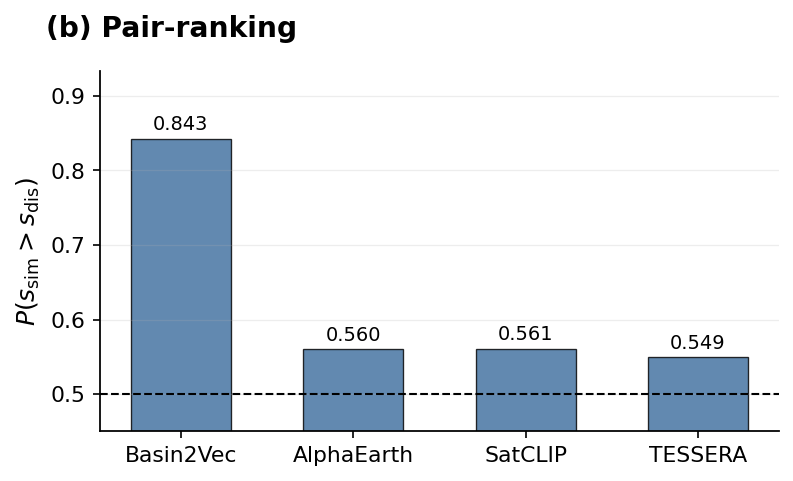


Paper-ready interpretation
Basin2Vec achieves a non-overlap hydrologic separation gap of 0.244, compared with the best EO baseline (SatCLIP) at 0.064.
This is 3.78x larger than the best EO baseline gap.
The pair-ranking score is 0.843 for Basin2Vec, compared with the best EO baseline (SatCLIP) at 0.561.


In [65]:
#!/usr/bin/env python3
# ==========================================================
# Hydrologic-awareness comparison for Basin2Vec vs EO embeddings
#
# Updated plotting:
#   1. Horizontal dumbbell plot:
#        - green dot: similar-pair mean cosine similarity
#        - red dot: dissimilar-pair mean cosine similarity
#        - gray segment: hydrologic separation gap
#        - text label: Delta_hydro = mean_similar - mean_dissimilar
#   2. Separate pair-ranking plot
#
# Main diagnostic:
#   Only NON-OVERLAPPING basin pairs:
#       1. Physiographically similar non-overlap basins
#       2. Physiographically dissimilar non-overlap basins
#
# Metrics:
#   mean_similar
#   mean_dissimilar
#   Delta_hydro = mean_similar - mean_dissimilar
#   Pair-ranking score = P(similar_pair_similarity > dissimilar_pair_similarity)
#
# Outputs:
#   paper_results_simple_hydrologic_awareness/
#       figures/
#           fig_hydrologic_awareness_mean_and_gap.png/pdf
#           fig_hydrologic_awareness_dumbbell.png/pdf
#           fig_hydrologic_awareness_pair_ranking.png/pdf
#       tables/
#           simple_hydrologic_awareness_summary.csv
#           shared_nonoverlap_pairs.csv
#       arrays/
#           simple_hydrologic_awareness_distributions.npz
# ==========================================================

from __future__ import annotations

from pathlib import Path
from collections import defaultdict
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


# ==========================================================
# CONFIG
# ==========================================================

SEED = 42
RNG = np.random.default_rng(SEED)

ALPHAEARTH_NPZ = Path(
    "alphaearth_embeddings/embeddings/alphaearth_annual_basin_embeddings_2017_2024_scale500m.npz"
)
SATCLIP_NPZ = Path("satclip_embeddings/satclip_8point_2024_embeddings.npz")
TESSERA_NPZ = Path("tessera_embeddings/tessera_8point_2024_embeddings.npz")
BASIN2VEC_NPZ = Path(
    "../src/evaluation_outputs/HCLV4_grouped_monthly_static_meta_areaaux_64d/basin_embeddings_full.npz"
)

BASIN_METADATA_PATH = Path("/data/basin2vec/cache/metadata/basin_metadata.parquet")
OVERLAP_PAIRS_PARQUET = Path("/data/basin2vec/cache/basin_overlap_pairs.parquet")

OUT_DIR = Path("paper_results_simple_hydrologic_awareness")
FIG_DIR = OUT_DIR / "figures"
TABLE_DIR = OUT_DIR / "tables"
ARRAY_DIR = OUT_DIR / "arrays"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
ARRAY_DIR.mkdir(parents=True, exist_ok=True)

MODEL_CONFIGS = [
    {
        "name": "Basin2Vec",
        "path": BASIN2VEC_NPZ,
        "sample_embedding_key": "embeddings",
        "basin_embedding_key": "avg_embeddings",
        "basin_label_key": "avg_labels",
        "year_min": 1985,
        "year_max": 2024,
    },
    {
        "name": "AlphaEarth",
        "path": ALPHAEARTH_NPZ,
        "sample_embedding_key": "embeddings",
        "basin_embedding_key": None,
        "basin_label_key": None,
        "year_min": 2017,
        "year_max": 2024,
    },
    {
        "name": "SatCLIP",
        "path": SATCLIP_NPZ,
        "sample_embedding_key": "embeddings",
        "basin_embedding_key": None,
        "basin_label_key": None,
        "year_min": None,
        "year_max": None,
    },
    {
        "name": "TESSERA",
        "path": TESSERA_NPZ,
        "sample_embedding_key": "embeddings",
        "basin_embedding_key": None,
        "basin_label_key": None,
        "year_min": None,
        "year_max": None,
    },
]

MODEL_ORDER = ["Basin2Vec", "AlphaEarth", "SatCLIP", "TESSERA"]

META_TAU = 1.5
META_SIMILAR_Q = 0.90
META_DISSIMILAR_Q = 0.10

MAX_CANDIDATE_NONOVERLAP_PAIRS = 300_000
MAX_SIMILAR_PAIRS = 50_000
MAX_DISSIMILAR_PAIRS = 50_000

AUC_SAMPLE_PAIRS = 300_000

DEFAULT_METADATA_COLUMNS = [
    "log_area_km2_z",
    "log_bbox_width_km_z",
    "log_bbox_height_km_z",
    "log_patch_pixel_width_km_z",
    "log_patch_pixel_height_km_z",
    "log_patch_pixel_area_km2_z",
    "bbox_fill_fraction_z",
    "compactness_z",
    "solidity_z",
    "log_shape_index_z",
    "log_overlap_degree_z",
]


# ==========================================================
# THEME
# ==========================================================

THEME = {
    "same_blue": "#7cafe6",
    "related_green": "#9ccf90",
    "negative_red": "#d47272",
    "line_blue": "#4a86c5",
    "dark_blue": "#3f6f9f",
    "grid_alpha": 0.22,
    "grid_lw": 0.60,
    "spine_lw": 0.85,
    "bar_edge": "black",
}

COLORS = {
    "similar": THEME["related_green"],
    "dissimilar": THEME["negative_red"],
    "gap": THEME["line_blue"],
    "auc": THEME["dark_blue"],
}

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 10.5,
    "ytick.labelsize": 10.5,
    "legend.fontsize": 9.5,
    "axes.grid": True,
    "grid.alpha": THEME["grid_alpha"],
    "grid.linewidth": THEME["grid_lw"],
    "axes.spines.top": False,
    "axes.spines.right": False,
})


# ==========================================================
# BASIC HELPERS
# ==========================================================

def normalize_site_id(x) -> str | None:
    if pd.isna(x):
        return None

    s = str(x).strip()

    if s.endswith(".0"):
        s = s[:-2]

    digits = re.sub(r"\D", "", s)

    if len(digits) == 0:
        return None

    if len(digits) <= 8:
        digits = digits.zfill(8)

    return digits


def l2_normalize(x: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    return x / np.clip(np.linalg.norm(x, axis=1, keepdims=True), eps, None)


def is_numeric_array(arr) -> bool:
    return np.issubdtype(np.asarray(arr).dtype, np.number)


def safe_mean(x):
    x = np.asarray(x, dtype=np.float64)
    return float(np.nanmean(x)) if len(x) else np.nan


def safe_std(x):
    x = np.asarray(x, dtype=np.float64)
    return float(np.nanstd(x)) if len(x) else np.nan


def safe_median(x):
    x = np.asarray(x, dtype=np.float64)
    return float(np.nanmedian(x)) if len(x) else np.nan


def safe_quantile(x, q):
    x = np.asarray(x, dtype=np.float64)
    return float(np.nanquantile(x, q)) if len(x) else np.nan


def savefig(path: Path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, bbox_inches="tight", dpi=300)
    print(f"Saved: {path}")


def infer_year_from_filename(path: Path) -> int | None:
    matches = re.findall(r"(?<!\d)(19\d{2}|20\d{2})(?!\d)", path.name)
    if not matches:
        return None
    return int(matches[-1])


def infer_site_id_column(df: pd.DataFrame) -> str | None:
    candidates = [
        "site_id", "siteid", "gage_id", "gageid", "gauge_id", "gaugeid",
        "station_id", "staid", "site_no", "usgs_id", "basin_id",
        "GAGE_ID", "STAID",
    ]

    lower = {str(c).lower(): c for c in df.columns}

    for c in candidates:
        if c.lower() in lower:
            return lower[c.lower()]

    return None


def infer_site_id_int_column(df: pd.DataFrame) -> str | None:
    candidates = [
        "site_id_int", "site_int", "gage_id_int", "basin_id_int",
        "basin_index", "basin_idx", "index",
    ]

    lower = {str(c).lower(): c for c in df.columns}

    for c in candidates:
        if c.lower() in lower:
            return lower[c.lower()]

    return None


# ==========================================================
# LOAD EMBEDDINGS
# ==========================================================

def print_npz_keys(path: Path, model_name: str):
    data = np.load(path, allow_pickle=True)

    print("\n" + "=" * 80)
    print(f"{model_name} NPZ keys: {path}")
    print("=" * 80)

    for k in data.files:
        arr = data[k]
        print(f"{k:35s} shape={arr.shape}, dtype={arr.dtype}")

    return data


def choose_embedding_array(data, model_name: str, preferred_key: str | None = None):
    if preferred_key is not None and preferred_key in data.files:
        arr = np.asarray(data[preferred_key])
        if is_numeric_array(arr) and arr.ndim == 2:
            return preferred_key, arr.astype(np.float32)

    candidates = [
        "embeddings",
        "embedding",
        "raw_embeddings",
        "alphaearth_embeddings",
        "satclip_embeddings",
        "tessera_embeddings",
        "basin_embeddings",
        "avg_embeddings",
        "hydrologic_repr",
        "X",
        "z",
        "features",
    ]

    for key in candidates:
        if key in data.files:
            arr = np.asarray(data[key])
            if is_numeric_array(arr) and arr.ndim == 2:
                return key, arr.astype(np.float32)

    numeric = []

    for key in data.files:
        arr = np.asarray(data[key])
        if is_numeric_array(arr) and arr.ndim == 2:
            numeric.append((arr.size, key, arr))

    if numeric:
        _, key, arr = max(numeric, key=lambda x: x[0])
        print(f"Warning: auto-selected embedding key for {model_name}: {key}")
        return key, arr.astype(np.float32)

    raise KeyError(f"Could not find a 2D embedding array for {model_name}.")


def choose_site_ids(data, model_name: str, n_expected: int):
    candidates = [
        "labels",
        "avg_labels",
        "site_ids",
        "site_id",
        "gage_ids",
        "gauge_ids",
        "basin_ids",
        "basin_id",
        "ids",
        "id",
    ]

    for key in candidates:
        if key in data.files:
            arr = np.asarray(data[key])
            if arr.ndim == 1 and len(arr) == n_expected:
                return key, arr

    skip_patterns = [
        "year", "embedding", "feature", "coord", "lat", "lon",
        "x", "y", "point", "dim", "columns", "source",
    ]

    for key in data.files:
        key_lower = key.lower()

        if any(p in key_lower for p in skip_patterns):
            continue

        arr = np.asarray(data[key])

        if arr.ndim != 1 or len(arr) != n_expected:
            continue

        if arr.dtype.kind not in {"O", "U", "S", "i", "u"}:
            continue

        if np.issubdtype(arr.dtype, np.number):
            arr_min = np.nanmin(arr)
            arr_max = np.nanmax(arr)

            if 1900 <= arr_min <= 2100 and 1900 <= arr_max <= 2100:
                continue

        print(f"Warning: auto-selected site ID key for {model_name}: {key}")
        return key, arr

    raise KeyError(
        f"Could not find site/basin ID array for {model_name} "
        f"with length {n_expected}."
    )


def choose_years(data, model_name: str, n_expected: int, path: Path):
    candidates = ["years", "year", "sample_years", "embedding_years"]

    for key in candidates:
        if key in data.files:
            arr = np.asarray(data[key])
            if arr.ndim == 1 and len(arr) == n_expected:
                return key, arr.astype(int)

    inferred = infer_year_from_filename(path)

    if inferred is not None:
        print(f"{model_name}: inferred year={inferred} from filename.")
        return "inferred_from_filename", np.full(n_expected, inferred, dtype=int)

    print(f"{model_name}: no year found; using dummy year=0.")
    return "dummy_year", np.zeros(n_expected, dtype=int)


def average_by_basin(df: pd.DataFrame, emb: np.ndarray):
    df = df.copy()
    df["row"] = np.arange(len(df))

    rows = []
    out_emb = []

    for site_id, sub in df.groupby("site_id", sort=True):
        idx = sub["row"].to_numpy(dtype=int)

        z = emb[idx].mean(axis=0, keepdims=True)
        z = l2_normalize(z)[0]

        rows.append({
            "site_id": str(site_id),
            "n_samples": int(len(idx)),
            "n_years": int(sub["year"].nunique()),
            "min_year": int(sub["year"].min()),
            "max_year": int(sub["year"].max()),
        })

        out_emb.append(z)

    out_df = pd.DataFrame(rows)
    out_emb = np.stack(out_emb, axis=0).astype(np.float32)

    return out_df, out_emb


def load_model_embeddings(cfg: dict):
    model_name = cfg["name"]
    path = Path(cfg["path"])

    if not path.exists():
        raise FileNotFoundError(f"{model_name} NPZ not found: {path}")

    data = print_npz_keys(path, model_name)

    sample_key, sample_emb = choose_embedding_array(
        data=data,
        model_name=model_name,
        preferred_key=cfg.get("sample_embedding_key"),
    )

    n = sample_emb.shape[0]

    site_key, site_ids_raw = choose_site_ids(
        data=data,
        model_name=model_name,
        n_expected=n,
    )

    year_key, years = choose_years(
        data=data,
        model_name=model_name,
        n_expected=n,
        path=path,
    )

    site_ids = np.array(
        [normalize_site_id(x) for x in site_ids_raw],
        dtype=object,
    )

    sample_df = pd.DataFrame({
        "site_id": site_ids,
        "year": years.astype(int),
    })

    valid = sample_df["site_id"].notna().to_numpy(dtype=bool, copy=True)
    year_arr = sample_df["year"].to_numpy(dtype=int, copy=False)

    year_min = cfg.get("year_min")
    year_max = cfg.get("year_max")

    if year_min is not None:
        valid = valid & (year_arr >= int(year_min))

    if year_max is not None:
        valid = valid & (year_arr <= int(year_max))

    sample_df = sample_df.loc[valid].reset_index(drop=True)
    sample_emb = sample_emb[valid]
    sample_emb = l2_normalize(sample_emb)

    if len(sample_df) == 0:
        raise RuntimeError(f"{model_name}: no samples after filtering.")

    basin_key = cfg.get("basin_embedding_key")
    basin_label_key = cfg.get("basin_label_key")

    use_precomputed_basin = (
        basin_key is not None
        and basin_label_key is not None
        and basin_key in data.files
        and basin_label_key in data.files
        and len(data[basin_key]) == len(data[basin_label_key])
    )

    if use_precomputed_basin:
        basin_emb = np.asarray(data[basin_key], dtype=np.float32)
        basin_emb = l2_normalize(basin_emb)

        basin_site_ids = np.array(
            [normalize_site_id(x) for x in data[basin_label_key]],
            dtype=object,
        )

        basin_df = pd.DataFrame({"site_id": basin_site_ids})
        keep = basin_df["site_id"].notna().to_numpy(dtype=bool, copy=True)

        basin_df = basin_df.loc[keep].reset_index(drop=True)
        basin_emb = basin_emb[keep]

        print(f"{model_name}: using precomputed basin-level embeddings: {basin_key}")

    else:
        basin_df, basin_emb = average_by_basin(sample_df, sample_emb)
        print(f"{model_name}: computed basin-level embeddings by averaging samples.")

    print("\nLoaded model:", model_name)
    print("  sample key:", sample_key)
    print("  site key:", site_key)
    print("  year key:", year_key)
    print("  sample shape:", sample_emb.shape)
    print("  sample basins:", sample_df["site_id"].nunique())
    print("  basin shape:", basin_emb.shape)
    print("  basin count:", basin_df["site_id"].nunique())
    print("  sample year range:", int(sample_df["year"].min()), "-", int(sample_df["year"].max()))

    return {
        "name": model_name,
        "sample_df": sample_df,
        "sample_emb": sample_emb,
        "basin_df": basin_df,
        "basin_emb": basin_emb,
    }


# ==========================================================
# LOAD METADATA AND OVERLAP
# ==========================================================

def load_basin_metadata(path: Path):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Metadata file not found: {path}")

    if path.suffix.lower() == ".parquet":
        df = pd.read_parquet(path)
    else:
        df = pd.read_csv(path)

    df = df.copy()

    site_col = infer_site_id_column(df)
    int_col = infer_site_id_int_column(df)

    if site_col is None:
        raise KeyError("Could not infer site ID column from metadata.")

    if int_col is None:
        raise KeyError("Could not infer integer basin ID column from metadata.")

    df["site_id"] = df[site_col].apply(normalize_site_id)
    df["site_id_int"] = pd.to_numeric(df[int_col], errors="coerce").astype("Int64")

    meta_cols = [c for c in DEFAULT_METADATA_COLUMNS if c in df.columns]

    if len(meta_cols) == 0:
        raise KeyError("No expected metadata feature columns found.")

    for c in meta_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
        df[c] = df[c].fillna(df[c].median(skipna=True))

    out = (
        df[["site_id", "site_id_int"] + meta_cols]
        .dropna(subset=["site_id", "site_id_int"])
        .drop_duplicates(subset=["site_id"])
        .reset_index(drop=True)
    )

    out["site_id_int"] = out["site_id_int"].astype(int)

    print("\nLoaded metadata")
    print("  path:", path)
    print("  site column:", site_col)
    print("  int column:", int_col)
    print("  basins:", len(out))
    print("  features:", meta_cols)

    return out, meta_cols


def load_overlap_pairs(path: Path, meta_df: pd.DataFrame):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Overlap file not found: {path}")

    odf = pd.read_parquet(path).copy()

    if "site_id_a" in odf.columns and "site_id_b" in odf.columns:
        a_site = odf["site_id_a"].apply(normalize_site_id)
        b_site = odf["site_id_b"].apply(normalize_site_id)

    elif "site_id_int_a" in odf.columns and "site_id_int_b" in odf.columns:
        int_to_site = dict(
            zip(
                meta_df["site_id_int"].astype(int),
                meta_df["site_id"].astype(str),
            )
        )

        a_site = odf["site_id_int_a"].astype(int).map(int_to_site)
        b_site = odf["site_id_int_b"].astype(int).map(int_to_site)

    else:
        raise KeyError(
            "Overlap parquet must contain either site_id_a/site_id_b "
            "or site_id_int_a/site_id_int_b."
        )

    overlap_neighbors = defaultdict(set)

    for i in range(len(odf)):
        a = a_site.iloc[i]
        b = b_site.iloc[i]

        if pd.isna(a) or pd.isna(b) or a == b:
            continue

        a = str(a)
        b = str(b)

        overlap_neighbors[a].add(b)
        overlap_neighbors[b].add(a)

    n_edges = sum(len(v) for v in overlap_neighbors.values()) // 2

    print("\nLoaded overlap graph")
    print("  path:", path)
    print("  overlap edges:", n_edges)

    return overlap_neighbors


# ==========================================================
# COMMON BASIN ALIGNMENT
# ==========================================================

def align_models_to_common_basins(models: dict, meta_df: pd.DataFrame, meta_cols: list[str]):
    common = set(meta_df["site_id"].astype(str).tolist())

    for model in models.values():
        common &= set(model["basin_df"]["site_id"].astype(str).tolist())

    common_ids = sorted(common)

    if len(common_ids) == 0:
        raise RuntimeError("No common basins across all models and metadata.")

    print("\nCommon basin alignment")
    print("  common basins:", len(common_ids))

    meta_map = meta_df.drop_duplicates(subset=["site_id"]).set_index("site_id")
    meta_sub = meta_map.loc[common_ids]

    X_meta = meta_sub[meta_cols].to_numpy(dtype=np.float32)

    X_meta = (X_meta - X_meta.mean(axis=0, keepdims=True)) / np.clip(
        X_meta.std(axis=0, keepdims=True),
        1e-6,
        None,
    )

    aligned = {}

    for model_name, model in models.items():
        basin_df = model["basin_df"].copy()
        basin_df["row"] = np.arange(len(basin_df))

        row_map = (
            basin_df.drop_duplicates(subset=["site_id"])
            .set_index("site_id")["row"]
            .to_dict()
        )

        idx = np.array([row_map[sid] for sid in common_ids], dtype=int)

        emb = model["basin_emb"][idx]
        emb = l2_normalize(emb)

        aligned[model_name] = {
            **model,
            "common_basin_ids": common_ids,
            "common_basin_emb": emb,
        }

        print(f"  {model_name}: aligned shape={emb.shape}")

    return common_ids, X_meta, aligned


# ==========================================================
# BUILD SHARED NON-OVERLAP PAIRS
# ==========================================================

def sample_nonoverlap_candidates(common_ids, overlap_neighbors, n_pairs=300_000):
    common_ids = np.asarray(common_ids).astype(str)
    n = len(common_ids)

    pairs = []
    seen = set()

    attempts = 0
    max_attempts = max(n_pairs * 25, 100_000)

    while len(pairs) < n_pairs and attempts < max_attempts:
        i = int(RNG.integers(0, n))
        j = int(RNG.integers(0, n - 1))

        if j >= i:
            j += 1

        a = common_ids[i]
        b = common_ids[j]

        attempts += 1

        if a == b:
            continue

        if b in overlap_neighbors.get(a, set()):
            continue

        key = (i, j) if i < j else (j, i)

        if key in seen:
            continue

        seen.add(key)
        pairs.append(key)

    return pairs


def metadata_similarity_for_pairs(X_meta, pairs, tau=1.5):
    if len(pairs) == 0:
        return np.array([], dtype=np.float32)

    pairs = np.asarray(pairs, dtype=np.int64)

    diff = X_meta[pairs[:, 0]] - X_meta[pairs[:, 1]]
    d2 = np.sum(diff * diff, axis=1)

    sims = np.exp(-d2 / (2.0 * tau * tau))

    return sims.astype(np.float32)


def build_shared_nonoverlap_pairs(common_ids, X_meta, overlap_neighbors):
    candidates = sample_nonoverlap_candidates(
        common_ids=common_ids,
        overlap_neighbors=overlap_neighbors,
        n_pairs=MAX_CANDIDATE_NONOVERLAP_PAIRS,
    )

    if len(candidates) == 0:
        raise RuntimeError("No non-overlap candidate pairs were sampled.")

    meta_sims = metadata_similarity_for_pairs(
        X_meta=X_meta,
        pairs=candidates,
        tau=META_TAU,
    )

    candidates_arr = np.asarray(candidates, dtype=np.int64)

    q_hi = float(np.quantile(meta_sims, META_SIMILAR_Q))
    q_lo = float(np.quantile(meta_sims, META_DISSIMILAR_Q))

    similar_idx = np.where(meta_sims >= q_hi)[0]
    dissimilar_idx = np.where(meta_sims <= q_lo)[0]

    if len(similar_idx) > MAX_SIMILAR_PAIRS:
        similar_idx = RNG.choice(similar_idx, size=MAX_SIMILAR_PAIRS, replace=False)

    if len(dissimilar_idx) > MAX_DISSIMILAR_PAIRS:
        dissimilar_idx = RNG.choice(dissimilar_idx, size=MAX_DISSIMILAR_PAIRS, replace=False)

    similar_pairs = [tuple(x) for x in candidates_arr[similar_idx]]
    dissimilar_pairs = [tuple(x) for x in candidates_arr[dissimilar_idx]]

    print("\nShared non-overlap pair construction")
    print("  candidate non-overlap pairs:", len(candidates))
    print("  similar quantile:", META_SIMILAR_Q, "threshold:", q_hi)
    print("  dissimilar quantile:", META_DISSIMILAR_Q, "threshold:", q_lo)
    print("  similar non-overlap pairs:", len(similar_pairs))
    print("  dissimilar non-overlap pairs:", len(dissimilar_pairs))

    return similar_pairs, dissimilar_pairs, q_hi, q_lo


def save_shared_pairs(common_ids, similar_pairs, dissimilar_pairs):
    rows = []

    for relation, pairs in [
        ("similar_nonoverlap", similar_pairs),
        ("dissimilar_nonoverlap", dissimilar_pairs),
    ]:
        for i, j in pairs:
            rows.append({
                "relation": relation,
                "idx_i": int(i),
                "idx_j": int(j),
                "site_id_i": common_ids[int(i)],
                "site_id_j": common_ids[int(j)],
            })

    out = pd.DataFrame(rows)
    path = TABLE_DIR / "shared_nonoverlap_pairs.csv"
    out.to_csv(path, index=False)

    print("\nSaved shared non-overlap pairs:")
    print(path)


# ==========================================================
# COMPUTE SIMILARITIES AND SUMMARY
# ==========================================================

def cosine_for_pairs(emb, pairs):
    if len(pairs) == 0:
        return np.array([], dtype=np.float32)

    pairs = np.asarray(pairs, dtype=np.int64)

    return np.sum(
        emb[pairs[:, 0]] * emb[pairs[:, 1]],
        axis=1,
    ).astype(np.float32)


def approximate_auc_probability(similar_values, dissimilar_values, n_samples=300_000):
    similar_values = np.asarray(similar_values, dtype=np.float32)
    dissimilar_values = np.asarray(dissimilar_values, dtype=np.float32)

    similar_values = similar_values[np.isfinite(similar_values)]
    dissimilar_values = dissimilar_values[np.isfinite(dissimilar_values)]

    if len(similar_values) == 0 or len(dissimilar_values) == 0:
        return np.nan

    s = RNG.choice(similar_values, size=n_samples, replace=True)
    d = RNG.choice(dissimilar_values, size=n_samples, replace=True)

    return float(np.mean(s > d) + 0.5 * np.mean(s == d))


def build_simple_summary(aligned_models, similar_pairs, dissimilar_pairs):
    distributions = {}
    rows = []

    for model_name, model in aligned_models.items():
        emb = model["common_basin_emb"]

        sim_vals = cosine_for_pairs(emb, similar_pairs)
        dis_vals = cosine_for_pairs(emb, dissimilar_pairs)

        delta_hydro = safe_mean(sim_vals) - safe_mean(dis_vals)
        auc_prob = approximate_auc_probability(
            sim_vals,
            dis_vals,
            n_samples=AUC_SAMPLE_PAIRS,
        )

        distributions[f"{model_name}_similar"] = sim_vals
        distributions[f"{model_name}_dissimilar"] = dis_vals

        rows.append({
            "model": model_name,
            "n_similar_pairs": int(len(sim_vals)),
            "n_dissimilar_pairs": int(len(dis_vals)),
            "mean_similar_nonoverlap": safe_mean(sim_vals),
            "mean_dissimilar_nonoverlap": safe_mean(dis_vals),
            "median_similar_nonoverlap": safe_median(sim_vals),
            "median_dissimilar_nonoverlap": safe_median(dis_vals),
            "std_similar_nonoverlap": safe_std(sim_vals),
            "std_dissimilar_nonoverlap": safe_std(dis_vals),
            "q25_similar_nonoverlap": safe_quantile(sim_vals, 0.25),
            "q75_similar_nonoverlap": safe_quantile(sim_vals, 0.75),
            "q25_dissimilar_nonoverlap": safe_quantile(dis_vals, 0.25),
            "q75_dissimilar_nonoverlap": safe_quantile(dis_vals, 0.75),
            "delta_hydro_similar_minus_dissimilar": delta_hydro,
            "ranking_probability_auc_like": auc_prob,
        })

    summary_df = pd.DataFrame(rows)

    eo_mask = summary_df["model"] != "Basin2Vec"

    best_eo_delta = summary_df.loc[
        eo_mask,
        "delta_hydro_similar_minus_dissimilar",
    ].max()

    best_eo_auc = summary_df.loc[
        eo_mask,
        "ranking_probability_auc_like",
    ].max()

    summary_df["delta_vs_best_eo"] = (
        summary_df["delta_hydro_similar_minus_dissimilar"] - best_eo_delta
    )

    summary_df["auc_vs_best_eo"] = (
        summary_df["ranking_probability_auc_like"] - best_eo_auc
    )

    summary_path = TABLE_DIR / "simple_hydrologic_awareness_summary.csv"
    summary_df.to_csv(summary_path, index=False)

    npz_path = ARRAY_DIR / "simple_hydrologic_awareness_distributions.npz"
    np.savez_compressed(npz_path, **distributions)

    print("\nSaved summary:")
    print(summary_path)
    print(summary_df.to_string(index=False))

    print("\nSaved distributions:")
    print(npz_path)

    return summary_df, distributions


# ==========================================================
# PLOTTING HELPERS
# ==========================================================

def ordered_summary(summary_df):
    return summary_df.set_index("model").loc[MODEL_ORDER].reset_index()


def add_panel_label(ax, label, x=-0.08, y=1.08, fontsize=13.5):
    ax.text(
        x,
        y,
        label,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=fontsize,
        fontweight="bold",
        clip_on=False,
    )


def add_bar_labels(
    ax,
    bars,
    fmt="{:.3f}",
    y_pad=0.012,
    fontsize=9.5,
    color="black",
):
    ymin, ymax = ax.get_ylim()
    yrange = ymax - ymin

    for b in bars:
        h = b.get_height()

        if np.isnan(h):
            continue

        if h >= 0:
            y = h + y_pad * yrange
            va = "bottom"
        else:
            y = h - y_pad * yrange
            va = "top"

        ax.text(
            b.get_x() + b.get_width() / 2,
            y,
            fmt.format(h),
            ha="center",
            va=va,
            fontsize=fontsize,
            color=color,
        )


def style_axis(ax, y_grid=True):
    if y_grid:
        ax.grid(True, axis="y", alpha=THEME["grid_alpha"], linewidth=THEME["grid_lw"])
        ax.grid(False, axis="x")
    else:
        ax.grid(True, alpha=THEME["grid_alpha"], linewidth=THEME["grid_lw"])

    ax.spines["left"].set_linewidth(THEME["spine_lw"])
    ax.spines["bottom"].set_linewidth(THEME["spine_lw"])
    ax.tick_params(axis="both", labelsize=10.5, width=0.8)


def save_current_figure(base_name: str):
    out_png = FIG_DIR / f"{base_name}.png"
    out_pdf = FIG_DIR / f"{base_name}.pdf"

    savefig(out_png)
    savefig(out_pdf)

    print(f"Saved figure: {out_png}")
    print(f"Saved figure: {out_pdf}")


# ==========================================================
# DUMBBELL PLOT:
#   Similar vs dissimilar mean cosine similarity
#   Hydrologic gap shown directly on same plot
# ==========================================================

def plot_mean_similarity_and_gap_figure(summary_df):
    df = ordered_summary(summary_df)

    models = df["model"].tolist()
    sim_means = df["mean_similar_nonoverlap"].to_numpy(dtype=float)
    dis_means = df["mean_dissimilar_nonoverlap"].to_numpy(dtype=float)
    gap_vals = df["delta_hydro_similar_minus_dissimilar"].to_numpy(dtype=float)

    # Reverse y positions so Basin2Vec appears at the top.
    y = np.arange(len(df))[::-1]

    fig, ax = plt.subplots(
        1,
        1,
        figsize=(7.2, 4.6),
        facecolor="white",
    )

    xmin = min(np.nanmin(dis_means), np.nanmin(sim_means), 0.0) - 0.08
    xmax = max(np.nanmax(dis_means), np.nanmax(sim_means)) + 0.18

    ax.set_xlim(xmin, xmax)

    ax.axvline(
        0.0,
        color="black",
        linewidth=0.85,
        alpha=0.75,
        zorder=1,
    )

    for i, yi in enumerate(y):
        x0 = dis_means[i]
        x1 = sim_means[i]
        gap = gap_vals[i]

        ax.plot(
            [x0, x1],
            [yi, yi],
            color="0.45",
            linewidth=2.2,
            alpha=0.70,
            solid_capstyle="round",
            zorder=2,
        )

        ax.scatter(
            x0,
            yi,
            s=92,
            color=COLORS["dissimilar"],
            edgecolor=THEME["bar_edge"],
            linewidth=0.65,
            alpha=0.78,
            zorder=4,
            label="Dissimilar non-overlap pairs" if i == 0 else None,
        )

        ax.scatter(
            x1,
            yi,
            s=92,
            color=COLORS["similar"],
            edgecolor=THEME["bar_edge"],
            linewidth=0.65,
            alpha=0.82,
            zorder=5,
            label="Similar non-overlap pairs" if i == 0 else None,
        )

        ax.text(
            x0,
            yi - 0.22,
            f"{x0:.2f}",
            ha="center",
            va="top",
            fontsize=8.8,
            color="0.20",
        )

        ax.text(
            x1,
            yi + 0.22,
            f"{x1:.2f}",
            ha="center",
            va="bottom",
            fontsize=8.8,
            color="0.20",
        )

        x_label = max(x0, x1) + 0.035

        ax.text(
            x_label,
            yi,
            rf"$\Delta={gap:.3f}$",
            ha="left",
            va="center",
            fontsize=9.4,
            color=THEME["dark_blue"],
            fontweight="bold" if models[i] == "Basin2Vec" else "normal",
        )

    ax.set_yticks(y)
    ax.set_yticklabels(
        models,
        rotation=55,
        ha="right",
        va="center",
    )

    ax.set_xlabel("Mean cosine similarity")
    # ax.set_ylabel("Representation")

    # add_panel_label(
    #     ax,
    #     "(a) Hydrologic awareness beyond overlap",
    #     x=-0.08,
    #     y=1.08,
    # )

    ax.legend(
        frameon=True,
        fontsize=9.0,
        loc="upper center",
        bbox_to_anchor=(0.50, 1.11),
        edgecolor="0.75",
        ncol=2,
        columnspacing=1.1,
        handlelength=1.4,
        handletextpad=0.45,
    )

    ax.grid(True, axis="x", alpha=THEME["grid_alpha"], linewidth=THEME["grid_lw"])
    ax.grid(False, axis="y")

    ax.spines["left"].set_linewidth(THEME["spine_lw"])
    ax.spines["bottom"].set_linewidth(THEME["spine_lw"])
    ax.tick_params(axis="both", labelsize=10.5, width=0.8)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_ylim(-0.65, len(df) - 0.35)

    fig.subplots_adjust(
        left=0.19,
        right=0.96,
        bottom=0.19,
        top=0.83,
    )

    save_current_figure("fig_hydrologic_awareness_mean_and_gap")
    save_current_figure("fig_hydrologic_awareness_dumbbell")
    plt.show()


# ==========================================================
# PLOT 2: PAIR-RANKING SCORE
# ==========================================================

def plot_pair_ranking_figure(summary_df):
    df = ordered_summary(summary_df)

    x = np.arange(len(df))
    auc = df["ranking_probability_auc_like"].to_numpy()

    fig, ax = plt.subplots(
        1,
        1,
        figsize=(6.2, 4.8),
        facecolor="white",
    )

    bars = ax.bar(
        x,
        auc,
        width=0.58,
        color=COLORS["auc"],
        alpha=0.82,
        edgecolor=THEME["bar_edge"],
        linewidth=0.65,
    )

    add_panel_label(ax, "(b) Pair-ranking", x=-0.08, y=1.08)

    ax.set_ylabel(r"$P(s_{\mathrm{sim}}>s_{\mathrm{dis}})$", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(df["model"].tolist(), rotation=0, ha="center")
    ax.axhline(0.5, color="black", linestyle="--", linewidth=1.0)

    ax.set_ylim(0.45, min(1.0, max(auc) + 0.09))

    add_bar_labels(ax, bars, fmt="{:.3f}", y_pad=0.014, fontsize=9.3)

    style_axis(ax)

    fig.subplots_adjust(
        left=0.13,
        right=0.86,
        bottom=0.22,
        top=0.72,
    )

    save_current_figure("fig_hydrologic_awareness_pair_ranking")
    plt.show()


def plot_simple_figure(summary_df):
    """
    Creates:
      1. Dumbbell mean similarity + hydrologic gap figure
      2. Pair-ranking score figure
    """
    plot_mean_similarity_and_gap_figure(summary_df)
    plot_pair_ranking_figure(summary_df)


# ==========================================================
# OPTIONAL TEXT SUMMARY FOR PAPER
# ==========================================================

def print_paper_ready_summary(summary_df):
    df = ordered_summary(summary_df)

    b2v = df[df["model"] == "Basin2Vec"].iloc[0]
    eo = df[df["model"] != "Basin2Vec"].copy()

    best_eo_gap_row = eo.loc[
        eo["delta_hydro_similar_minus_dissimilar"].idxmax()
    ]

    best_eo_auc_row = eo.loc[
        eo["ranking_probability_auc_like"].idxmax()
    ]

    b2v_gap = b2v["delta_hydro_similar_minus_dissimilar"]
    best_eo_gap = best_eo_gap_row["delta_hydro_similar_minus_dissimilar"]

    b2v_auc = b2v["ranking_probability_auc_like"]
    best_eo_auc = best_eo_auc_row["ranking_probability_auc_like"]

    ratio = b2v_gap / best_eo_gap if best_eo_gap != 0 else np.nan

    print("\n" + "=" * 90)
    print("Paper-ready interpretation")
    print("=" * 90)
    print(
        f"Basin2Vec achieves a non-overlap hydrologic separation gap of "
        f"{b2v_gap:.3f}, compared with the best EO baseline "
        f"({best_eo_gap_row['model']}) at {best_eo_gap:.3f}."
    )
    print(
        f"This is {ratio:.2f}x larger than the best EO baseline gap."
    )
    print(
        f"The pair-ranking score is {b2v_auc:.3f} for Basin2Vec, compared "
        f"with the best EO baseline ({best_eo_auc_row['model']}) at {best_eo_auc:.3f}."
    )
    print("=" * 90)


# ==========================================================
# MAIN
# ==========================================================

def main():
    meta_df, meta_cols = load_basin_metadata(BASIN_METADATA_PATH)

    overlap_neighbors = load_overlap_pairs(
        OVERLAP_PAIRS_PARQUET,
        meta_df,
    )

    models = {}

    for cfg in MODEL_CONFIGS:
        print("\n" + "#" * 90)
        print(f"Loading model: {cfg['name']}")
        print("#" * 90)

        models[cfg["name"]] = load_model_embeddings(cfg)

    common_ids, X_meta, aligned_models = align_models_to_common_basins(
        models=models,
        meta_df=meta_df,
        meta_cols=meta_cols,
    )

    similar_pairs, dissimilar_pairs, q_hi, q_lo = build_shared_nonoverlap_pairs(
        common_ids=common_ids,
        X_meta=X_meta,
        overlap_neighbors=overlap_neighbors,
    )

    save_shared_pairs(
        common_ids=common_ids,
        similar_pairs=similar_pairs,
        dissimilar_pairs=dissimilar_pairs,
    )

    summary_df, distributions = build_simple_summary(
        aligned_models=aligned_models,
        similar_pairs=similar_pairs,
        dissimilar_pairs=dissimilar_pairs,
    )

    plot_simple_figure(summary_df)

    print_paper_ready_summary(summary_df)


if __name__ == "__main__":
    main()

NPZ keys:
  embeddings: shape=(362680, 64), dtype=float32
  hydrologic_repr: shape=(362680, 64), dtype=float32
  z_multisource: shape=(362680, 64), dtype=float32
  z_monthly: shape=(362680, 64), dtype=float32
  z_static: shape=(362680, 64), dtype=float32
  labels: shape=(362680,), dtype=<U15
  label_ints: shape=(362680,), dtype=int64
  years: shape=(362680,), dtype=int64
  basin_meta: shape=(362680, 11), dtype=float32
  area_target: shape=(362680,), dtype=float32
  area_pred: shape=(362680,), dtype=float32
  overlap_degree: shape=(362680,), dtype=float32
  branch_attention: shape=(362680, 2), dtype=float32
  avg_embeddings: shape=(9067, 64), dtype=float32
  avg_labels: shape=(9067,), dtype=<U15
  year_counts: shape=(9067,), dtype=int64

Using embedding key: avg_embeddings (9067, 64)
Using label key: avg_labels (9067,)

Example raw labels:
['01011000' '01013500' '01015800' '01016500' '01017000' '01017060'
 '01017290' '01017550' '01017960' '01018000']

Example normalized basin IDs:
['010

,basin_id_str,e_0,e_1,e_2,e_3,e_4,e_5,e_6,e_7,e_8,...,e_54,e_55,e_56,e_57,e_58,e_59,e_60,e_61,e_62,e_63
0,01011000,0.028154,0.226289,-0.170663,0.055144,0.105512,0.137473,-0.069746,0.163926,0.035962,...,-0.141809,0.155827,0.067694,-0.200770,-0.026672,-0.184872,-0.036528,0.029004,-0.311093,-0.273392
1,01013500,0.036632,0.205136,-0.274459,0.004306,0.129799,0.174304,-0.132646,0.072740,0.009480,...,-0.298823,0.129206,-0.019189,-0.068118,-0.017496,-0.109146,0.015805,0.069045,-0.384135,-0.213627
2,01015800,0.122622,0.272383,-0.157074,-0.004986,0.160821,0.146099,-0.032773,0.190810,-0.002906,...,-0.154329,0.187296,0.131608,-0.128442,-0.000862,-0.192264,-0.062568,0.048020,-0.307551,-0.207566
3,01016500,0.119190,0.065731,0.174524,0.159789,0.008645,0.125365,0.024082,0.203109,-0.014733,...,-0.039396,0.194355,0.251256,0.041490,0.086517,-0.064441,0.027180,-0.079944,-0.309282,-0.128055
4,01017000,0.093877,0.285555,-0.210169,-0.049331,0.144007,0.032406,-0.016692,0.108818,-0.058613,...,-0.114175,0.199859,0.082024,-0.162472,-0.014988,-0.120103,-0.024583,0.058123,-0.299567,-0.196858



Basin file CRS: EPSG:5070

Basin columns:
['AREA', 'PERIMETER', 'GAGE_ID', 'layer', 'path', 'geometry']

Using GeoPackage basin ID column: GAGE_ID

Number of basin polygons: 9067
Example GeoPackage basin IDs:
['03144816', '03145000', '03156000', '03157000', '03157500', '03219500', '03220000', '03221000', '03223000', '03224500']

Matched basins: 9067
Basins in GeoPackage: 9067
Basins in embedding file: 9067

Example polygon IDs missing from embeddings:
[]

Example embedding IDs missing from polygons:
[]


,GAGE_ID,basin_id_str
0,03144816,03144816
1,03145000,03145000
2,03156000,03156000
3,03157000,03157000
4,03157500,03157500



Projected CRS: EPSG:5070

Embedding matrix used for PCA: (9067, 64)
kNN graph shape: (9067, 9067)
Raw: alpha=0.0, n_iter=0, shape=(9067, 64)
Light smoothing: alpha=0.25, n_iter=1, shape=(9067, 64)
Medium smoothing: alpha=0.5, n_iter=3, shape=(9067, 64)
Strong smoothing: alpha=0.75, n_iter=8, shape=(9067, 64)

PCA explained variance ratio:
  PC1: 0.1025
  PC2: 0.0673
  PC3: 0.0469
  Sum: 0.2167

RGB levels:
Raw (9067, 3) min: 0.0 max: 1.0
Light smoothing (9067, 3) min: 0.0 max: 1.0
Medium smoothing (9067, 3) min: 0.0 max: 1.0
Strong smoothing (9067, 3) min: 0.0 max: 1.0


KeyboardInterrupt: 

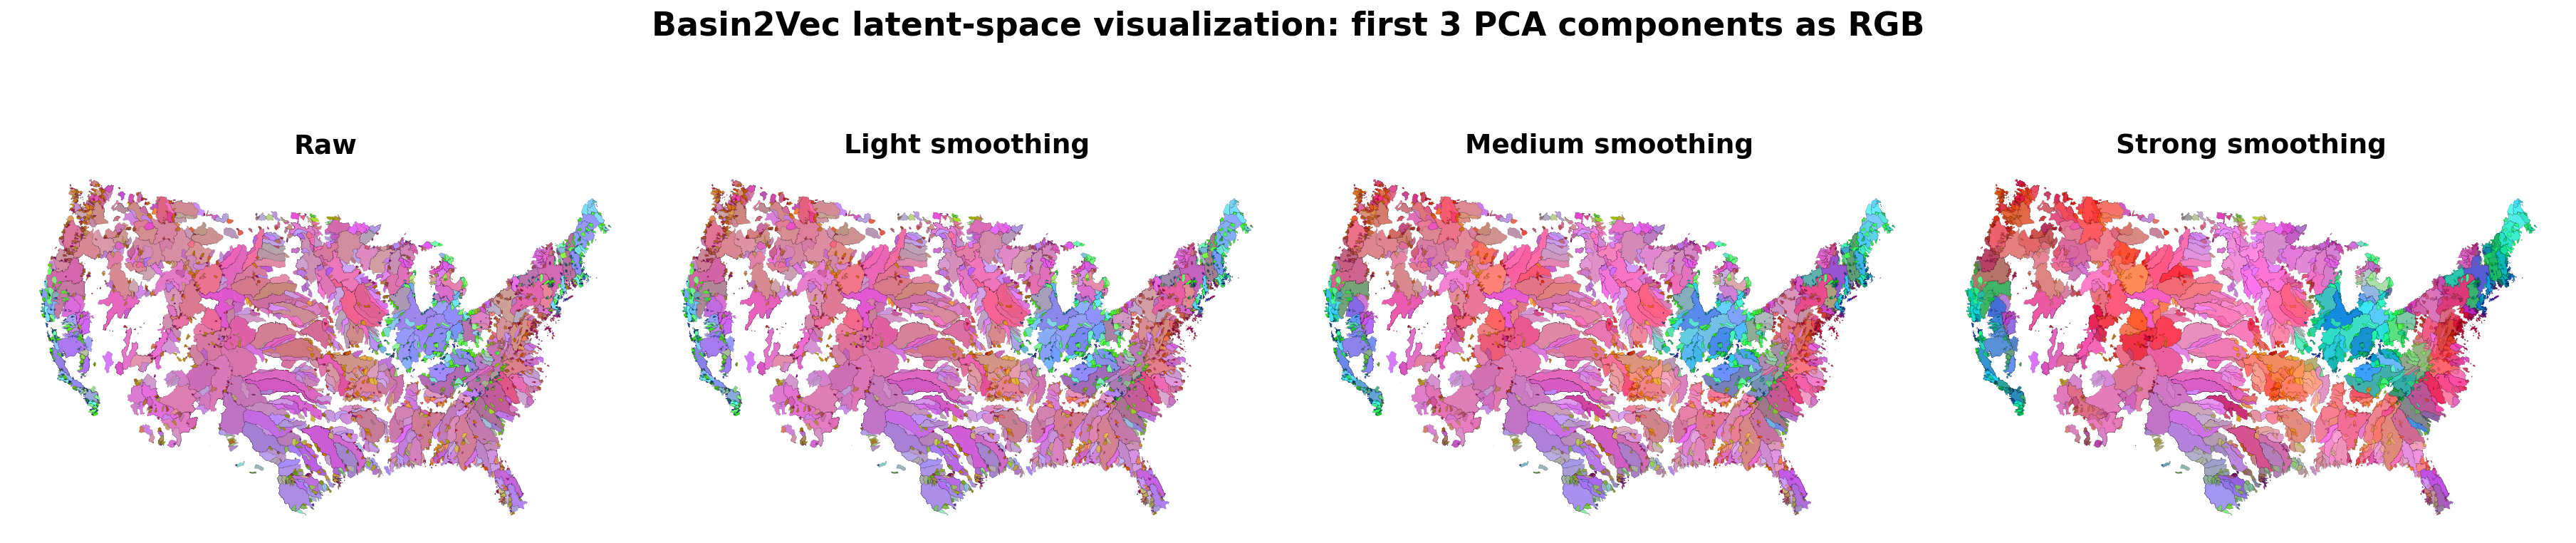

In [5]:
# ============================================================
# Basin2Vec PCA-as-RGB map with different smoothness levels
# Notebook code
#
# Uses:
#   BASIN_FILE  = /data/basin2vec/raw/gages-ii/geopackage/gages_basins.gpkg
#   BASIN_LAYER = gages_basins
#   NPZ         = basin_embeddings_full.npz
#
# Your NPZ keys include:
#   avg_embeddings, avg_labels
#
# Output:
#   Raw | Light smoothing | Medium smoothing | Strong smoothing
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix, eye
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler, normalize

warnings.filterwarnings("ignore")


# ============================================================
# 1. Paths and options
# ============================================================

BASIN_FILE = Path("/data/basin2vec/raw/gages-ii/geopackage/gages_basins.gpkg")
BASIN_LAYER = "gages_basins"

BASIN2VEC_NPZ = Path(
    "../src/evaluation_outputs/HCLV4_grouped_monthly_static_meta_areaaux_64d/basin_embeddings_full.npz"
)

# Your NPZ basin-level keys
EMBEDDING_KEY = "avg_embeddings"
LABEL_KEY = "avg_labels"

OUT_DIR = Path("./figures_basin2vec_pca_rgb")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_PNG = OUT_DIR / "basin2vec_pca_rgb_smoothness.png"
OUT_PDF = OUT_DIR / "basin2vec_pca_rgb_smoothness.pdf"
OUT_CSV = OUT_DIR / "basin2vec_pca_rgb_values_by_basin.csv"

# USGS/GAGES basin IDs are usually 8 digits
ID_ZFILL = 8

# Map projection for CONUS
MAP_CRS = "EPSG:5070"

# Spatial smoothing graph
KNN_K = 12

# Plotting
SIMPLIFY_TOLERANCE = 0      # use 500 or 1000 if plotting is slow
EDGE_COLOR = "black"
LINE_WIDTH = 0.04
FIG_DPI = 400


# ============================================================
# 2. Helper functions
# ============================================================

def normalize_basin_id(x, zfill=8):
    """
    Normalize basin/gage IDs so GeoPackage IDs and NPZ labels match.
    Handles int, float, bytes, and strings like '01013500_2001'.
    """
    if x is None or pd.isna(x):
        return None

    if isinstance(x, bytes):
        x = x.decode("utf-8")

    if isinstance(x, (float, np.floating)):
        if np.isfinite(x) and float(x).is_integer():
            s = str(int(x))
        else:
            s = str(x)
    elif isinstance(x, (int, np.integer)):
        s = str(int(x))
    else:
        s = str(x).strip()

    s = s.replace("'", "").replace('"', "").strip()

    if s.endswith(".0") and s[:-2].isdigit():
        s = s[:-2]

    # If labels look like basin-year labels, keep only basin part
    for sep in ["_", "-", "|", "/", " "]:
        if sep in s:
            first = s.split(sep)[0]
            if first.isdigit():
                s = first
                break

    if zfill is not None and zfill > 0 and s.isdigit():
        s = s.zfill(zfill)

    return s


def find_first_existing_column(gdf, candidate_cols):
    """Find basin ID column using case-insensitive matching."""
    col_map = {c.lower(): c for c in gdf.columns}

    for c in candidate_cols:
        if c in gdf.columns:
            return c
        if c.lower() in col_map:
            return col_map[c.lower()]

    return None


def clean_standardize_l2(X):
    """
    Clean NaN/inf, z-score each embedding dimension,
    then L2-normalize each basin vector.

    copy=True is important because GeoPandas/Pandas can return read-only views.
    """
    X = np.array(X, dtype=np.float32, copy=True)

    X[~np.isfinite(X)] = np.nan

    col_median = np.nanmedian(X, axis=0)
    col_median[~np.isfinite(col_median)] = 0.0

    bad_rows, bad_cols = np.where(np.isnan(X))
    if len(bad_rows) > 0:
        X[bad_rows, bad_cols] = col_median[bad_cols]

    X = StandardScaler().fit_transform(X)
    X = normalize(X, norm="l2", axis=1)

    return np.array(X, dtype=np.float32, copy=True)


def build_knn_graph(gdf_projected, k=12, include_self=True):
    """
    Build row-normalized Gaussian-weighted kNN graph from basin centroids.
    """
    centroids = gdf_projected.geometry.centroid
    coords = np.column_stack([centroids.x.values, centroids.y.values])

    n = coords.shape[0]
    k_eff = min(k + 1, n)

    nbrs = NearestNeighbors(n_neighbors=k_eff)
    nbrs.fit(coords)

    distances, indices = nbrs.kneighbors(coords)

    # Remove self-neighbor
    distances = distances[:, 1:]
    indices = indices[:, 1:]

    sigma = np.median(distances[:, -1])
    if not np.isfinite(sigma) or sigma <= 0:
        positive_dist = distances[distances > 0]
        sigma = np.median(positive_dist) if len(positive_dist) > 0 else 1.0

    weights = np.exp(-((distances / sigma) ** 2))

    rows = np.repeat(np.arange(n), indices.shape[1])
    cols = indices.reshape(-1)
    vals = weights.reshape(-1)

    W = csr_matrix((vals, (rows, cols)), shape=(n, n))

    # Symmetric graph
    W = 0.5 * (W + W.T)

    if include_self:
        W = W + eye(n, format="csr")

    # Row normalize
    row_sums = np.asarray(W.sum(axis=1)).ravel()
    row_sums[row_sums == 0] = 1.0

    inv_row_sums = 1.0 / row_sums
    D_inv = csr_matrix(
        (inv_row_sums, (np.arange(n), np.arange(n))),
        shape=(n, n),
    )

    W = D_inv @ W

    return W


def smooth_embeddings_graph(X0, W, alpha=0.5, n_iter=3, renormalize=True):
    """
    Anchored graph smoothing:

        X_{t+1} = (1 - alpha) X0 + alpha W X_t

    alpha = 0 means no smoothing.
    Larger alpha and more iterations create smoother maps.
    """
    X0 = np.array(X0, dtype=np.float32, copy=True)

    if alpha <= 0 or n_iter <= 0:
        return X0.copy()

    X = X0.copy()

    for _ in range(n_iter):
        X = (1.0 - alpha) * X0 + alpha * (W @ X)

        if renormalize:
            X = normalize(X, norm="l2", axis=1)
            X = np.array(X, dtype=np.float32, copy=True)

    return np.array(X, dtype=np.float32, copy=True)


# ============================================================
# 3. Load Basin2Vec NPZ
# ============================================================

npz = np.load(BASIN2VEC_NPZ, allow_pickle=True)

print("NPZ keys:")
for k in npz.files:
    arr = npz[k]
    print(f"  {k}: shape={getattr(arr, 'shape', None)}, dtype={getattr(arr, 'dtype', None)}")

if EMBEDDING_KEY not in npz.files:
    raise KeyError(f"'{EMBEDDING_KEY}' not found. Available keys: {npz.files}")

if LABEL_KEY not in npz.files:
    raise KeyError(f"'{LABEL_KEY}' not found. Available keys: {npz.files}")

E_basin = np.array(npz[EMBEDDING_KEY], dtype=np.float32, copy=True)
labels_raw = np.array(npz[LABEL_KEY], copy=True)

print("\nUsing embedding key:", EMBEDDING_KEY, E_basin.shape)
print("Using label key:", LABEL_KEY, labels_raw.shape)

if E_basin.ndim != 2:
    raise ValueError(f"Expected {EMBEDDING_KEY} to be [N, D]. Got {E_basin.shape}")

if E_basin.shape[0] != len(labels_raw):
    raise ValueError(
        f"Embedding rows {E_basin.shape[0]} do not match label count {len(labels_raw)}"
    )

basin_ids = np.array([normalize_basin_id(x, zfill=ID_ZFILL) for x in labels_raw])

print("\nExample raw labels:")
print(labels_raw[:10])

print("\nExample normalized basin IDs:")
print(basin_ids[:10])


# ============================================================
# 4. Build embedding table
# ============================================================

emb_df = pd.DataFrame(E_basin, columns=[f"e_{i}" for i in range(E_basin.shape[1])])
emb_df.insert(0, "basin_id_str", basin_ids)

emb_df = emb_df.dropna(subset=["basin_id_str"]).copy()

if emb_df["basin_id_str"].duplicated().any():
    print("Repeated basin IDs detected. Averaging by basin_id_str.")
    emb_df = emb_df.groupby("basin_id_str", as_index=False).mean(numeric_only=True)

print("\nFinal embedding table:", emb_df.shape)
display(emb_df.head())


# ============================================================
# 5. Load basin polygons
# ============================================================

basins = gpd.read_file(BASIN_FILE, layer=BASIN_LAYER)

print("\nBasin file CRS:", basins.crs)
print("\nBasin columns:")
print(list(basins.columns))

GDF_ID_CANDIDATES = [
    "GAGE_ID",
    "gage_id",
    "STAID",
    "staid",
    "site_no",
    "SITE_NO",
    "SOURCE_FEA",
    "source_fea",
    "basin_id",
    "BASIN_ID",
    "gauge_id",
    "station_id",
    "ID",
    "id",
]

gdf_id_col = find_first_existing_column(basins, GDF_ID_CANDIDATES)

if gdf_id_col is None:
    raise KeyError(
        "Could not automatically find basin ID column in GeoPackage. "
        "Inspect printed columns and set gdf_id_col manually."
    )

print("\nUsing GeoPackage basin ID column:", gdf_id_col)

basins = basins[basins.geometry.notna() & (~basins.geometry.is_empty)].copy()
basins["basin_id_str"] = basins[gdf_id_col].apply(
    lambda x: normalize_basin_id(x, zfill=ID_ZFILL)
)

print("\nNumber of basin polygons:", len(basins))
print("Example GeoPackage basin IDs:")
print(basins["basin_id_str"].head(10).tolist())


# ============================================================
# 6. Match embeddings with basin polygons
# ============================================================

gdf = basins.merge(emb_df, on="basin_id_str", how="inner")

print("\nMatched basins:", len(gdf))
print("Basins in GeoPackage:", len(basins))
print("Basins in embedding file:", len(emb_df))

missing_from_embeddings = sorted(set(basins["basin_id_str"]) - set(emb_df["basin_id_str"]))
missing_from_polygons = sorted(set(emb_df["basin_id_str"]) - set(basins["basin_id_str"]))

print("\nExample polygon IDs missing from embeddings:")
print(missing_from_embeddings[:10])

print("\nExample embedding IDs missing from polygons:")
print(missing_from_polygons[:10])

if len(gdf) == 0:
    raise ValueError(
        "No basins matched. Check avg_labels format and GeoPackage ID column."
    )

display(gdf[[gdf_id_col, "basin_id_str"]].head())


# ============================================================
# 7. Project for plotting and centroid distances
# ============================================================

if gdf.crs is None:
    raise ValueError("Basin GeoDataFrame has no CRS. Set it before projecting.")

gdf_map = gdf.to_crs(MAP_CRS).copy()

if SIMPLIFY_TOLERANCE > 0:
    gdf_map["geometry"] = gdf_map.geometry.simplify(
        SIMPLIFY_TOLERANCE,
        preserve_topology=True,
    )

print("\nProjected CRS:", gdf_map.crs)


# ============================================================
# 8. Prepare embedding matrix
# ============================================================

emb_cols = [c for c in gdf_map.columns if c.startswith("e_")]

X_raw = gdf_map[emb_cols].to_numpy(dtype=np.float32, copy=True)
X0 = clean_standardize_l2(X_raw)

print("\nEmbedding matrix used for PCA:", X0.shape)


# ============================================================
# 9. Build kNN graph over basin centroids
# ============================================================

W = build_knn_graph(gdf_map, k=KNN_K, include_self=True)

print("kNN graph shape:", W.shape)


# ============================================================
# 10. Create smoothness levels
# ============================================================

smoothness_levels = {
    "Raw": {
        "alpha": 0.00,
        "n_iter": 0,
    },
    "Light smoothing": {
        "alpha": 0.25,
        "n_iter": 1,
    },
    "Medium smoothing": {
        "alpha": 0.50,
        "n_iter": 3,
    },
    "Strong smoothing": {
        "alpha": 0.75,
        "n_iter": 8,
    },
}

X_by_level = {}

for name, cfg in smoothness_levels.items():
    X_by_level[name] = smooth_embeddings_graph(
        X0=X0,
        W=W,
        alpha=cfg["alpha"],
        n_iter=cfg["n_iter"],
        renormalize=True,
    )

    print(
        f"{name}: alpha={cfg['alpha']}, "
        f"n_iter={cfg['n_iter']}, "
        f"shape={X_by_level[name].shape}"
    )


# ============================================================
# 11. PCA-as-RGB
# ============================================================
#
# PCA is fitted on raw embeddings.
# The same PCA transform and same RGB scaling are used for all panels,
# so colors are comparable across smoothness levels.
# ============================================================

pca = PCA(n_components=3, random_state=0)
pca.fit(X_by_level["Raw"])

print("\nPCA explained variance ratio:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"  PC3: {pca.explained_variance_ratio_[2]:.4f}")
print(f"  Sum: {pca.explained_variance_ratio_[:3].sum():.4f}")

scores_by_level = {}

for name, X in X_by_level.items():
    scores_by_level[name] = pca.transform(X)

# Shared robust RGB scaling across all panels
all_scores = np.vstack(list(scores_by_level.values()))

lo = np.percentile(all_scores, 2, axis=0)
hi = np.percentile(all_scores, 98, axis=0)
denom = np.maximum(hi - lo, 1e-8)

rgb_by_level = {}

for name, scores in scores_by_level.items():
    rgb = (scores - lo) / denom
    rgb = np.clip(rgb, 0, 1)
    rgb_by_level[name] = rgb

print("\nRGB levels:")
for name, rgb in rgb_by_level.items():
    print(name, rgb.shape, "min:", rgb.min(), "max:", rgb.max())


# ============================================================
# 12. Plot PCA-as-RGB maps
# ============================================================

fig, axes = plt.subplots(
    1,
    len(rgb_by_level),
    figsize=(24, 6),
    constrained_layout=True,
)

if len(rgb_by_level) == 1:
    axes = [axes]

for ax, (name, rgb) in zip(axes, rgb_by_level.items()):
    colors = [tuple(c) for c in rgb]

    gdf_map.plot(
        ax=ax,
        color=colors,
        edgecolor=EDGE_COLOR,
        linewidth=LINE_WIDTH,
    )

    ax.set_title(name, fontsize=18, fontweight="bold")
    ax.set_axis_off()
    ax.set_aspect("equal")

fig.suptitle(
    "Basin2Vec latent-space visualization: first 3 PCA components as RGB",
    fontsize=22,
    fontweight="bold",
)

plt.savefig(OUT_PNG, dpi=FIG_DPI, bbox_inches="tight")
plt.savefig(OUT_PDF, bbox_inches="tight")
plt.show()

print("\nSaved PNG:", OUT_PNG)
print("Saved PDF:", OUT_PDF)


# ============================================================
# 13. Save RGB values by basin
# ============================================================

rgb_records = gdf_map[[gdf_id_col, "basin_id_str"]].copy()

for level_name, rgb in rgb_by_level.items():
    clean_name = level_name.lower().replace(" ", "_")
    rgb_records[f"{clean_name}_r"] = rgb[:, 0]
    rgb_records[f"{clean_name}_g"] = rgb[:, 1]
    rgb_records[f"{clean_name}_b"] = rgb[:, 2]

rgb_records.to_csv(OUT_CSV, index=False)

print("Saved RGB table:", OUT_CSV)
display(rgb_records.head())

NPZ keys:


  embeddings: shape=(362680, 64), dtype=float32
  hydrologic_repr: shape=(362680, 64), dtype=float32
  z_multisource: shape=(362680, 64), dtype=float32
  z_monthly: shape=(362680, 64), dtype=float32
  z_static: shape=(362680, 64), dtype=float32
  labels: shape=(362680,), dtype=<U15
  label_ints: shape=(362680,), dtype=int64
  years: shape=(362680,), dtype=int64
  basin_meta: shape=(362680, 11), dtype=float32
  area_target: shape=(362680,), dtype=float32
  area_pred: shape=(362680,), dtype=float32
  overlap_degree: shape=(362680,), dtype=float32
  branch_attention: shape=(362680, 2), dtype=float32
  avg_embeddings: shape=(9067, 64), dtype=float32
  avg_labels: shape=(9067,), dtype=<U15
  year_counts: shape=(9067,), dtype=int64

Embedding shape: (9067, 64)
Example normalized basin IDs: ['01011000' '01013500' '01015800' '01016500' '01017000' '01017060'
 '01017290' '01017550' '01017960' '01018000']

Final embedding table shape: (9067, 65)

Basin CRS: EPSG:5070
Columns: ['AREA', 'PERIMETER'

,name,ref_pos,gage_id,centroid_lon,centroid_lat
0,Reference basin 04101500,252,04101500,-85.456937,41.789247
1,Reference basin 06657000,6480,06657000,-106.531196,42.115529



Saved top-k similar basins table: figures_basin2vec_cosine_similarity/basin2vec_reference_top_similar_selected_basins.csv


,reference_name,reference_gage_id,GAGE_ID,basin_id_str,geometry,cosine_similarity,centroid_lon,centroid_lat
0,Reference basin 04101500,04101500,04183000,04183000,"POLYGON ((-84.47178 41.91552, -84.4714 41.9154...",0.956264,-84.804691,41.170636
1,Reference basin 04101500,04101500,03282290,03282290,"POLYGON ((-84.14501 37.67409, -84.14497 37.674...",0.880346,-83.458639,37.336677
2,Reference basin 04101500,04101500,01154500,01154500,"POLYGON ((-71.32458 45.28104, -71.32448 45.281...",0.878376,-72.047286,44.142784
3,Reference basin 04101500,04101500,05552500,05552500,"POLYGON ((-88.08905 42.69707, -88.10296 42.687...",0.870540,-88.422406,42.225777
4,Reference basin 04101500,04101500,03284500,03284500,"POLYGON ((-83.9303 38.0002, -83.93064 38.00023...",0.869967,-83.623815,37.460870
5,Reference basin 04101500,04101500,03417500,03417500,"POLYGON ((-85.24841 36.13813, -85.24875 36.138...",0.867916,-84.478006,36.780703
6,Reference basin 04101500,04101500,04182950,04182950,"POLYGON ((-84.29049 40.58094, -84.29053 40.580...",0.859809,-84.812870,41.184447
7,Reference basin 04101500,04101500,03284230,03284230,"POLYGON ((-84.42725 37.87528, -84.42721 37.875...",0.857506,-83.562949,37.444974
8,Reference basin 04101500,04101500,03282120,03282120,"POLYGON ((-83.64701 37.73505, -83.64697 37.735...",0.856510,-83.397344,37.308566
9,Reference basin 04101500,04101500,04183500,04183500,"POLYGON ((-84.87913 41.04874, -84.87918 41.048...",0.854425,-84.823777,41.179248


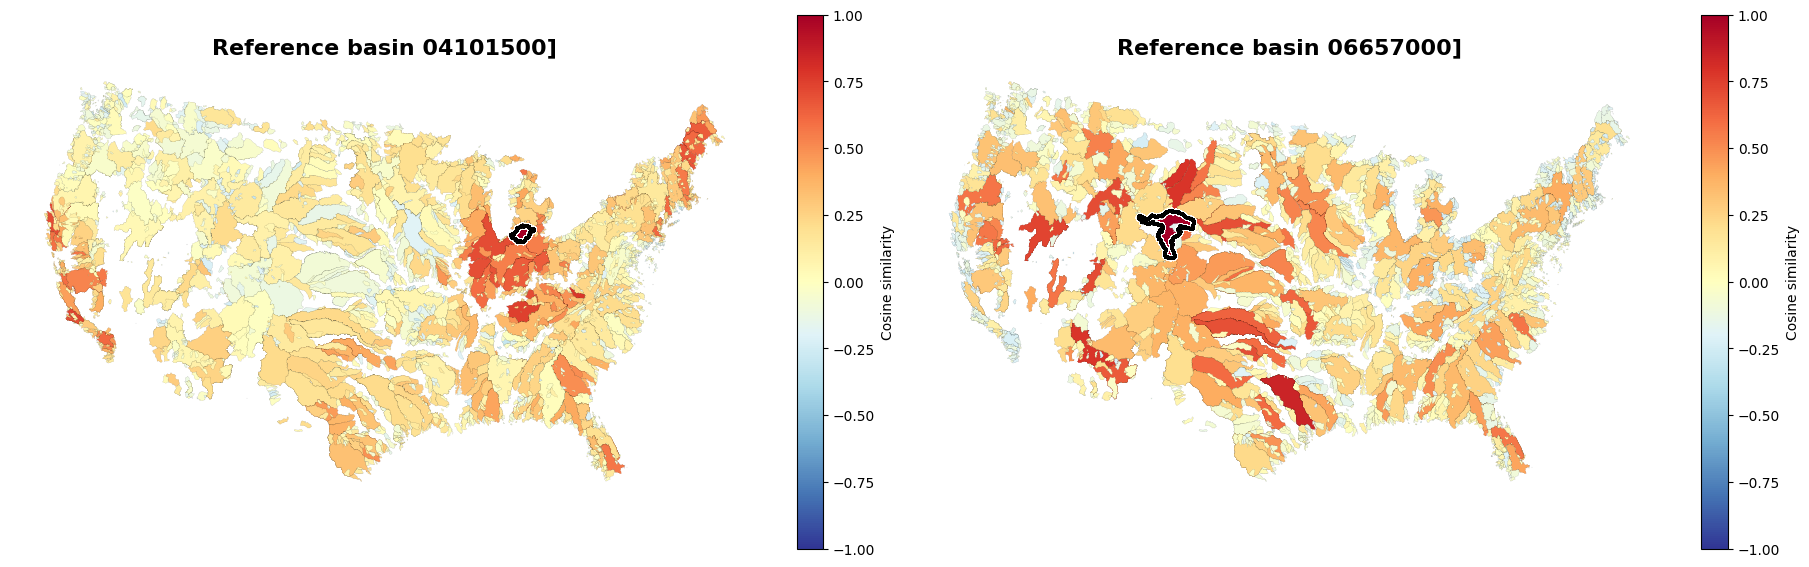


Saved figure PNG: figures_basin2vec_cosine_similarity/basin2vec_reference_cosine_similarity_selected_basins.png
Saved figure PDF: figures_basin2vec_cosine_similarity/basin2vec_reference_cosine_similarity_selected_basins.pdf
04101500 | min=-0.340, median=0.027, max=1.000
06657000 | min=-0.356, median=-0.062, max=1.000


In [ ]:
# ============================================================
# Basin2Vec cosine-similarity maps from selected reference basins
# Boundary-highlight version
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")


# ============================================================
# 1. Paths and options
# ============================================================

BASIN_FILE = Path("/data/basin2vec/raw/gages-ii/geopackage/gages_basins.gpkg")
BASIN_LAYER = "gages_basins"

BASIN2VEC_NPZ = Path(
    "../src/evaluation_outputs/HCLV4_grouped_monthly_static_meta_areaaux_64d/basin_embeddings_full.npz"
)

EMBEDDING_KEY = "avg_embeddings"
LABEL_KEY = "avg_labels"

OUT_DIR = Path("./figures_basin2vec_cosine_similarity")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_FIG_PNG = OUT_DIR / "basin2vec_reference_cosine_similarity_selected_basins.png"
OUT_FIG_PDF = OUT_DIR / "basin2vec_reference_cosine_similarity_selected_basins.pdf"
OUT_TABLE_CSV = OUT_DIR / "basin2vec_reference_top_similar_selected_basins.csv"

ID_ZFILL = 8
MAP_CRS = "EPSG:5070"
WGS84 = "EPSG:4326"

FIG_DPI = 400
EDGE_COLOR = "black"
LINE_WIDTH = 0.03
SIMPLIFY_TOLERANCE = 0

TOPK = 15


# ============================================================
# 2. Selected reference basins
# ============================================================

REFERENCE_SPECS = [
    {"name": "Reference basin 04101500", "gage_id": "04101500"},
    # {"name": "Reference basin 02481510", "gage_id": "02481510"},
    # {"name": "Reference basin 11152500", "gage_id": "11152500"},
    {"name": "Reference basin 06657000", "gage_id": "06657000"},
]


# ============================================================
# 3. Helper functions
# ============================================================

def normalize_basin_id(x, zfill=8):
    if x is None or pd.isna(x):
        return None

    if isinstance(x, bytes):
        x = x.decode("utf-8")

    if isinstance(x, (float, np.floating)):
        if np.isfinite(x) and float(x).is_integer():
            s = str(int(x))
        else:
            s = str(x)
    elif isinstance(x, (int, np.integer)):
        s = str(int(x))
    else:
        s = str(x).strip()

    s = s.replace("'", "").replace('"', "").strip()

    if s.endswith(".0") and s[:-2].isdigit():
        s = s[:-2]

    for sep in ["_", "-", "|", "/", " "]:
        if sep in s:
            first = s.split(sep)[0]
            if first.isdigit():
                s = first
                break

    if zfill is not None and zfill > 0 and s.isdigit():
        s = s.zfill(zfill)

    return s


def find_first_existing_column(gdf, candidate_cols):
    col_map = {c.lower(): c for c in gdf.columns}
    for c in candidate_cols:
        if c in gdf.columns:
            return c
        if c.lower() in col_map:
            return col_map[c.lower()]
    return None


def clean_and_l2_normalize(X):
    """
    Clean NaN/inf and L2-normalize embeddings for cosine similarity.
    """
    X = np.array(X, dtype=np.float32, copy=True)

    X[~np.isfinite(X)] = np.nan

    col_median = np.nanmedian(X, axis=0)
    col_median[~np.isfinite(col_median)] = 0.0

    bad_rows, bad_cols = np.where(np.isnan(X))
    if len(bad_rows) > 0:
        X[bad_rows, bad_cols] = col_median[bad_cols]

    X = normalize(X, norm="l2", axis=1)

    return np.array(X, dtype=np.float32, copy=True)


def resolve_reference_basin_by_id(spec, gdf):
    target_id = normalize_basin_id(spec["gage_id"], zfill=ID_ZFILL)
    matches = np.where(gdf["basin_id_str"].values == target_id)[0]

    if len(matches) == 0:
        raise ValueError(
            f"Reference basin {target_id} was not found in the matched basin set."
        )

    return int(matches[0])


def make_similarity_table(gdf_wgs84, sim_vec, ref_pos, gdf_id_col, topk=15):
    """
    Make top-k most similar basin table, excluding the reference basin.
    """
    temp = gdf_wgs84[[gdf_id_col, "basin_id_str", "geometry"]].copy()
    temp["cosine_similarity"] = sim_vec

    ref_id = gdf_wgs84.iloc[ref_pos]["basin_id_str"]

    temp["centroid_lon"] = temp.geometry.centroid.x
    temp["centroid_lat"] = temp.geometry.centroid.y

    temp = temp[temp["basin_id_str"] != ref_id].copy()
    temp = temp.sort_values("cosine_similarity", ascending=False).head(topk)

    return temp.reset_index(drop=True)


# ============================================================
# 4. Load Basin2Vec embeddings
# ============================================================

npz = np.load(BASIN2VEC_NPZ, allow_pickle=True)

print("NPZ keys:")
for k in npz.files:
    arr = npz[k]
    print(f"  {k}: shape={getattr(arr, 'shape', None)}, dtype={getattr(arr, 'dtype', None)}")

if EMBEDDING_KEY not in npz.files:
    raise KeyError(f"'{EMBEDDING_KEY}' not found. Available keys: {npz.files}")

if LABEL_KEY not in npz.files:
    raise KeyError(f"'{LABEL_KEY}' not found. Available keys: {npz.files}")

E_basin = np.array(npz[EMBEDDING_KEY], dtype=np.float32, copy=True)
labels_raw = np.array(npz[LABEL_KEY], copy=True)

if E_basin.ndim != 2:
    raise ValueError(f"Expected {EMBEDDING_KEY} to be [N, D]. Got {E_basin.shape}")

if E_basin.shape[0] != len(labels_raw):
    raise ValueError(
        f"Embedding rows {E_basin.shape[0]} do not match label count {len(labels_raw)}"
    )

basin_ids = np.array([normalize_basin_id(x, zfill=ID_ZFILL) for x in labels_raw])

print("\nEmbedding shape:", E_basin.shape)
print("Example normalized basin IDs:", basin_ids[:10])


# ============================================================
# 5. Build embedding table
# ============================================================

emb_df = pd.DataFrame(E_basin, columns=[f"e_{i}" for i in range(E_basin.shape[1])])
emb_df.insert(0, "basin_id_str", basin_ids)
emb_df = emb_df.dropna(subset=["basin_id_str"]).copy()

if emb_df["basin_id_str"].duplicated().any():
    print("Repeated basin IDs detected. Averaging by basin_id_str.")
    emb_df = emb_df.groupby("basin_id_str", as_index=False).mean(numeric_only=True)

print("\nFinal embedding table shape:", emb_df.shape)


# ============================================================
# 6. Load basin polygons
# ============================================================

basins = gpd.read_file(BASIN_FILE, layer=BASIN_LAYER)

print("\nBasin CRS:", basins.crs)
print("Columns:", list(basins.columns))

GDF_ID_CANDIDATES = [
    "GAGE_ID",
    "gage_id",
    "STAID",
    "staid",
    "site_no",
    "SITE_NO",
    "SOURCE_FEA",
    "source_fea",
    "basin_id",
    "BASIN_ID",
    "gauge_id",
    "station_id",
    "ID",
    "id",
]

gdf_id_col = find_first_existing_column(basins, GDF_ID_CANDIDATES)

if gdf_id_col is None:
    raise KeyError("Could not automatically find basin ID column in GeoPackage.")

print("Using GeoPackage basin ID column:", gdf_id_col)

basins = basins[basins.geometry.notna() & (~basins.geometry.is_empty)].copy()
basins["basin_id_str"] = basins[gdf_id_col].apply(
    lambda x: normalize_basin_id(x, zfill=ID_ZFILL)
)


# ============================================================
# 7. Match embeddings with polygons
# ============================================================

gdf = basins.merge(emb_df, on="basin_id_str", how="inner").reset_index(drop=True)

print("\nMatched basins:", len(gdf))
print("GeoPackage basins:", len(basins))
print("Embedding basins:", len(emb_df))

if len(gdf) == 0:
    raise ValueError("No basins matched between embeddings and polygons.")

available_ids = set(gdf["basin_id_str"].values)
requested_ids = [normalize_basin_id(x["gage_id"], zfill=ID_ZFILL) for x in REFERENCE_SPECS]
missing_requested = [x for x in requested_ids if x not in available_ids]

if missing_requested:
    raise ValueError(
        f"The following requested reference basins were not found after matching: "
        f"{missing_requested}"
    )

gdf_wgs84 = gdf.to_crs(WGS84).copy().reset_index(drop=True)
gdf_map = gdf.to_crs(MAP_CRS).copy().reset_index(drop=True)

if SIMPLIFY_TOLERANCE > 0:
    gdf_map["geometry"] = gdf_map.geometry.simplify(
        SIMPLIFY_TOLERANCE,
        preserve_topology=True,
    )

print("Projected CRS for plotting:", gdf_map.crs)


# ============================================================
# 8. Prepare embedding matrix
# ============================================================

emb_cols = [c for c in gdf.columns if c.startswith("e_")]
X = gdf[emb_cols].to_numpy(dtype=np.float32, copy=True)
X = clean_and_l2_normalize(X)

print("\nEmbedding matrix used for cosine similarity:", X.shape)


# ============================================================
# 9. Resolve selected reference basins
# ============================================================

resolved_refs = []

for spec in REFERENCE_SPECS:
    ref_pos = resolve_reference_basin_by_id(spec, gdf)

    ref_row_wgs84 = gdf_wgs84.iloc[ref_pos]
    ref_centroid = ref_row_wgs84.geometry.centroid

    resolved_refs.append(
        {
            "name": spec["name"],
            "ref_pos": ref_pos,
            "gage_id": ref_row_wgs84["basin_id_str"],
            "centroid_lon": float(ref_centroid.x),
            "centroid_lat": float(ref_centroid.y),
        }
    )

resolved_refs_df = pd.DataFrame(resolved_refs)

print("\nResolved reference basins:")
display(resolved_refs_df)


# ============================================================
# 10. Compute cosine similarity and save top-k similar basins
# ============================================================

all_topk_tables = []

for ref in resolved_refs:
    ref_pos = ref["ref_pos"]
    ref_vec = X[ref_pos:ref_pos + 1]

    sim_vec = cosine_similarity(ref_vec, X).ravel()
    ref["similarity_vector"] = sim_vec

    topk_df = make_similarity_table(
        gdf_wgs84=gdf_wgs84,
        sim_vec=sim_vec,
        ref_pos=ref_pos,
        gdf_id_col=gdf_id_col,
        topk=TOPK,
    )

    topk_df.insert(0, "reference_name", ref["name"])
    topk_df.insert(1, "reference_gage_id", ref["gage_id"])

    all_topk_tables.append(topk_df)

topk_all = pd.concat(all_topk_tables, ignore_index=True)
topk_all.to_csv(OUT_TABLE_CSV, index=False)

print(f"\nSaved top-k similar basins table: {OUT_TABLE_CSV}")
display(topk_all.head(30))


# ============================================================
# 11. Plot cosine-similarity maps
# ============================================================

n_refs = len(resolved_refs)
ncols = 2
nrows = int(np.ceil(n_refs / ncols))

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(18, 7.5 * nrows),
    constrained_layout=True,
)

axes = np.array(axes).reshape(-1)

for ax, ref in zip(axes, resolved_refs):
    sim_vec = ref["similarity_vector"]

    plot_gdf = gdf_map.copy()
    plot_gdf["cosine_similarity"] = sim_vec

    plot_gdf.plot(
        column="cosine_similarity",
        ax=ax,
        cmap="RdYlBu_r",
        vmin=-1,
        vmax=1,
        linewidth=LINE_WIDTH,
        edgecolor=EDGE_COLOR,
        legend=True,
        legend_kwds={
            "shrink": 0.72,
            "label": "Cosine similarity",
        },
    )

    # Highlight selected reference basin boundary instead of using a star.
    ref_boundary = gdf_map.iloc[[ref["ref_pos"]]]

    # Wide white outline underneath for contrast
    ref_boundary.boundary.plot(
        ax=ax,
        color="white",
        linewidth=4.0,
        zorder=6,
    )

    # Dark outline on top
    ref_boundary.boundary.plot(
        ax=ax,
        color="black",
        linewidth=2.2,
        zorder=7,
    )

    ax.set_title(
        f"{ref['name']}",
        fontsize=16,
        fontweight="bold",
    )

    ax.set_axis_off()
    ax.set_aspect("equal")

for j in range(len(resolved_refs), len(axes)):
    axes[j].axis("off")

# fig.suptitle(
#     "Basin2Vec cosine-similarity maps from selected reference basins",
#     fontsize=22,
#     fontweight="bold",
# )

plt.savefig(OUT_FIG_PNG, dpi=FIG_DPI, bbox_inches="tight")
plt.savefig(OUT_FIG_PDF, bbox_inches="tight")
plt.show()

print(f"\nSaved figure PNG: {OUT_FIG_PNG}")
print(f"Saved figure PDF: {OUT_FIG_PDF}")


# ============================================================
# 12. Optional: print similarity range per reference basin
# ============================================================

for ref in resolved_refs:
    sim_vec = ref["similarity_vector"]
    print(
        f"{ref['gage_id']} | "
        f"min={sim_vec.min():.3f}, "
        f"median={np.median(sim_vec):.3f}, "
        f"max={sim_vec.max():.3f}"
    )

In [7]:
# ============================================================
# Basin2Vec Top-k Hydrologic-Neighbor Diagnostics
# CAMELS-only version
#
# This version only uses basins that are available in CAMELS
# and have complete CAMELS hydrologic attributes.
# ============================================================

from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd

from sklearn.preprocessing import normalize
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")


# ============================================================
# 1. Paths and options
# ============================================================

BASIN_FILE = Path("/data/basin2vec/raw/gages-ii/geopackage/gages_basins.gpkg")
BASIN_LAYER = "gages_basins"

BASIN2VEC_NPZ = Path(
    "../src/evaluation_outputs/HCLV4_grouped_monthly_static_meta_areaaux_64d/basin_embeddings_full.npz"
)

CAMELS_ROOT = Path("/data/camels_us")
DAYMET_DIR = CAMELS_ROOT / "basin_mean_forcing" / "daymet"
STREAMFLOW_DIR = CAMELS_ROOT / "usgs_streamflow"
ATTR_DIR = CAMELS_ROOT / "camels_attributes_v2.0"

OUT_DIR = Path("./figures_basin2vec_cosine_similarity")
OUT_DIR.mkdir(parents=True, exist_ok=True)

OUT_DIAGNOSTICS_CSV = OUT_DIR / "basin2vec_topk_camels_only_hydrologic_neighbor_diagnostics.csv"
OUT_SUMMARY_CSV = OUT_DIR / "basin2vec_topk_camels_only_hydrologic_neighbor_summary.csv"

EMBEDDING_KEY = "avg_embeddings"
LABEL_KEY = "avg_labels"

ID_ZFILL = 8
MAP_CRS = "EPSG:5070"
WGS84 = "EPSG:4326"

REFERENCE_BASINS = [
    "04101500",
    "02481510",
    "11152500",
    "06657000",
]

TOPK = 10
MIN_DISTANCE_KM = 250.0

# True = use only CAMELS basins with all required attributes available.
# False = use any basin that appears in CAMELS attributes, even if some fields are missing.
STRICT_COMPLETE_CAMELS_ATTRS = True


# ============================================================
# 2. Helper functions
# ============================================================

def normalize_basin_id(x, zfill=8):
    if x is None or pd.isna(x):
        return None

    if isinstance(x, bytes):
        x = x.decode("utf-8")

    if isinstance(x, (float, np.floating)):
        if np.isfinite(x) and float(x).is_integer():
            s = str(int(x))
        else:
            s = str(x)
    elif isinstance(x, (int, np.integer)):
        s = str(int(x))
    else:
        s = str(x).strip()

    s = s.replace("'", "").replace('"', "").strip()

    if s.endswith(".0") and s[:-2].isdigit():
        s = s[:-2]

    for sep in ["_", "-", "|", "/", " "]:
        if sep in s:
            first = s.split(sep)[0]
            if first.isdigit():
                s = first
                break

    if zfill is not None and zfill > 0 and s.isdigit():
        s = s.zfill(zfill)

    return s


def find_first_existing_column(df, candidates):
    lower_map = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c in df.columns:
            return c
        if c.lower() in lower_map:
            return lower_map[c.lower()]
    return None


def read_camels_attr_file(path):
    path = Path(path)
    best_df = None
    best_cols = 0

    for sep in [";", "\t", ","]:
        try:
            df = pd.read_csv(path, sep=sep, low_memory=False)
            if df.shape[1] > best_cols:
                best_df = df
                best_cols = df.shape[1]
        except Exception:
            pass

    return best_df


def load_camels_attributes(attr_dir):
    attr_dir = Path(attr_dir)

    if not attr_dir.exists():
        raise FileNotFoundError(f"ATTR_DIR does not exist: {attr_dir}")

    files = sorted(list(attr_dir.glob("*.txt")) + list(attr_dir.glob("*.csv")))

    if len(files) == 0:
        raise FileNotFoundError(f"No .txt or .csv files found in {attr_dir}")

    print("CAMELS attribute files:")
    for f in files:
        print(" ", f.name)

    merged = None
    loaded = []

    id_candidates = [
        "gauge_id", "GAGE_ID", "gage_id", "STAID", "site_no", "basin_id", "id"
    ]

    for f in files:
        df = read_camels_attr_file(f)

        if df is None or df.empty:
            print(f"[WARN] Could not read: {f}")
            continue

        df = df.loc[:, ~df.columns.duplicated()].copy()

        id_col = find_first_existing_column(df, id_candidates)
        if id_col is None:
            print(f"[WARN] No gauge_id-like column found in {f.name}")
            continue

        df["basin_id_str"] = df[id_col].apply(lambda x: normalize_basin_id(x, zfill=ID_ZFILL))
        df = df.dropna(subset=["basin_id_str"]).copy()
        df = df.groupby("basin_id_str", as_index=False).first()

        if merged is not None:
            rename = {}
            for c in df.columns:
                if c == "basin_id_str":
                    continue
                if c in merged.columns:
                    rename[c] = f"{f.stem}__{c}"
            df = df.rename(columns=rename)

        merged = df if merged is None else merged.merge(df, on="basin_id_str", how="outer")
        loaded.append(f)

    if merged is None or merged.empty:
        raise ValueError("Could not load any usable CAMELS attribute files.")

    print(f"\nLoaded CAMELS attribute table: {merged.shape}")
    return merged, loaded


def clean_and_l2_normalize(X):
    X = np.array(X, dtype=np.float32, copy=True)
    X[~np.isfinite(X)] = np.nan

    col_median = np.nanmedian(X, axis=0)
    col_median[~np.isfinite(col_median)] = 0.0

    bad_rows, bad_cols = np.where(np.isnan(X))
    if len(bad_rows) > 0:
        X[bad_rows, bad_cols] = col_median[bad_cols]

    X = normalize(X, norm="l2", axis=1)
    return np.array(X, dtype=np.float32, copy=True)


def get_col(df, possible_names):
    for name in possible_names:
        if name in df.columns:
            return name

    lower = {c.lower(): c for c in df.columns}
    for name in possible_names:
        if name.lower() in lower:
            return lower[name.lower()]

    return None


def make_huc_label(x):
    if pd.isna(x):
        return np.nan
    try:
        return f"HUC_{int(float(x)):02d}"
    except Exception:
        return f"HUC_{str(x)}"


# ============================================================
# 3. Load Basin2Vec basin-level embeddings
# ============================================================

npz = np.load(BASIN2VEC_NPZ, allow_pickle=True)

print("NPZ keys:")
for k in npz.files:
    arr = npz[k]
    print(f"  {k}: shape={getattr(arr, 'shape', None)}, dtype={getattr(arr, 'dtype', None)}")

E = np.array(npz[EMBEDDING_KEY], dtype=np.float32, copy=True)
labels_raw = np.array(npz[LABEL_KEY], copy=True)

basin_ids = np.array([normalize_basin_id(x, zfill=ID_ZFILL) for x in labels_raw])

emb_df = pd.DataFrame(E, columns=[f"e_{i}" for i in range(E.shape[1])])
emb_df.insert(0, "basin_id_str", basin_ids)
emb_df = emb_df.dropna(subset=["basin_id_str"]).copy()

if emb_df["basin_id_str"].duplicated().any():
    emb_df = emb_df.groupby("basin_id_str", as_index=False).mean(numeric_only=True)

print("\nBasin2Vec embedding table:", emb_df.shape)


# ============================================================
# 4. Load CAMELS attributes first
# ============================================================

camels_attr, loaded_camels_files = load_camels_attributes(ATTR_DIR)

COLS = {
    "aridity": get_col(camels_attr, ["aridity"]),
    "snow_fraction": get_col(camels_attr, ["frac_snow", "snow_fraction", "snow_frac"]),
    "baseflow_index": get_col(camels_attr, ["baseflow_index", "bfi"]),
    "drainage_area_km2": get_col(camels_attr, ["area_gages2", "area_geospa_fabric", "area_km2"]),
    "runoff_ratio": get_col(camels_attr, ["runoff_ratio"]),
    "ecoregion": get_col(camels_attr, ["ecoregion", "eco_region", "ecoregion_code"]),
    "huc02": get_col(camels_attr, ["huc_02", "huc02", "HUC_02", "HUC02"]),
}

print("\nDetected CAMELS columns:")
for k, v in COLS.items():
    print(f"  {k}: {v}")

selected_attrs = camels_attr[["basin_id_str"]].copy()

selected_attrs["aridity"] = (
    pd.to_numeric(camels_attr[COLS["aridity"]], errors="coerce")
    if COLS["aridity"] else np.nan
)

selected_attrs["snow_fraction"] = (
    pd.to_numeric(camels_attr[COLS["snow_fraction"]], errors="coerce")
    if COLS["snow_fraction"] else np.nan
)

selected_attrs["baseflow_index"] = (
    pd.to_numeric(camels_attr[COLS["baseflow_index"]], errors="coerce")
    if COLS["baseflow_index"] else np.nan
)

selected_attrs["drainage_area_km2"] = (
    pd.to_numeric(camels_attr[COLS["drainage_area_km2"]], errors="coerce")
    if COLS["drainage_area_km2"] else np.nan
)

selected_attrs["runoff_ratio"] = (
    pd.to_numeric(camels_attr[COLS["runoff_ratio"]], errors="coerce")
    if COLS["runoff_ratio"] else np.nan
)

if COLS["ecoregion"]:
    selected_attrs["ecoregion"] = camels_attr[COLS["ecoregion"]].astype(str)
elif COLS["huc02"]:
    selected_attrs["ecoregion"] = camels_attr[COLS["huc02"]].apply(make_huc_label)
else:
    selected_attrs["ecoregion"] = np.nan

selected_attrs = selected_attrs.groupby("basin_id_str", as_index=False).first()

required_attr_cols = [
    "aridity",
    "snow_fraction",
    "baseflow_index",
    "drainage_area_km2",
    "runoff_ratio",
]

selected_attrs["has_complete_camels_attrs"] = selected_attrs[required_attr_cols].notna().all(axis=1)

if STRICT_COMPLETE_CAMELS_ATTRS:
    camels_use_ids = set(
        selected_attrs.loc[selected_attrs["has_complete_camels_attrs"], "basin_id_str"]
    )
else:
    camels_use_ids = set(selected_attrs["basin_id_str"])

print("\nCAMELS selected attributes non-null counts:")
display(selected_attrs.notna().sum())

print(f"\nCAMELS basins available for use: {len(camels_use_ids)}")


# ============================================================
# 5. Load basin polygons and match with embeddings
# ============================================================

basins = gpd.read_file(BASIN_FILE, layer=BASIN_LAYER)

gdf_id_col = find_first_existing_column(
    basins,
    [
        "GAGE_ID", "gage_id", "STAID", "staid", "site_no", "SITE_NO",
        "SOURCE_FEA", "source_fea", "basin_id", "BASIN_ID", "ID", "id"
    ],
)

if gdf_id_col is None:
    raise KeyError("Could not find basin ID column in basin GeoPackage.")

print("\nUsing basin ID column:", gdf_id_col)

basins = basins[basins.geometry.notna() & (~basins.geometry.is_empty)].copy()
basins["basin_id_str"] = basins[gdf_id_col].apply(
    lambda x: normalize_basin_id(x, zfill=ID_ZFILL)
)

# Match GAGES-II polygons with Basin2Vec embeddings.
gdf_all = basins.merge(emb_df, on="basin_id_str", how="inner").reset_index(drop=True)

print("\nMatched GAGES-II + Basin2Vec basins:", len(gdf_all))

# ============================================================
# 6. CAMELS-only filtering happens here
# ============================================================

gdf_camels = gdf_all[gdf_all["basin_id_str"].isin(camels_use_ids)].copy().reset_index(drop=True)

# Merge CAMELS attributes after filtering.
gdf_camels = gdf_camels.merge(
    selected_attrs,
    on="basin_id_str",
    how="left"
).reset_index(drop=True)

if STRICT_COMPLETE_CAMELS_ATTRS:
    gdf_camels = gdf_camels[gdf_camels["has_complete_camels_attrs"]].copy().reset_index(drop=True)

print("Final CAMELS-only Basin2Vec basins used:", len(gdf_camels))

if len(gdf_camels) == 0:
    raise ValueError("No CAMELS basins matched with Basin2Vec embeddings and polygons.")

display(gdf_camels[[gdf_id_col, "basin_id_str"] + required_attr_cols].head())


# ============================================================
# 7. Check reference basins after CAMELS-only filtering
# ============================================================

requested_ids = [normalize_basin_id(x, zfill=ID_ZFILL) for x in REFERENCE_BASINS]
available_camels_ids = set(gdf_camels["basin_id_str"])

missing_refs = [x for x in requested_ids if x not in available_camels_ids]

if missing_refs:
    print("\n[WARN] These reference basins are not available in the CAMELS-only filtered set:")
    print(missing_refs)
    print("They will be skipped.")

reference_ids_to_use = [x for x in requested_ids if x in available_camels_ids]

if len(reference_ids_to_use) == 0:
    raise ValueError("None of the requested reference basins are available in CAMELS after filtering.")

print("\nReference basins used:")
print(reference_ids_to_use)


# ============================================================
# 8. Project and prepare aligned matrix
# ============================================================

gdf_map = gdf_camels.to_crs(MAP_CRS).copy().reset_index(drop=True)
gdf_wgs84 = gdf_camels.to_crs(WGS84).copy().reset_index(drop=True)

gdf_map["centroid_x"] = gdf_map.geometry.centroid.x
gdf_map["centroid_y"] = gdf_map.geometry.centroid.y
gdf_map["centroid_lon"] = gdf_wgs84.geometry.centroid.x.values
gdf_map["centroid_lat"] = gdf_wgs84.geometry.centroid.y.values

emb_cols = [c for c in gdf_map.columns if c.startswith("e_")]

X = gdf_map[emb_cols].to_numpy(dtype=np.float32, copy=True)
X = clean_and_l2_normalize(X)

coords = gdf_map[["centroid_x", "centroid_y"]].to_numpy(dtype=np.float64)

print("\nEmbedding matrix after CAMELS-only filtering:", X.shape)


# ============================================================
# 9. Compute top-k distant CAMELS-only neighbors
# ============================================================

numeric_attrs = [
    "aridity",
    "snow_fraction",
    "baseflow_index",
    "drainage_area_km2",
    "runoff_ratio",
]

attr_std = {}

for c in numeric_attrs:
    std = gdf_map[c].std(skipna=True)
    attr_std[c] = std if pd.notna(std) and std > 0 else np.nan

records = []

for ref_id in reference_ids_to_use:
    ref_positions = np.where(gdf_map["basin_id_str"].values == ref_id)[0]

    if len(ref_positions) == 0:
        print(f"[WARN] Reference basin not found after CAMELS filter: {ref_id}")
        continue

    ref_pos = int(ref_positions[0])
    ref_row = gdf_map.iloc[ref_pos]

    sim_vec = cosine_similarity(X[ref_pos:ref_pos + 1], X).ravel()

    ref_xy = coords[ref_pos]
    distance_km = np.sqrt(((coords - ref_xy) ** 2).sum(axis=1)) / 1000.0

    candidate_df = pd.DataFrame({
        "candidate_pos": np.arange(len(gdf_map)),
        "neighbor_gage_id": gdf_map["basin_id_str"].values,
        "cosine_similarity": sim_vec,
        "distance_km": distance_km,
    })

    candidate_df = candidate_df[
        (candidate_df["candidate_pos"] != ref_pos)
        & (candidate_df["distance_km"] >= MIN_DISTANCE_KM)
    ].copy()

    if len(candidate_df) < TOPK:
        print(
            f"[WARN] {ref_id}: only {len(candidate_df)} CAMELS basins "
            f"beyond {MIN_DISTANCE_KM} km."
        )

    candidate_df = candidate_df.sort_values("cosine_similarity", ascending=False).head(TOPK)

    for rank, row in enumerate(candidate_df.itertuples(index=False), start=1):
        cand_pos = int(row.candidate_pos)
        cand_row = gdf_map.iloc[cand_pos]

        rec = {
            "reference_gage_id": ref_id,
            "neighbor_rank": rank,
            "neighbor_gage_id": cand_row["basin_id_str"],
            "cosine_similarity": float(row.cosine_similarity),
            "distance_km": float(row.distance_km),
            "reference_lon": float(ref_row["centroid_lon"]),
            "reference_lat": float(ref_row["centroid_lat"]),
            "neighbor_lon": float(cand_row["centroid_lon"]),
            "neighbor_lat": float(cand_row["centroid_lat"]),
        }

        for attr in numeric_attrs:
            ref_val = ref_row[attr]
            cand_val = cand_row[attr]

            rec[f"ref_{attr}"] = ref_val
            rec[f"neighbor_{attr}"] = cand_val

            if pd.notna(ref_val) and pd.notna(cand_val):
                abs_diff = abs(float(cand_val) - float(ref_val))
                rec[f"absdiff_{attr}"] = abs_diff

                if pd.notna(attr_std[attr]) and attr_std[attr] > 0:
                    rec[f"stddiff_{attr}"] = abs_diff / attr_std[attr]
                else:
                    rec[f"stddiff_{attr}"] = np.nan
            else:
                rec[f"absdiff_{attr}"] = np.nan
                rec[f"stddiff_{attr}"] = np.nan

        ref_area = rec.get("ref_drainage_area_km2", np.nan)
        cand_area = rec.get("neighbor_drainage_area_km2", np.nan)

        if pd.notna(ref_area) and pd.notna(cand_area) and float(ref_area) > 0:
            rec["area_ratio_neighbor_over_ref"] = float(cand_area) / float(ref_area)
        else:
            rec["area_ratio_neighbor_over_ref"] = np.nan

        rec["ref_ecoregion"] = ref_row["ecoregion"]
        rec["neighbor_ecoregion"] = cand_row["ecoregion"]

        if pd.notna(ref_row["ecoregion"]) and pd.notna(cand_row["ecoregion"]):
            rec["same_ecoregion"] = str(ref_row["ecoregion"]) == str(cand_row["ecoregion"])
        else:
            rec["same_ecoregion"] = np.nan

        records.append(rec)

topk_diag = pd.DataFrame(records)

if topk_diag.empty:
    raise ValueError("No top-k neighbors were found. Try lowering MIN_DISTANCE_KM.")

topk_diag.to_csv(OUT_DIAGNOSTICS_CSV, index=False)

print(f"\nSaved diagnostics table: {OUT_DIAGNOSTICS_CSV}")


# ============================================================
# 10. Display compact diagnostics table
# ============================================================

compact_cols = [
    "reference_gage_id",
    "neighbor_rank",
    "neighbor_gage_id",
    "cosine_similarity",
    "distance_km",
    "ref_aridity",
    "neighbor_aridity",
    "absdiff_aridity",
    "ref_snow_fraction",
    "neighbor_snow_fraction",
    "absdiff_snow_fraction",
    "ref_baseflow_index",
    "neighbor_baseflow_index",
    "absdiff_baseflow_index",
    "ref_drainage_area_km2",
    "neighbor_drainage_area_km2",
    "area_ratio_neighbor_over_ref",
    "ref_runoff_ratio",
    "neighbor_runoff_ratio",
    "absdiff_runoff_ratio",
    "ref_ecoregion",
    "neighbor_ecoregion",
    "same_ecoregion",
]

display(
    topk_diag[compact_cols]
    .style
    .format({
        "cosine_similarity": "{:.3f}",
        "distance_km": "{:.1f}",
        "ref_aridity": "{:.3f}",
        "neighbor_aridity": "{:.3f}",
        "absdiff_aridity": "{:.3f}",
        "ref_snow_fraction": "{:.3f}",
        "neighbor_snow_fraction": "{:.3f}",
        "absdiff_snow_fraction": "{:.3f}",
        "ref_baseflow_index": "{:.3f}",
        "neighbor_baseflow_index": "{:.3f}",
        "absdiff_baseflow_index": "{:.3f}",
        "ref_drainage_area_km2": "{:.1f}",
        "neighbor_drainage_area_km2": "{:.1f}",
        "area_ratio_neighbor_over_ref": "{:.2f}",
        "ref_runoff_ratio": "{:.3f}",
        "neighbor_runoff_ratio": "{:.3f}",
        "absdiff_runoff_ratio": "{:.3f}",
    })
)


# ============================================================
# 11. Reference-level summary
# ============================================================

summary_rows = []

for ref_id, group in topk_diag.groupby("reference_gage_id"):
    row = {
        "reference_gage_id": ref_id,
        "n_neighbors": len(group),
        "mean_cosine_similarity": group["cosine_similarity"].mean(),
        "mean_distance_km": group["distance_km"].mean(),
        "median_distance_km": group["distance_km"].median(),
        "same_ecoregion_fraction": group["same_ecoregion"].mean(),
    }

    for attr in numeric_attrs:
        row[f"mean_absdiff_{attr}"] = group[f"absdiff_{attr}"].mean()
        row[f"mean_stddiff_{attr}"] = group[f"stddiff_{attr}"].mean()

    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(OUT_SUMMARY_CSV, index=False)

print(f"\nSaved summary table: {OUT_SUMMARY_CSV}")

display(
    summary_df.style.format({
        "mean_cosine_similarity": "{:.3f}",
        "mean_distance_km": "{:.1f}",
        "median_distance_km": "{:.1f}",
        "same_ecoregion_fraction": "{:.2f}",
        "mean_absdiff_aridity": "{:.3f}",
        "mean_absdiff_snow_fraction": "{:.3f}",
        "mean_absdiff_baseflow_index": "{:.3f}",
        "mean_absdiff_drainage_area_km2": "{:.1f}",
        "mean_absdiff_runoff_ratio": "{:.3f}",
        "mean_stddiff_aridity": "{:.2f}",
        "mean_stddiff_snow_fraction": "{:.2f}",
        "mean_stddiff_baseflow_index": "{:.2f}",
        "mean_stddiff_drainage_area_km2": "{:.2f}",
        "mean_stddiff_runoff_ratio": "{:.2f}",
    })
)

NPZ keys:
  embeddings: shape=(362680, 64), dtype=float32
  hydrologic_repr: shape=(362680, 64), dtype=float32
  z_multisource: shape=(362680, 64), dtype=float32
  z_monthly: shape=(362680, 64), dtype=float32
  z_static: shape=(362680, 64), dtype=float32
  labels: shape=(362680,), dtype=<U15
  label_ints: shape=(362680,), dtype=int64
  years: shape=(362680,), dtype=int64
  basin_meta: shape=(362680, 11), dtype=float32
  area_target: shape=(362680,), dtype=float32
  area_pred: shape=(362680,), dtype=float32
  overlap_degree: shape=(362680,), dtype=float32
  branch_attention: shape=(362680, 2), dtype=float32
  avg_embeddings: shape=(9067, 64), dtype=float32
  avg_labels: shape=(9067,), dtype=<U15
  year_counts: shape=(9067,), dtype=int64

Basin2Vec embedding table: (9067, 65)
CAMELS attribute files:
  camels_clim.txt
  camels_geol.txt
  camels_hydro.txt
  camels_name.txt
  camels_soil.txt
  camels_topo.txt
  camels_vege.txt

Loaded CAMELS attribute table: (671, 67)

Detected CAMELS colum

basin_id_str                 671
aridity                      671
snow_fraction                671
baseflow_index               671
drainage_area_km2            671
runoff_ratio                 670
ecoregion                    671
has_complete_camels_attrs    671
dtype: int64


CAMELS basins available for use: 670

Using basin ID column: GAGE_ID

Matched GAGES-II + Basin2Vec basins: 9067
Final CAMELS-only Basin2Vec basins used: 670


,GAGE_ID,basin_id_str,aridity,snow_fraction,baseflow_index,drainage_area_km2,runoff_ratio
0,01013500,01013500,0.630559,0.313440,0.585226,2252.70,0.543437
1,01022500,01022500,0.587356,0.245259,0.554478,573.60,0.602269
2,01030500,01030500,0.624111,0.277018,0.508441,3676.17,0.555859
3,01052500,01052500,0.561914,0.352698,0.459700,383.82,0.644652
4,01054200,01054200,0.523306,0.299642,0.437050,180.98,0.671663



[WARN] These reference basins are not available in the CAMELS-only filtered set:
['04101500', '11152500', '06657000']
They will be skipped.

Reference basins used:
['02481510']

Embedding matrix after CAMELS-only filtering: (670, 64)

Saved diagnostics table: figures_basin2vec_cosine_similarity/basin2vec_topk_camels_only_hydrologic_neighbor_diagnostics.csv


,reference_gage_id,neighbor_rank,neighbor_gage_id,cosine_similarity,distance_km,ref_aridity,neighbor_aridity,absdiff_aridity,ref_snow_fraction,neighbor_snow_fraction,absdiff_snow_fraction,ref_baseflow_index,neighbor_baseflow_index,absdiff_baseflow_index,ref_drainage_area_km2,neighbor_drainage_area_km2,area_ratio_neighbor_over_ref,ref_runoff_ratio,neighbor_runoff_ratio,absdiff_runoff_ratio,ref_ecoregion,neighbor_ecoregion,same_ecoregion
0,02481510,1,07145700,0.529,1048.8,0.696,1.115,0.419,0.001,0.062,0.061,0.425,0.163,0.262,800.7,399.8,0.50,0.369,0.226,0.143,HUC_03,HUC_11,False
1,02481510,2,08101000,0.494,834.4,0.696,1.378,0.682,0.001,0.009,0.008,0.425,0.318,0.108,800.7,1177.1,1.47,0.369,0.115,0.255,HUC_03,HUC_12,False
2,02481510,3,07151500,0.492,1085.2,0.696,1.287,0.591,0.001,0.071,0.070,0.425,0.433,0.007,800.7,2109.0,2.63,0.369,0.162,0.207,HUC_03,HUC_11,False
3,02481510,4,08070200,0.465,560.2,0.696,1.095,0.399,0.001,0.002,0.002,0.425,0.327,0.098,800.7,989.4,1.24,0.369,0.214,0.155,HUC_03,HUC_12,False
4,02481510,5,06892000,0.460,1091.4,0.696,0.944,0.248,0.001,0.072,0.071,0.425,0.238,0.188,800.7,1092.7,1.36,0.369,0.227,0.142,HUC_03,HUC_10,False
5,02481510,6,11176400,0.433,3019.0,0.696,2.209,1.513,0.001,0.016,0.016,0.425,0.286,0.139,800.7,338.6,0.42,0.369,0.174,0.195,HUC_03,HUC_18,False
6,02481510,7,02051500,0.419,1232.9,0.696,0.933,0.237,0.001,0.053,0.052,0.425,0.470,0.044,800.7,1428.7,1.78,0.369,0.257,0.112,HUC_03,HUC_03,True
7,02481510,8,08104900,0.411,817.8,0.696,1.330,0.634,0.001,0.009,0.009,0.425,0.415,0.010,800.7,342.6,0.43,0.369,0.154,0.215,HUC_03,HUC_12,False
8,02481510,9,05458000,0.411,1435.6,0.696,0.880,0.184,0.001,0.123,0.122,0.425,0.496,0.070,800.7,776.8,0.97,0.369,0.285,0.084,HUC_03,HUC_07,False
9,02481510,10,05487980,0.410,1208.4,0.696,0.905,0.209,0.001,0.096,0.096,0.425,0.248,0.177,800.7,882.7,1.10,0.369,0.263,0.106,HUC_03,HUC_07,False



Saved summary table: figures_basin2vec_cosine_similarity/basin2vec_topk_camels_only_hydrologic_neighbor_summary.csv


,reference_gage_id,n_neighbors,mean_cosine_similarity,mean_distance_km,median_distance_km,same_ecoregion_fraction,mean_absdiff_aridity,mean_stddiff_aridity,mean_absdiff_snow_fraction,mean_stddiff_snow_fraction,mean_absdiff_baseflow_index,mean_stddiff_baseflow_index,mean_absdiff_drainage_area_km2,mean_stddiff_drainage_area_km2,mean_absdiff_runoff_ratio,mean_stddiff_runoff_ratio
0,02481510,10,0.452,1233.4,1088.3,0.10,0.512,0.83,0.051,0.25,0.110,0.68,422.1,0.25,0.161,0.69


Temporal per-basin NSE CDF plot with median KGE box
RESULTS_ROOT: /home/talhamuh/basin2vec/emb/evaluation/evaluation_outputs/camels_exogenous_multimodel_baselines_temporal
PLOT_METRIC: KGE
BOX_METRIC : KGE
SEQ_LENGTHS: [365, 120]
MODEL_ORDER: ['lstm', 'tft', 'timexer', 'timerxl', 'itransformer']
STATIC_ORDER: ['basin2vec', 'alphaearth', 'attributes', 'tessera', 'satclip']

Loaded per-basin rows: 33500
Models found: ['itransformer', 'lstm', 'tft', 'timerxl', 'timexer']
Static sources found: ['alphaearth', 'attributes', 'basin2vec', 'satclip', 'tessera']
Seq lengths found: [120, 365]
Saved counts summary: evaluation_outputs/camels_exogenous_multimodel_baselines_temporal/cdf_figures/cdf_input_counts_KGE_with_KGE.csv

Counts / medians summary:
 seq_len   model_name static_source  n_basins_valid_NSE  median_NSE  mean_NSE   q25_NSE  q75_NSE  n_basins_valid_KGE  median_KGE  mean_KGE
     365         lstm     basin2vec                 671    0.785502  0.568263  0.610900 0.873605               

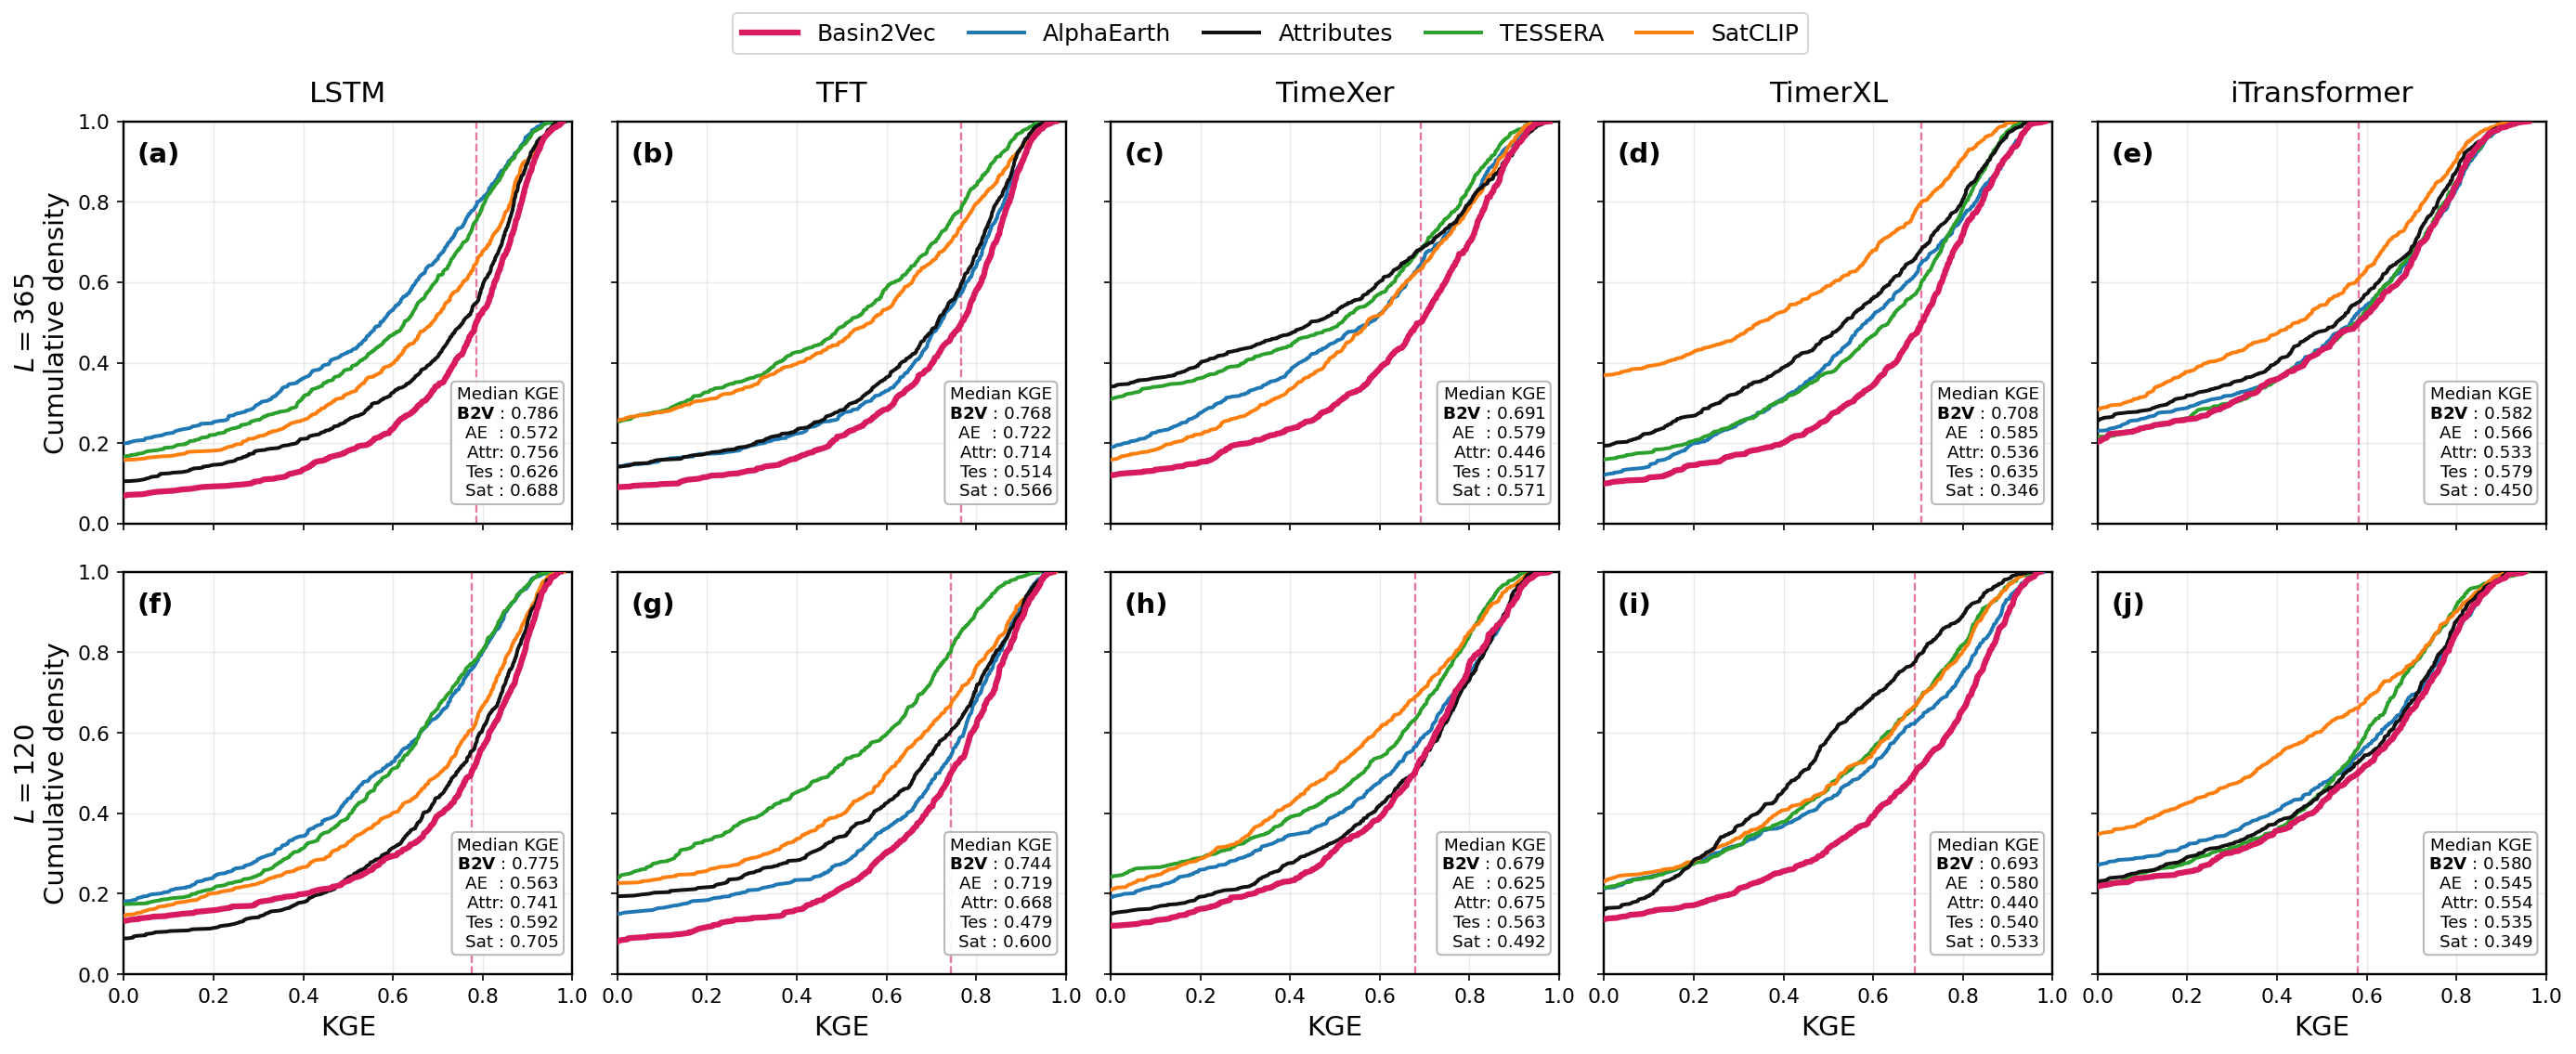

In [33]:
#!/usr/bin/env python3
# ==========================================================
# Plot per-basin NSE CDFs for temporal split results
# with median KGE shown in a small box in each subplot.
#
# Layout:
#   2 rows x 5 columns
#   rows    = sequence lengths [365, 120]
#   columns = models [lstm, tft, timexer, timerxl, itransformer]
#   lines   = static sources [basin2vec, alphaearth, attributes, tessera, satclip]
#
# Expected input structure:
#   evaluation_outputs/camels_exogenous_multimodel_baselines_temporal/
#       temporal_<model>_<static>_seq<seq>_lead0_horizon1/
#           val_per_basin_metrics_horizon1.csv
#
# Outputs:
#   cdf_figures/fig_temporal_per_basin_NSE_cdf_2x5_with_kge_box.png
#   cdf_figures/fig_temporal_per_basin_NSE_cdf_2x5_with_kge_box.pdf
#   cdf_figures/cdf_input_counts_NSE_with_KGE.csv
# ==========================================================

from __future__ import annotations

from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


# ==========================================================
# CONFIG
# ==========================================================

RESULTS_ROOT = Path("evaluation_outputs/camels_exogenous_multimodel_baselines_temporal")

OUT_DIR = RESULTS_ROOT / "cdf_figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

HORIZON = 1
LEAD = 0

# CDF is drawn for NSE; box reports median KGE
PLOT_METRIC = "KGE"
BOX_METRIC = "KGE"

SEQ_LENGTHS = [365, 120]

MODEL_ORDER = [
    "lstm",
    "tft",
    "timexer",
    "timerxl",
    "itransformer",
]

MODEL_LABELS = {
    "lstm": "LSTM",
    "tft": "TFT",
    "timexer": "TimeXer",
    "timerxl": "TimerXL",
    "itransformer": "iTransformer",
}

STATIC_ORDER = [
    "basin2vec",
    "alphaearth",
    "attributes",
    "tessera",
    "satclip",
]

STATIC_LABELS = {
    "basin2vec": "Basin2Vec",
    "alphaearth": "AlphaEarth",
    "attributes": "Attributes",
    "tessera": "TESSERA",
    "satclip": "SatCLIP",
}

STATIC_SHORT = {
    "basin2vec": "B2V",
    "alphaearth": "AE",
    "attributes": "Attr",
    "tessera": "Tes",
    "satclip": "Sat",
}

# Basin2Vec is intentionally prominent
STATIC_STYLES = {
    "basin2vec": {
        "color": "#D81B60",   # prominent magenta
        "linewidth": 3.0,
        "linestyle": "-",
        "zorder": 10,
    },
    "alphaearth": {
        "color": "#1F77B4",
        "linewidth": 1.9,
        "linestyle": "-",
        "zorder": 5,
    },
    "attributes": {
        "color": "#111111",
        "linewidth": 1.9,
        "linestyle": "-",
        "zorder": 6,
    },
    "tessera": {
        "color": "#2CA02C",
        "linewidth": 1.9,
        "linestyle": "-",
        "zorder": 5,
    },
    "satclip": {
        "color": "#FF7F0E",
        "linewidth": 1.9,
        "linestyle": "-",
        "zorder": 5,
    },
}

# For main-paper clean version
X_LIM = (0.0, 1.0)
Y_LIM = (0.0, 1.0)

MIN_BASINS_TO_PLOT = 5
SAVE_DPI = 300


# ==========================================================
# MATPLOTLIB STYLE
# ==========================================================

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": SAVE_DPI,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 13,
    "xtick.labelsize": 10.5,
    "ytick.labelsize": 10.5,
    "legend.fontsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.7,
    "axes.spines.top": True,
    "axes.spines.right": True,
})


# ==========================================================
# HELPERS
# ==========================================================

def normalize_name(x: str) -> str:
    return str(x).strip().lower()


def parse_experiment_name(path: Path):
    """
    Parse folder name:
        temporal_<model>_<static>_seq<seq>_lead0_horizon1
    """
    name = path.name
    pat = (
        r"temporal_"
        r"(?P<model>.+?)_"
        r"(?P<static>.+?)_"
        r"seq(?P<seq>\d+)_"
        r"lead(?P<lead>\d+)_"
        r"horizon(?P<horizon>\d+)"
    )
    m = re.match(pat, name)

    if m is None:
        return {}

    return {
        "model_name": normalize_name(m.group("model")),
        "static_source": normalize_name(m.group("static")),
        "seq_len": int(m.group("seq")),
        "lead": int(m.group("lead")),
        "horizon": int(m.group("horizon")),
    }


def find_per_basin_metric_files(results_root: Path, horizon: int = 1):
    pattern = f"**/val_per_basin_metrics_horizon{horizon}.csv"
    return sorted(results_root.glob(pattern))


def load_all_per_basin_metrics(results_root: Path):
    files = find_per_basin_metric_files(results_root, horizon=HORIZON)

    if len(files) == 0:
        raise FileNotFoundError(
            f"No val_per_basin_metrics_horizon{HORIZON}.csv files found under:\n"
            f"  {results_root.resolve()}"
        )

    rows = []

    for f in files:
        try:
            df = pd.read_csv(f)
        except Exception as e:
            print(f"[skip] Could not read {f}: {e}")
            continue

        if df.empty:
            print(f"[skip] Empty file: {f}")
            continue

        fallback = parse_experiment_name(f.parent)

        for col, val in fallback.items():
            if col not in df.columns:
                df[col] = val

        required = [
            "model_name",
            "static_source",
            "seq_len",
            "horizon",
            "lead",
            PLOT_METRIC,
            BOX_METRIC,
        ]

        missing = [c for c in required if c not in df.columns]
        if missing:
            print(f"[skip] Missing columns {missing}: {f}")
            continue

        df["model_name"] = df["model_name"].map(normalize_name)
        df["static_source"] = df["static_source"].map(normalize_name)
        df["seq_len"] = pd.to_numeric(df["seq_len"], errors="coerce").astype("Int64")
        df["horizon"] = pd.to_numeric(df["horizon"], errors="coerce").astype("Int64")
        df["lead"] = pd.to_numeric(df["lead"], errors="coerce").astype("Int64")
        df[PLOT_METRIC] = pd.to_numeric(df[PLOT_METRIC], errors="coerce")
        df[BOX_METRIC] = pd.to_numeric(df[BOX_METRIC], errors="coerce")

        df["source_file"] = str(f)
        rows.append(df)

    if len(rows) == 0:
        raise RuntimeError("No usable per-basin metric files were loaded.")

    all_df = pd.concat(rows, ignore_index=True)

    # Keep requested horizon/lead only
    all_df = all_df[
        (all_df["horizon"].astype(float) == float(HORIZON)) &
        (all_df["lead"].astype(float) == float(LEAD))
    ].copy()

    # Keep requested models/sources/seq lengths
    all_df = all_df[all_df["model_name"].isin(MODEL_ORDER)].copy()
    all_df = all_df[all_df["static_source"].isin(STATIC_ORDER)].copy()
    all_df = all_df[all_df["seq_len"].astype(int).isin(SEQ_LENGTHS)].copy()

    all_df = all_df.replace([np.inf, -np.inf], np.nan)

    return all_df


def empirical_cdf(values: np.ndarray):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.array([]), np.array([])

    x = np.sort(values)
    y = np.arange(1, len(x) + 1, dtype=float) / float(len(x))

    return x, y


def get_metric_values(
    df: pd.DataFrame,
    model: str,
    static: str,
    seq_len: int,
    metric: str,
):
    sub = df[
        (df["model_name"] == model) &
        (df["static_source"] == static) &
        (df["seq_len"].astype(int) == int(seq_len))
    ].copy()

    values = sub[metric].to_numpy(dtype=float)
    values = values[np.isfinite(values)]

    return values


def make_counts_summary(df: pd.DataFrame):
    rows = []

    for seq in SEQ_LENGTHS:
        for model in MODEL_ORDER:
            for static in STATIC_ORDER:
                nse_values = get_metric_values(df, model, static, seq, PLOT_METRIC)
                kge_values = get_metric_values(df, model, static, seq, BOX_METRIC)

                rows.append({
                    "seq_len": int(seq),
                    "model_name": model,
                    "static_source": static,
                    "n_basins_valid_NSE": int(len(nse_values)),
                    "median_NSE": float(np.nanmedian(nse_values)) if len(nse_values) else np.nan,
                    "mean_NSE": float(np.nanmean(nse_values)) if len(nse_values) else np.nan,
                    "q25_NSE": float(np.nanquantile(nse_values, 0.25)) if len(nse_values) else np.nan,
                    "q75_NSE": float(np.nanquantile(nse_values, 0.75)) if len(nse_values) else np.nan,
                    "n_basins_valid_KGE": int(len(kge_values)),
                    "median_KGE": float(np.nanmedian(kge_values)) if len(kge_values) else np.nan,
                    "mean_KGE": float(np.nanmean(kge_values)) if len(kge_values) else np.nan,
                })

    out = pd.DataFrame(rows)

    out_path = OUT_DIR / f"cdf_input_counts_{PLOT_METRIC}_with_{BOX_METRIC}.csv"
    out.to_csv(out_path, index=False)

    print(f"Saved counts summary: {out_path}")

    return out


def build_kge_box_text(df: pd.DataFrame, model: str, seq_len: int):
    """
    Build small median-KGE box.

    B2V is bolded using matplotlib mathtext.
    """
    lines = ["Median KGE"]

    for static in STATIC_ORDER:
        vals = get_metric_values(df, model, static, seq_len, BOX_METRIC)

        if len(vals) >= MIN_BASINS_TO_PLOT:
            med = float(np.nanmedian(vals))

            if static == "basin2vec":
                lines.append(r"$\mathbf{B2V}$" + f" : {med:.3f}")
            else:
                lines.append(f"{STATIC_SHORT[static]:<4}: {med:.3f}")

    return "\n".join(lines)


# ==========================================================
# PLOTTING
# ==========================================================

def plot_cdf_grid(df: pd.DataFrame):
    n_rows = len(SEQ_LENGTHS)
    n_cols = len(MODEL_ORDER)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(18.5, 7.8),
        sharex=True,
        sharey=True,
        facecolor="white",
    )

    if n_rows == 1:
        axes = np.expand_dims(axes, axis=0)

    legend_handles = {}
    legend_labels = {}

    for r, seq in enumerate(SEQ_LENGTHS):
        for c, model in enumerate(MODEL_ORDER):
            ax = axes[r, c]

            for static in STATIC_ORDER:
                values = get_metric_values(
                    df=df,
                    model=model,
                    static=static,
                    seq_len=seq,
                    metric=PLOT_METRIC,
                )

                if len(values) < MIN_BASINS_TO_PLOT:
                    continue

                x, y = empirical_cdf(values)
                style = STATIC_STYLES[static].copy()

                line, = ax.plot(
                    x,
                    y,
                    label=STATIC_LABELS[static],
                    **style,
                )

                if static not in legend_handles:
                    legend_handles[static] = line
                    legend_labels[static] = STATIC_LABELS[static]

            ax.set_xlim(*X_LIM)
            ax.set_ylim(*Y_LIM)

            ax.grid(True, alpha=0.25, linewidth=0.7)

            for spine in ax.spines.values():
                spine.set_linewidth(1.15)

            # Column titles
            if r == 0:
                ax.set_title(
                    MODEL_LABELS.get(model, model),
                    fontsize=15,
                    pad=10,
                )

            # Row labels
            if c == 0:
                ax.set_ylabel(
                    f"$L={seq}$\nCumulative density",
                    fontsize=14,
                )

            # X labels only on bottom row
            if r == n_rows - 1:
                ax.set_xlabel(PLOT_METRIC, fontsize=14)

            # Basin2Vec median vertical line
            b2v_vals = get_metric_values(
                df=df,
                model=model,
                static="basin2vec",
                seq_len=seq,
                metric=PLOT_METRIC,
            )

            if len(b2v_vals) >= MIN_BASINS_TO_PLOT:
                med_nse = float(np.nanmedian(b2v_vals))
                ax.axvline(
                    med_nse,
                    color=STATIC_STYLES["basin2vec"]["color"],
                    linestyle="--",
                    linewidth=1.1,
                    alpha=0.60,
                    zorder=2,
                )

            # Panel label
            panel_label = chr(ord("a") + r * n_cols + c)
            ax.text(
                0.03,
                0.95,
                f"({panel_label})",
                transform=ax.transAxes,
                fontsize=14,
                fontweight="bold",
                ha="left",
                va="top",
            )

            # Median KGE box
            kge_text = build_kge_box_text(df, model, seq)

            ax.text(
                0.97,
                0.06,
                kge_text,
                transform=ax.transAxes,
                ha="right",
                va="bottom",
                fontsize=8.8,
                bbox=dict(
                    boxstyle="round,pad=0.28",
                    facecolor="white",
                    edgecolor="0.70",
                    alpha=0.92,
                ),
            )

    # Shared legend, closer to plots
    handles = [legend_handles[s] for s in STATIC_ORDER if s in legend_handles]
    labels = [legend_labels[s] for s in STATIC_ORDER if s in legend_labels]

    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.985),
        ncol=len(handles),
        frameon=True,
        fontsize=12,
        columnspacing=1.4,
        handlelength=2.4,
    )

    # No figure title for paper-ready version

    fig.subplots_adjust(
        left=0.055,
        right=0.995,
        bottom=0.09,
        top=0.875,
        wspace=0.10,
        hspace=0.12,
    )

    out_png = OUT_DIR / f"fig_temporal_per_basin_{PLOT_METRIC}_cdf_2x5_with_kge_box.png"
    out_pdf = OUT_DIR / f"fig_temporal_per_basin_{PLOT_METRIC}_cdf_2x5_with_kge_box.pdf"

    fig.savefig(out_png, dpi=SAVE_DPI, bbox_inches="tight")
    fig.savefig(out_pdf, dpi=SAVE_DPI, bbox_inches="tight")

    print(f"Saved: {out_png}")
    print(f"Saved: {out_pdf}")

    plt.show()


# ==========================================================
# MAIN
# ==========================================================

def main():
    print("=" * 80)
    print("Temporal per-basin NSE CDF plot with median KGE box")
    print("=" * 80)
    print("RESULTS_ROOT:", RESULTS_ROOT.resolve())
    print("PLOT_METRIC:", PLOT_METRIC)
    print("BOX_METRIC :", BOX_METRIC)
    print("SEQ_LENGTHS:", SEQ_LENGTHS)
    print("MODEL_ORDER:", MODEL_ORDER)
    print("STATIC_ORDER:", STATIC_ORDER)

    df = load_all_per_basin_metrics(RESULTS_ROOT)

    print("\nLoaded per-basin rows:", len(df))
    print("Models found:", sorted(df["model_name"].dropna().unique().tolist()))
    print("Static sources found:", sorted(df["static_source"].dropna().unique().tolist()))
    print("Seq lengths found:", sorted(df["seq_len"].dropna().astype(int).unique().tolist()))

    counts = make_counts_summary(df)
    print("\nCounts / medians summary:")
    print(counts.to_string(index=False))

    plot_cdf_grid(df)


if __name__ == "__main__":
    main()

Temporal per-basin NSE CDF plot with median KGE box
RESULTS_ROOT: /home/talhamuh/basin2vec/emb/evaluation/evaluation_outputs/camels_exogenous_multimodel_baselines_temporal
PLOT_METRIC: KGE
BOX_METRIC : KGE
SEQ_LENGTHS: [365, 120]
MODEL_ORDER: ['lstm', 'timerxl', 'itransformer']
STATIC_ORDER: ['basin2vec', 'alphaearth', 'attributes', 'tessera', 'satclip']

Loaded per-basin rows: 20090
Models found: ['itransformer', 'lstm', 'timerxl']
Static sources found: ['alphaearth', 'attributes', 'basin2vec', 'satclip', 'tessera']
Seq lengths found: [120, 365]
Saved counts summary: evaluation_outputs/camels_exogenous_multimodel_baselines_temporal/cdf_figures/cdf_input_counts_KGE_with_KGE.csv

Counts / medians summary:
 seq_len   model_name static_source  n_basins_valid_NSE  median_NSE  mean_NSE   q25_NSE  q75_NSE  n_basins_valid_KGE  median_KGE  mean_KGE
     365         lstm     basin2vec                 671    0.785502  0.568263  0.610900 0.873605                 671    0.785502  0.568263
     365

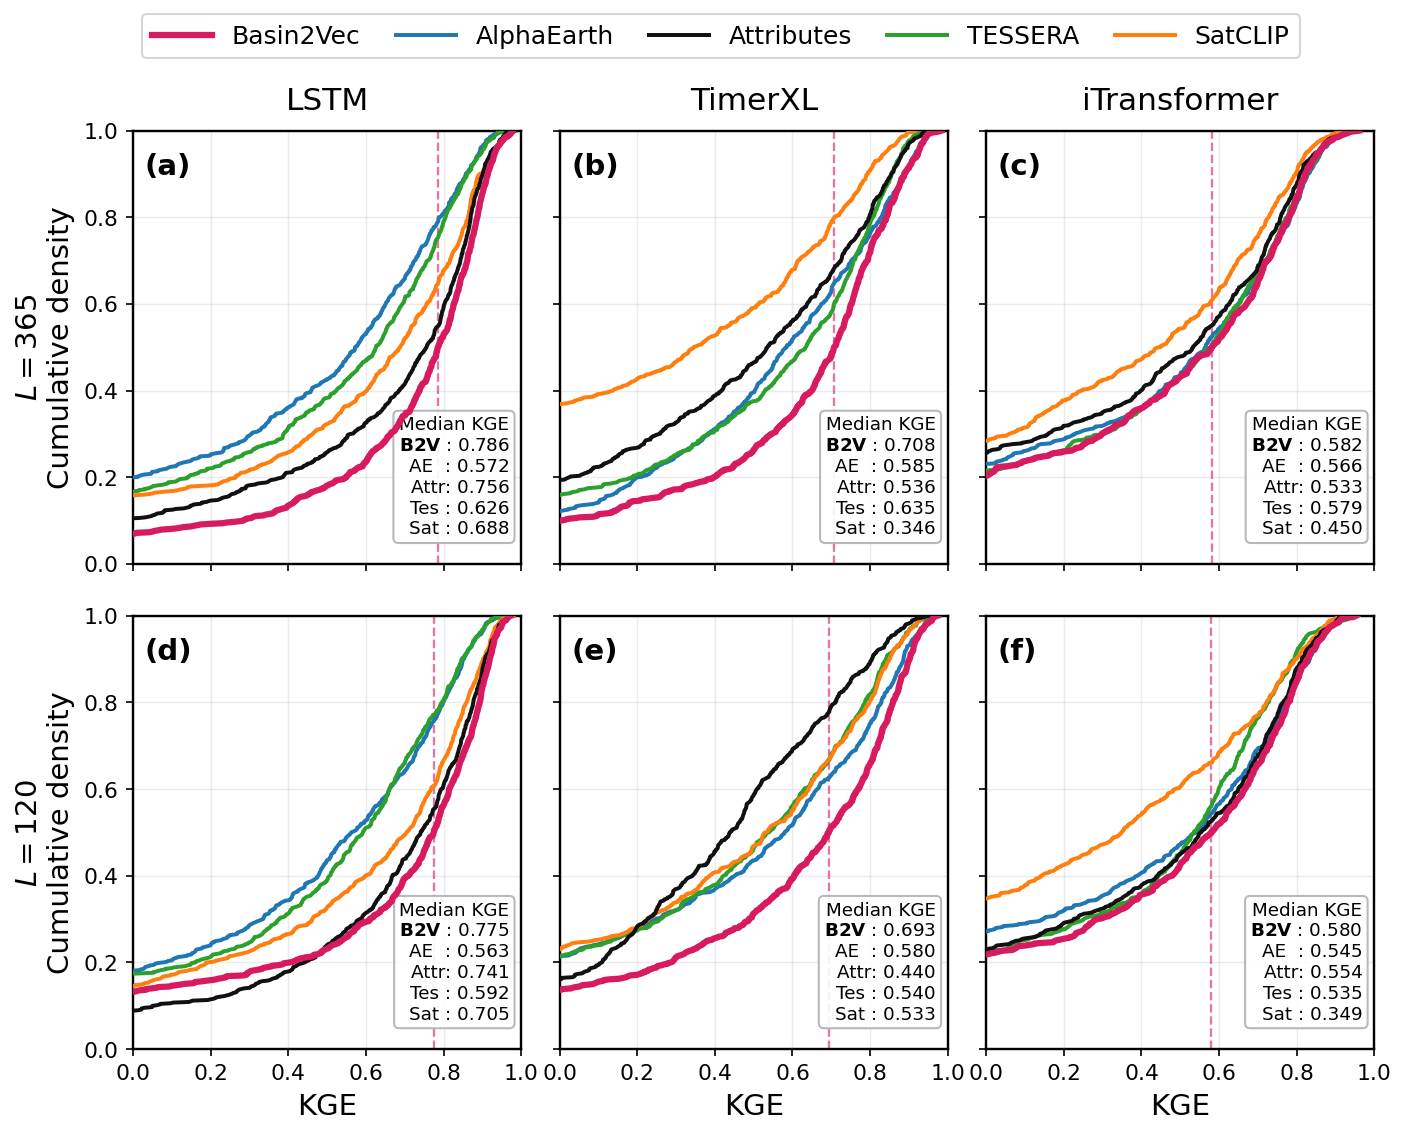

In [ ]:
#!/usr/bin/env python3
# ==========================================================
# Plot per-basin NSE CDFs for temporal split results
# with median KGE shown in a small box in each subplot.
#
# Layout:
#   2 rows x 5 columns
#   rows    = sequence lengths [365, 120]
#   columns = models [lstm, tft, timexer, timerxl, itransformer]
#   lines   = static sources [basin2vec, alphaearth, attributes, tessera, satclip]
#
# Expected input structure:
#   evaluation_outputs/camels_exogenous_multimodel_baselines_temporal/
#       temporal_<model>_<static>_seq<seq>_lead0_horizon1/
#           val_per_basin_metrics_horizon1.csv
#
# Outputs:
#   cdf_figures/fig_temporal_per_basin_NSE_cdf_2x5_with_kge_box.png
#   cdf_figures/fig_temporal_per_basin_NSE_cdf_2x5_with_kge_box.pdf
#   cdf_figures/cdf_input_counts_NSE_with_KGE.csv
# ==========================================================

from __future__ import annotations

from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


# ==========================================================
# CONFIG
# ==========================================================

RESULTS_ROOT = Path("evaluation_outputs/camels_exogenous_multimodel_baselines_temporal")

OUT_DIR = RESULTS_ROOT / "cdf_figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

HORIZON = 1
LEAD = 0

# CDF is drawn for NSE; box reports median KGE
PLOT_METRIC = "KGE"
BOX_METRIC = "KGE"

SEQ_LENGTHS = [365, 120]

MODEL_ORDER = [
    "lstm",
    "timerxl",
    "itransformer",
]

MODEL_LABELS = {
    "lstm": "LSTM",
    "tft": "TFT",
    "timexer": "TimeXer",
    "timerxl": "TimerXL",
    "itransformer": "iTransformer",
}

STATIC_ORDER = [
    "basin2vec",
    "alphaearth",
    "attributes",
    "tessera",
    "satclip",
]

STATIC_LABELS = {
    "basin2vec": "Basin2Vec",
    "alphaearth": "AlphaEarth",
    "attributes": "Attributes",
    "tessera": "TESSERA",
    "satclip": "SatCLIP",
}

STATIC_SHORT = {
    "basin2vec": "B2V",
    "alphaearth": "AE",
    "attributes": "Attr",
    "tessera": "Tes",
    "satclip": "Sat",
}

# Basin2Vec is intentionally prominent
STATIC_STYLES = {
    "basin2vec": {
        "color": "#D81B60",   # prominent magenta
        "linewidth": 3.0,
        "linestyle": "-",
        "zorder": 10,
    },
    "alphaearth": {
        "color": "#1F77B4",
        "linewidth": 1.9,
        "linestyle": "-",
        "zorder": 5,
    },
    "attributes": {
        "color": "#111111",
        "linewidth": 1.9,
        "linestyle": "-",
        "zorder": 6,
    },
    "tessera": {
        "color": "#2CA02C",
        "linewidth": 1.9,
        "linestyle": "-",
        "zorder": 5,
    },
    "satclip": {
        "color": "#FF7F0E",
        "linewidth": 1.9,
        "linestyle": "-",
        "zorder": 5,
    },
}

# For main-paper clean version
X_LIM = (0.0, 1.0)
Y_LIM = (0.0, 1.0)

MIN_BASINS_TO_PLOT = 5
SAVE_DPI = 300


# ==========================================================
# MATPLOTLIB STYLE
# ==========================================================

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": SAVE_DPI,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 13,
    "xtick.labelsize": 10.5,
    "ytick.labelsize": 10.5,
    "legend.fontsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.7,
    "axes.spines.top": True,
    "axes.spines.right": True,
})


# ==========================================================
# HELPERS
# ==========================================================

def normalize_name(x: str) -> str:
    return str(x).strip().lower()


def parse_experiment_name(path: Path):
    """
    Parse folder name:
        temporal_<model>_<static>_seq<seq>_lead0_horizon1
    """
    name = path.name
    pat = (
        r"temporal_"
        r"(?P<model>.+?)_"
        r"(?P<static>.+?)_"
        r"seq(?P<seq>\d+)_"
        r"lead(?P<lead>\d+)_"
        r"horizon(?P<horizon>\d+)"
    )
    m = re.match(pat, name)

    if m is None:
        return {}

    return {
        "model_name": normalize_name(m.group("model")),
        "static_source": normalize_name(m.group("static")),
        "seq_len": int(m.group("seq")),
        "lead": int(m.group("lead")),
        "horizon": int(m.group("horizon")),
    }


def find_per_basin_metric_files(results_root: Path, horizon: int = 1):
    pattern = f"**/val_per_basin_metrics_horizon{horizon}.csv"
    return sorted(results_root.glob(pattern))


def load_all_per_basin_metrics(results_root: Path):
    files = find_per_basin_metric_files(results_root, horizon=HORIZON)

    if len(files) == 0:
        raise FileNotFoundError(
            f"No val_per_basin_metrics_horizon{HORIZON}.csv files found under:\n"
            f"  {results_root.resolve()}"
        )

    rows = []

    for f in files:
        try:
            df = pd.read_csv(f)
        except Exception as e:
            print(f"[skip] Could not read {f}: {e}")
            continue

        if df.empty:
            print(f"[skip] Empty file: {f}")
            continue

        fallback = parse_experiment_name(f.parent)

        for col, val in fallback.items():
            if col not in df.columns:
                df[col] = val

        required = [
            "model_name",
            "static_source",
            "seq_len",
            "horizon",
            "lead",
            PLOT_METRIC,
            BOX_METRIC,
        ]

        missing = [c for c in required if c not in df.columns]
        if missing:
            print(f"[skip] Missing columns {missing}: {f}")
            continue

        df["model_name"] = df["model_name"].map(normalize_name)
        df["static_source"] = df["static_source"].map(normalize_name)
        df["seq_len"] = pd.to_numeric(df["seq_len"], errors="coerce").astype("Int64")
        df["horizon"] = pd.to_numeric(df["horizon"], errors="coerce").astype("Int64")
        df["lead"] = pd.to_numeric(df["lead"], errors="coerce").astype("Int64")
        df[PLOT_METRIC] = pd.to_numeric(df[PLOT_METRIC], errors="coerce")
        df[BOX_METRIC] = pd.to_numeric(df[BOX_METRIC], errors="coerce")

        df["source_file"] = str(f)
        rows.append(df)

    if len(rows) == 0:
        raise RuntimeError("No usable per-basin metric files were loaded.")

    all_df = pd.concat(rows, ignore_index=True)

    # Keep requested horizon/lead only
    all_df = all_df[
        (all_df["horizon"].astype(float) == float(HORIZON)) &
        (all_df["lead"].astype(float) == float(LEAD))
    ].copy()

    # Keep requested models/sources/seq lengths
    all_df = all_df[all_df["model_name"].isin(MODEL_ORDER)].copy()
    all_df = all_df[all_df["static_source"].isin(STATIC_ORDER)].copy()
    all_df = all_df[all_df["seq_len"].astype(int).isin(SEQ_LENGTHS)].copy()

    all_df = all_df.replace([np.inf, -np.inf], np.nan)

    return all_df


def empirical_cdf(values: np.ndarray):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.array([]), np.array([])

    x = np.sort(values)
    y = np.arange(1, len(x) + 1, dtype=float) / float(len(x))

    return x, y


def get_metric_values(
    df: pd.DataFrame,
    model: str,
    static: str,
    seq_len: int,
    metric: str,
):
    sub = df[
        (df["model_name"] == model) &
        (df["static_source"] == static) &
        (df["seq_len"].astype(int) == int(seq_len))
    ].copy()

    values = sub[metric].to_numpy(dtype=float)
    values = values[np.isfinite(values)]

    return values


def make_counts_summary(df: pd.DataFrame):
    rows = []

    for seq in SEQ_LENGTHS:
        for model in MODEL_ORDER:
            for static in STATIC_ORDER:
                nse_values = get_metric_values(df, model, static, seq, PLOT_METRIC)
                kge_values = get_metric_values(df, model, static, seq, BOX_METRIC)

                rows.append({
                    "seq_len": int(seq),
                    "model_name": model,
                    "static_source": static,
                    "n_basins_valid_NSE": int(len(nse_values)),
                    "median_NSE": float(np.nanmedian(nse_values)) if len(nse_values) else np.nan,
                    "mean_NSE": float(np.nanmean(nse_values)) if len(nse_values) else np.nan,
                    "q25_NSE": float(np.nanquantile(nse_values, 0.25)) if len(nse_values) else np.nan,
                    "q75_NSE": float(np.nanquantile(nse_values, 0.75)) if len(nse_values) else np.nan,
                    "n_basins_valid_KGE": int(len(kge_values)),
                    "median_KGE": float(np.nanmedian(kge_values)) if len(kge_values) else np.nan,
                    "mean_KGE": float(np.nanmean(kge_values)) if len(kge_values) else np.nan,
                })

    out = pd.DataFrame(rows)

    out_path = OUT_DIR / f"cdf_input_counts_{PLOT_METRIC}_with_{BOX_METRIC}.csv"
    out.to_csv(out_path, index=False)

    print(f"Saved counts summary: {out_path}")

    return out


def build_kge_box_text(df: pd.DataFrame, model: str, seq_len: int):
    """
    Build small median-KGE box.

    B2V is bolded using matplotlib mathtext.
    """
    lines = ["Median KGE"]

    for static in STATIC_ORDER:
        vals = get_metric_values(df, model, static, seq_len, BOX_METRIC)

        if len(vals) >= MIN_BASINS_TO_PLOT:
            med = float(np.nanmedian(vals))

            if static == "basin2vec":
                lines.append(r"$\mathbf{B2V}$" + f" : {med:.3f}")
            else:
                lines.append(f"{STATIC_SHORT[static]:<4}: {med:.3f}")

    return "\n".join(lines)


# ==========================================================
# PLOTTING
# ==========================================================

def plot_cdf_grid(df: pd.DataFrame):
    n_rows = len(SEQ_LENGTHS)
    n_cols = len(MODEL_ORDER)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(8.8, 7.8),
        sharex=True,
        sharey=True,
        facecolor="white",
    )

    if n_rows == 1:
        axes = np.expand_dims(axes, axis=0)

    legend_handles = {}
    legend_labels = {}

    for r, seq in enumerate(SEQ_LENGTHS):
        for c, model in enumerate(MODEL_ORDER):
            ax = axes[r, c]

            for static in STATIC_ORDER:
                values = get_metric_values(
                    df=df,
                    model=model,
                    static=static,
                    seq_len=seq,
                    metric=PLOT_METRIC,
                )

                if len(values) < MIN_BASINS_TO_PLOT:
                    continue

                x, y = empirical_cdf(values)
                style = STATIC_STYLES[static].copy()

                line, = ax.plot(
                    x,
                    y,
                    label=STATIC_LABELS[static],
                    **style,
                )

                if static not in legend_handles:
                    legend_handles[static] = line
                    legend_labels[static] = STATIC_LABELS[static]

            ax.set_xlim(*X_LIM)
            ax.set_ylim(*Y_LIM)

            ax.grid(True, alpha=0.25, linewidth=0.7)

            for spine in ax.spines.values():
                spine.set_linewidth(1.15)

            # Column titles
            if r == 0:
                ax.set_title(
                    MODEL_LABELS.get(model, model),
                    fontsize=15,
                    pad=10,
                )

            # Row labels
            if c == 0:
                ax.set_ylabel(
                    f"$L={seq}$\nCumulative density",
                    fontsize=14,
                )
            
            # X labels only on bottom row
            if r == n_rows - 1:
                ax.set_xlabel(PLOT_METRIC, fontsize=14)

            # Basin2Vec median vertical line
            b2v_vals = get_metric_values(
                df=df,
                model=model,
                static="basin2vec",
                seq_len=seq,
                metric=PLOT_METRIC,
            )

            if len(b2v_vals) >= MIN_BASINS_TO_PLOT:
                med_nse = float(np.nanmedian(b2v_vals))
                ax.axvline(
                    med_nse,
                    color=STATIC_STYLES["basin2vec"]["color"],
                    linestyle="--",
                    linewidth=1.1,
                    alpha=0.60,
                    zorder=2,
                )

            # Panel label
            panel_label = chr(ord("a") + r * n_cols + c)
            ax.text(
                0.03,
                0.95,
                f"({panel_label})",
                transform=ax.transAxes,
                fontsize=14,
                fontweight="bold",
                ha="left",
                va="top",
            )

            # Median KGE box
            kge_text = build_kge_box_text(df, model, seq)

            ax.text(
                0.97,
                0.06,
                kge_text,
                transform=ax.transAxes,
                ha="right",
                va="bottom",
                fontsize=8.8,
                bbox=dict(
                    boxstyle="round,pad=0.28",
                    facecolor="white",
                    edgecolor="0.70",
                    alpha=0.92,
                ),
            )

    # Shared legend, closer to plots
    handles = [legend_handles[s] for s in STATIC_ORDER if s in legend_handles]
    labels = [legend_labels[s] for s in STATIC_ORDER if s in legend_labels]

    fig.legend(
        handles,
        labels,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.985),
        ncol=len(handles),
        frameon=True,
        fontsize=12,
        columnspacing=1.4,
        handlelength=2.4,
    )

    # No figure title for paper-ready version

    fig.subplots_adjust(
        left=0.055,
        right=0.995,
        bottom=0.09,
        top=0.875,
        wspace=0.10,
        hspace=0.12,
    )

    out_png = OUT_DIR / f"fig_temporal_per_basin_{PLOT_METRIC}_cdf_2x5_with_kge_box.png"
    out_pdf = OUT_DIR / f"fig_temporal_per_basin_{PLOT_METRIC}_cdf_2x5_with_kge_box.pdf"

    fig.savefig(out_png, dpi=SAVE_DPI, bbox_inches="tight")
    fig.savefig(out_pdf, dpi=SAVE_DPI, bbox_inches="tight")

    print(f"Saved: {out_png}")
    print(f"Saved: {out_pdf}")

    plt.show()


# ==========================================================
# MAIN
# ==========================================================

def main():
    print("=" * 80)
    print("Temporal per-basin NSE CDF plot with median KGE box")
    print("=" * 80)
    print("RESULTS_ROOT:", RESULTS_ROOT.resolve())
    print("PLOT_METRIC:", PLOT_METRIC)
    print("BOX_METRIC :", BOX_METRIC)
    print("SEQ_LENGTHS:", SEQ_LENGTHS)
    print("MODEL_ORDER:", MODEL_ORDER)
    print("STATIC_ORDER:", STATIC_ORDER)

    df = load_all_per_basin_metrics(RESULTS_ROOT)

    print("\nLoaded per-basin rows:", len(df))
    print("Models found:", sorted(df["model_name"].dropna().unique().tolist()))
    print("Static sources found:", sorted(df["static_source"].dropna().unique().tolist()))
    print("Seq lengths found:", sorted(df["seq_len"].dropna().astype(int).unique().tolist()))

    counts = make_counts_summary(df)
    print("\nCounts / medians summary:")
    print(counts.to_string(index=False))

    plot_cdf_grid(df)


if __name__ == "__main__":
    main()

Spatial split per-basin NSE/KGE CDF plot
RESULTS_ROOT: /home/talhamuh/basin2vec/emb/evaluation/evaluation_outputs/camels_671_kratzert_style_ungauged_kfold_optionA_basin2vec_aggregated
SEQ_LEN: 365
PLOT_METRICS: ['NSE', 'KGE']
MODEL_ORDER: ['lstm', 'tft', 'timexer', 'timerxl', 'itransformer']
STATIC_ORDER: ['basin2vec', 'alphaearth', 'attributes', 'tessera', 'satclip']

Loaded per-basin rows: 16775
Models found: ['itransformer', 'lstm', 'tft', 'timerxl', 'timexer']
Static sources found: ['alphaearth', 'attributes', 'basin2vec', 'satclip', 'tessera']
Seq lengths found: [365]
Folds found: [0, 1, 2, 3, 4, 5]
Saved counts summary: evaluation_outputs/camels_671_kratzert_style_ungauged_kfold_optionA_basin2vec_aggregated/cdf_figures/cdf_input_counts_spatial_NSE_KGE_seq365.csv

Counts / medians summary:
 seq_len   model_name static_source  n_folds  n_basins_valid_NSE  median_NSE    mean_NSE   q25_NSE  q75_NSE  frac_NSE_gt_0  frac_NSE_gt_0_5  frac_NSE_gt_0_7  n_basins_valid_KGE  median_KGE  mean

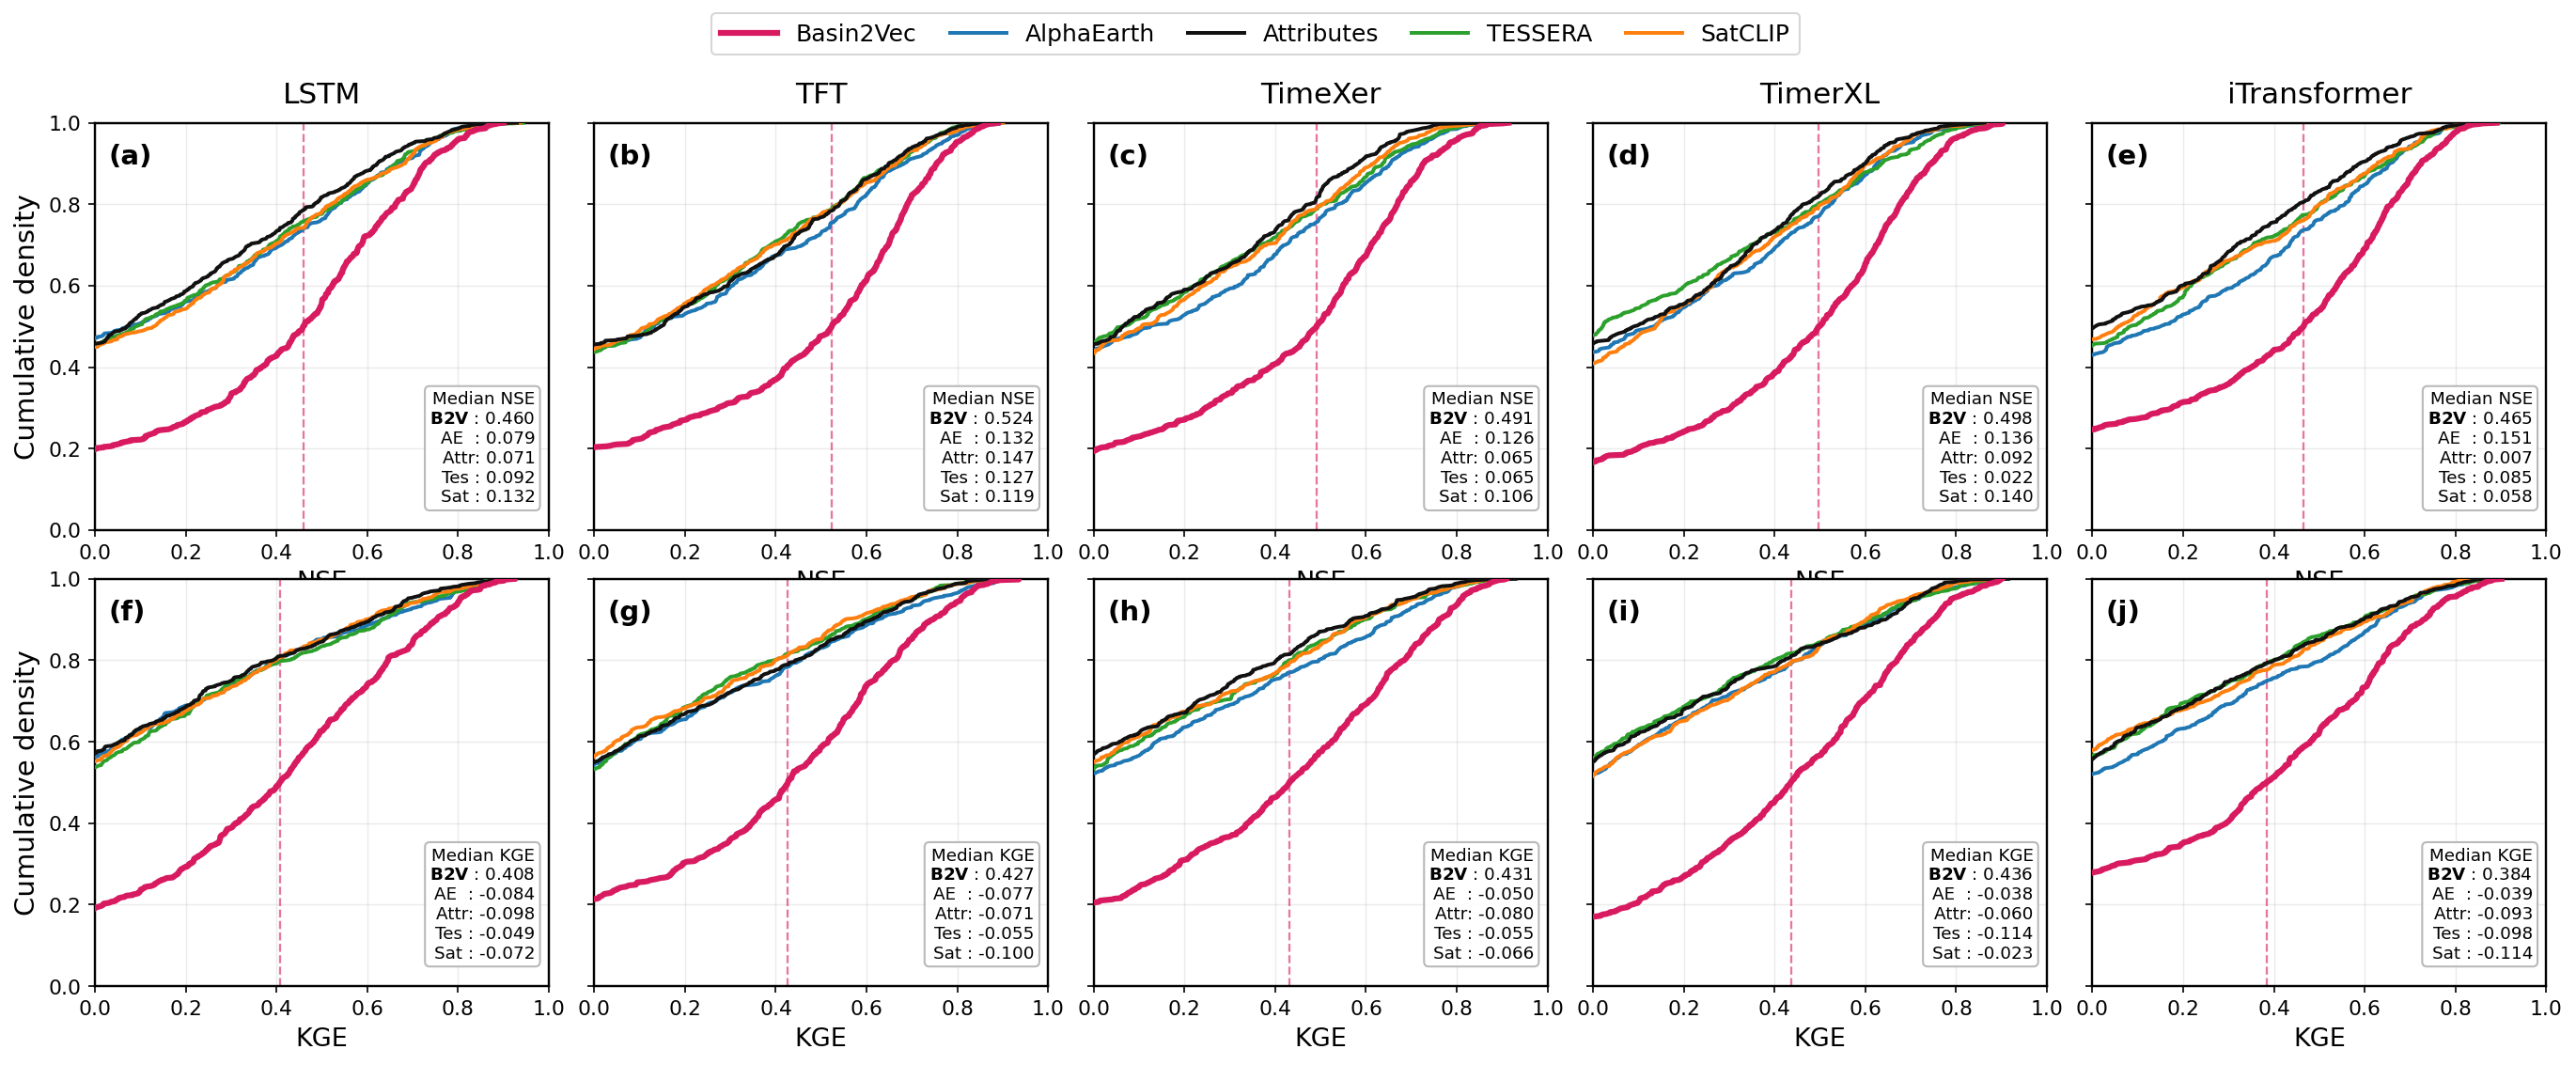

In [80]:
#!/usr/bin/env python3
# ==========================================================
# Spatial split per-basin CDF plots for unseen basins
#
# Layout:
#   2 rows x 5 columns
#   rows    = metrics [NSE, KGE]
#   columns = models [lstm, tft, timexer, timerxl, itransformer]
#   lines   = static sources [basin2vec, alphaearth, attributes, tessera, satclip]
#
# Fixed:
#   seq_len = 365
#   horizon = 1
#   lead = 0
#
# Expected input structure:
#   evaluation_outputs/camels_671_kratzert_style_ungauged_kfold_optionA_basin2vec_aggregated/
#       fold00_lstm_basin2vec_seq365_lead0_horizon1_camels671_kratzert_optionA/
#           test_per_basin_metrics_horizon1.csv
#       fold01_lstm_basin2vec_seq365_lead0_horizon1_camels671_kratzert_optionA/
#           test_per_basin_metrics_horizon1.csv
#       ...
#
# Outputs:
#   cdf_figures/
#       fig_spatial_per_basin_NSE_KGE_cdf_seq365.png
#       fig_spatial_per_basin_NSE_KGE_cdf_seq365.pdf
#       cdf_input_counts_spatial_NSE_KGE_seq365.csv
# ==========================================================

from __future__ import annotations

from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


# ==========================================================
# CONFIG
# ==========================================================

RESULTS_ROOT = Path(
    "evaluation_outputs/camels_671_kratzert_style_ungauged_kfold_optionA_basin2vec_aggregated"
)

OUT_DIR = RESULTS_ROOT / "cdf_figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

HORIZON = 1
LEAD = 0
SEQ_LEN = 365

PLOT_METRICS = ["NSE", "KGE"]

MODEL_ORDER = [
    "lstm",
    "tft",
    "timexer",
    "timerxl",
    "itransformer",
]

MODEL_LABELS = {
    "lstm": "LSTM",
    "tft": "TFT",
    "timexer": "TimeXer",
    "timerxl": "TimerXL",
    "itransformer": "iTransformer",
}

STATIC_ORDER = [
    "basin2vec",
    "alphaearth",
    "attributes",
    "tessera",
    "satclip",
]

STATIC_LABELS = {
    "basin2vec": "Basin2Vec",
    "alphaearth": "AlphaEarth",
    "attributes": "Attributes",
    "tessera": "TESSERA",
    "satclip": "SatCLIP",
}

STATIC_SHORT = {
    "basin2vec": "B2V",
    "alphaearth": "AE",
    "attributes": "Attr",
    "tessera": "Tes",
    "satclip": "Sat",
}

STATIC_STYLES = {
    "basin2vec": {
        "color": "#D81B60",
        "linewidth": 3.0,
        "linestyle": "-",
        "zorder": 10,
    },
    "alphaearth": {
        "color": "#1F77B4",
        "linewidth": 1.9,
        "linestyle": "-",
        "zorder": 5,
    },
    "attributes": {
        "color": "#111111",
        "linewidth": 1.9,
        "linestyle": "-",
        "zorder": 6,
    },
    "tessera": {
        "color": "#2CA02C",
        "linewidth": 1.9,
        "linestyle": "-",
        "zorder": 5,
    },
    "satclip": {
        "color": "#FF7F0E",
        "linewidth": 1.9,
        "linestyle": "-",
        "zorder": 5,
    },
}

# Main-paper clean range.
# For appendix, you may use (-1.0, 1.0) for NSE/KGE to show failed basins.
XLIMS = {
    "NSE": (0.0, 1.0),
    "KGE": (0.0, 1.0),
}

Y_LIM = (0.0, 1.0)

MIN_BASINS_TO_PLOT = 5
SAVE_DPI = 300


# ==========================================================
# MATPLOTLIB STYLE
# ==========================================================

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": SAVE_DPI,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 13,
    "xtick.labelsize": 10.5,
    "ytick.labelsize": 10.5,
    "legend.fontsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.7,
    "axes.spines.top": True,
    "axes.spines.right": True,
})


# ==========================================================
# HELPERS
# ==========================================================

def normalize_name(x: str) -> str:
    x = str(x).strip().lower()

    if x in {"itransformer", "itransformer".lower(), "itransformer"}:
        return "itransformer"
    if x in {"iTransformer".lower(), "itransformer"}:
        return "itransformer"
    if x in {"b2v", "basin2vec"}:
        return "basin2vec"
    if x in {"ae", "alphaearth", "alpha_earth"}:
        return "alphaearth"
    if x in {"attr", "attribute", "attributes"}:
        return "attributes"
    if x in {"satclip", "satclip-8point", "satclip_8point"}:
        return "satclip"
    if x in {"tessera", "tessera_8point"}:
        return "tessera"

    return x


def parse_spatial_experiment_name(path: Path):
    """
    Parse folder name:
        fold00_lstm_basin2vec_seq365_lead0_horizon1_camels671_kratzert_optionA
    """
    name = path.name

    pat = (
        r"fold(?P<fold>\d+)_"
        r"(?P<model>.+?)_"
        r"(?P<static>.+?)_"
        r"seq(?P<seq>\d+)_"
        r"lead(?P<lead>\d+)_"
        r"horizon(?P<horizon>\d+)"
    )

    m = re.match(pat, name)

    if m is None:
        return {}

    return {
        "fold_id": int(m.group("fold")),
        "model_name": normalize_name(m.group("model")),
        "static_source": normalize_name(m.group("static")),
        "seq_len": int(m.group("seq")),
        "lead": int(m.group("lead")),
        "horizon": int(m.group("horizon")),
    }


def find_per_basin_metric_files(results_root: Path, horizon: int = 1):
    pattern = f"**/test_per_basin_metrics_horizon{horizon}.csv"
    return sorted(results_root.glob(pattern))


def load_all_spatial_per_basin_metrics(results_root: Path):
    files = find_per_basin_metric_files(results_root, horizon=HORIZON)

    if len(files) == 0:
        raise FileNotFoundError(
            f"No test_per_basin_metrics_horizon{HORIZON}.csv files found under:\n"
            f"  {results_root.resolve()}"
        )

    rows = []

    for f in files:
        try:
            df = pd.read_csv(f)
        except Exception as e:
            print(f"[skip] Could not read {f}: {e}")
            continue

        if df.empty:
            print(f"[skip] Empty file: {f}")
            continue

        fallback = parse_spatial_experiment_name(f.parent)

        for col, val in fallback.items():
            if col not in df.columns:
                df[col] = val

        required = [
            "fold_id",
            "model_name",
            "static_source",
            "seq_len",
            "horizon",
            "lead",
            "site_id",
        ] + PLOT_METRICS

        missing = [c for c in required if c not in df.columns]
        if missing:
            print(f"[skip] Missing columns {missing}: {f}")
            continue

        df["fold_id"] = pd.to_numeric(df["fold_id"], errors="coerce").astype("Int64")
        df["model_name"] = df["model_name"].map(normalize_name)
        df["static_source"] = df["static_source"].map(normalize_name)
        df["seq_len"] = pd.to_numeric(df["seq_len"], errors="coerce").astype("Int64")
        df["horizon"] = pd.to_numeric(df["horizon"], errors="coerce").astype("Int64")
        df["lead"] = pd.to_numeric(df["lead"], errors="coerce").astype("Int64")
        df["site_id"] = df["site_id"].astype(str)

        for metric in PLOT_METRICS:
            df[metric] = pd.to_numeric(df[metric], errors="coerce")

        df["source_file"] = str(f)
        rows.append(df)

    if len(rows) == 0:
        raise RuntimeError("No usable spatial per-basin metric files were loaded.")

    all_df = pd.concat(rows, ignore_index=True)

    all_df = all_df[
        (all_df["horizon"].astype(float) == float(HORIZON)) &
        (all_df["lead"].astype(float) == float(LEAD)) &
        (all_df["seq_len"].astype(float) == float(SEQ_LEN))
    ].copy()

    all_df = all_df[all_df["model_name"].isin(MODEL_ORDER)].copy()
    all_df = all_df[all_df["static_source"].isin(STATIC_ORDER)].copy()

    all_df = all_df.replace([np.inf, -np.inf], np.nan)

    # Prevent duplicate CDF weights if rerun folders or copied files exist.
    dedup_cols = [
        "fold_id",
        "model_name",
        "static_source",
        "seq_len",
        "horizon",
        "lead",
        "site_id",
    ]

    before = len(all_df)
    all_df = all_df.drop_duplicates(subset=dedup_cols, keep="last").copy()
    after = len(all_df)

    if before != after:
        print(f"[dedup] Dropped {before - after} duplicate per-basin rows.")

    return all_df


def empirical_cdf(values: np.ndarray):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.array([]), np.array([])

    x = np.sort(values)
    y = np.arange(1, len(x) + 1, dtype=float) / float(len(x))

    return x, y


def get_metric_values(
    df: pd.DataFrame,
    model: str,
    static: str,
    metric: str,
):
    sub = df[
        (df["model_name"] == model) &
        (df["static_source"] == static)
    ].copy()

    values = sub[metric].to_numpy(dtype=float)
    values = values[np.isfinite(values)]

    return values


def get_n_folds(df: pd.DataFrame, model: str, static: str):
    sub = df[
        (df["model_name"] == model) &
        (df["static_source"] == static)
    ].copy()

    if len(sub) == 0:
        return 0

    return int(sub["fold_id"].nunique())


def make_counts_summary(df: pd.DataFrame):
    rows = []

    for model in MODEL_ORDER:
        for static in STATIC_ORDER:
            n_folds = get_n_folds(df, model, static)

            row = {
                "seq_len": int(SEQ_LEN),
                "model_name": model,
                "static_source": static,
                "n_folds": int(n_folds),
            }

            for metric in PLOT_METRICS:
                values = get_metric_values(df, model, static, metric)

                row[f"n_basins_valid_{metric}"] = int(len(values))
                row[f"median_{metric}"] = float(np.nanmedian(values)) if len(values) else np.nan
                row[f"mean_{metric}"] = float(np.nanmean(values)) if len(values) else np.nan
                row[f"q25_{metric}"] = float(np.nanquantile(values, 0.25)) if len(values) else np.nan
                row[f"q75_{metric}"] = float(np.nanquantile(values, 0.75)) if len(values) else np.nan
                row[f"frac_{metric}_gt_0"] = float(np.mean(values > 0.0)) if len(values) else np.nan
                row[f"frac_{metric}_gt_0_5"] = float(np.mean(values > 0.5)) if len(values) else np.nan
                row[f"frac_{metric}_gt_0_7"] = float(np.mean(values > 0.7)) if len(values) else np.nan

            rows.append(row)

    out = pd.DataFrame(rows)

    out_path = OUT_DIR / f"cdf_input_counts_spatial_NSE_KGE_seq{SEQ_LEN}.csv"
    out.to_csv(out_path, index=False)

    print(f"Saved counts summary: {out_path}")

    return out


def build_median_box_text(df: pd.DataFrame, model: str, metric: str):
    """
    Build small median metric box.

    B2V is bolded using matplotlib mathtext.
    """
    lines = [f"Median {metric}"]

    for static in STATIC_ORDER:
        vals = get_metric_values(df, model, static, metric)

        if len(vals) >= MIN_BASINS_TO_PLOT:
            med = float(np.nanmedian(vals))

            if static == "basin2vec":
                lines.append(r"$\mathbf{B2V}$" + f" : {med:.3f}")
            else:
                lines.append(f"{STATIC_SHORT[static]:<4}: {med:.3f}")

    return "\n".join(lines)


def annotate_missing(ax, text="No data"):
    ax.text(
        0.5,
        0.5,
        text,
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=13,
        color="0.45",
    )


# ==========================================================
# PLOTTING
# ==========================================================

def plot_cdf_grid(df: pd.DataFrame):
    n_rows = len(PLOT_METRICS)
    n_cols = len(MODEL_ORDER)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(18.5, 7.8),
        sharex=False,
        sharey=True,
        facecolor="white",
    )

    if n_rows == 1:
        axes = np.expand_dims(axes, axis=0)

    legend_handles = {}
    legend_labels = {}

    for r, metric in enumerate(PLOT_METRICS):
        for c, model in enumerate(MODEL_ORDER):
            ax = axes[r, c]

            any_line = False

            for static in STATIC_ORDER:
                values = get_metric_values(
                    df=df,
                    model=model,
                    static=static,
                    metric=metric,
                )

                if len(values) < MIN_BASINS_TO_PLOT:
                    continue

                x, y = empirical_cdf(values)
                style = STATIC_STYLES[static].copy()

                line, = ax.plot(
                    x,
                    y,
                    label=STATIC_LABELS[static],
                    **style,
                )

                any_line = True

                if static not in legend_handles:
                    legend_handles[static] = line
                    legend_labels[static] = STATIC_LABELS[static]

            ax.set_xlim(*XLIMS.get(metric, (0.0, 0.85)))
            ax.set_ylim(*Y_LIM)

            ax.grid(True, alpha=0.25, linewidth=0.7)

            for spine in ax.spines.values():
                spine.set_linewidth(1.15)

            # Column titles only on top row
            if r == 0:
                ax.set_title(
                    MODEL_LABELS.get(model, model),
                    fontsize=15,
                    pad=10,
                )

            # Row labels
            if c == 0:
                ax.set_ylabel(
                    f"Cumulative density",
                    fontsize=14,
                )
            

            # X-axis label
            ax.set_xlabel(metric, fontsize=13)

            # Basin2Vec median vertical line for the current metric
            b2v_vals = get_metric_values(
                df=df,
                model=model,
                static="basin2vec",
                metric=metric,
            )

            if len(b2v_vals) >= MIN_BASINS_TO_PLOT:
                med = float(np.nanmedian(b2v_vals))
                ax.axvline(
                    med,
                    color=STATIC_STYLES["basin2vec"]["color"],
                    linestyle="--",
                    linewidth=1.1,
                    alpha=0.60,
                    zorder=2,
                )

            # Panel label
            panel_label = chr(ord("a") + r * n_cols + c)
            ax.text(
                0.03,
                0.95,
                f"({panel_label})",
                transform=ax.transAxes,
                fontsize=14,
                fontweight="bold",
                ha="left",
                va="top",
            )

            if any_line:
                box_text = build_median_box_text(df, model, metric)

                ax.text(
                    0.97,
                    0.06,
                    box_text,
                    transform=ax.transAxes,
                    ha="right",
                    va="bottom",
                    fontsize=8.8,
                    bbox=dict(
                        boxstyle="round,pad=0.28",
                        facecolor="white",
                        edgecolor="0.70",
                        alpha=0.92,
                    ),
                )
            else:
                annotate_missing(ax)

    # Shared legend, close to plots
    handles = [legend_handles[s] for s in STATIC_ORDER if s in legend_handles]
    labels = [legend_labels[s] for s in STATIC_ORDER if s in legend_labels]

    if handles:
        fig.legend(
            handles,
            labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.985),
            ncol=len(handles),
            frameon=True,
            fontsize=12,
            columnspacing=1.4,
            handlelength=2.4,
        )

    # No figure title for paper-ready version
    fig.subplots_adjust(
        left=0.055,
        right=0.995,
        bottom=0.09,
        top=0.875,
        wspace=0.10,
        hspace=0.12,
    )

    out_png = OUT_DIR / f"fig_spatial_per_basin_NSE_KGE_cdf_seq{SEQ_LEN}.png"
    out_pdf = OUT_DIR / f"fig_spatial_per_basin_NSE_KGE_cdf_seq{SEQ_LEN}.pdf"

    fig.savefig(out_png, dpi=SAVE_DPI, bbox_inches="tight")
    fig.savefig(out_pdf, dpi=SAVE_DPI, bbox_inches="tight")

    print(f"Saved: {out_png}")
    print(f"Saved: {out_pdf}")

    plt.show()


# ==========================================================
# MAIN
# ==========================================================

def main():
    print("=" * 80)
    print("Spatial split per-basin NSE/KGE CDF plot")
    print("=" * 80)
    print("RESULTS_ROOT:", RESULTS_ROOT.resolve())
    print("SEQ_LEN:", SEQ_LEN)
    print("PLOT_METRICS:", PLOT_METRICS)
    print("MODEL_ORDER:", MODEL_ORDER)
    print("STATIC_ORDER:", STATIC_ORDER)

    df = load_all_spatial_per_basin_metrics(RESULTS_ROOT)

    print("\nLoaded per-basin rows:", len(df))
    print("Models found:", sorted(df["model_name"].dropna().unique().tolist()))
    print("Static sources found:", sorted(df["static_source"].dropna().unique().tolist()))
    print("Seq lengths found:", sorted(df["seq_len"].dropna().astype(int).unique().tolist()))
    print("Folds found:", sorted(df["fold_id"].dropna().astype(int).unique().tolist()))

    counts = make_counts_summary(df)

    print("\nCounts / medians summary:")
    print(counts.to_string(index=False))

    plot_cdf_grid(df)


if __name__ == "__main__":
    main()

Spatial split per-basin NSE/KGE CDF plot
RESULTS_ROOT: /home/talhamuh/basin2vec/emb/evaluation/evaluation_outputs/camels_671_kratzert_style_ungauged_kfold_optionA_basin2vec_aggregated
SEQ_LEN: 365
PLOT_METRICS: ['NSE', 'KGE']
MODEL_ORDER: ['lstm', 'tft', 'timexer', 'timerxl', 'itransformer']
STATIC_ORDER: ['basin2vec', 'alphaearth', 'attributes', 'tessera', 'satclip']

Loaded per-basin rows: 16775
Models found: ['itransformer', 'lstm', 'tft', 'timerxl', 'timexer']
Static sources found: ['alphaearth', 'attributes', 'basin2vec', 'satclip', 'tessera']
Seq lengths found: [365]
Folds found: [0, 1, 2, 3, 4, 5]
Saved counts summary: evaluation_outputs/camels_671_kratzert_style_ungauged_kfold_optionA_basin2vec_aggregated/cdf_figures/cdf_input_counts_spatial_NSE_KGE_seq365.csv

Counts / medians summary:
 seq_len   model_name static_source  n_folds  n_basins_valid_NSE  median_NSE    mean_NSE   q25_NSE  q75_NSE  frac_NSE_gt_0  frac_NSE_gt_0_5  frac_NSE_gt_0_7  n_basins_valid_KGE  median_KGE  mean

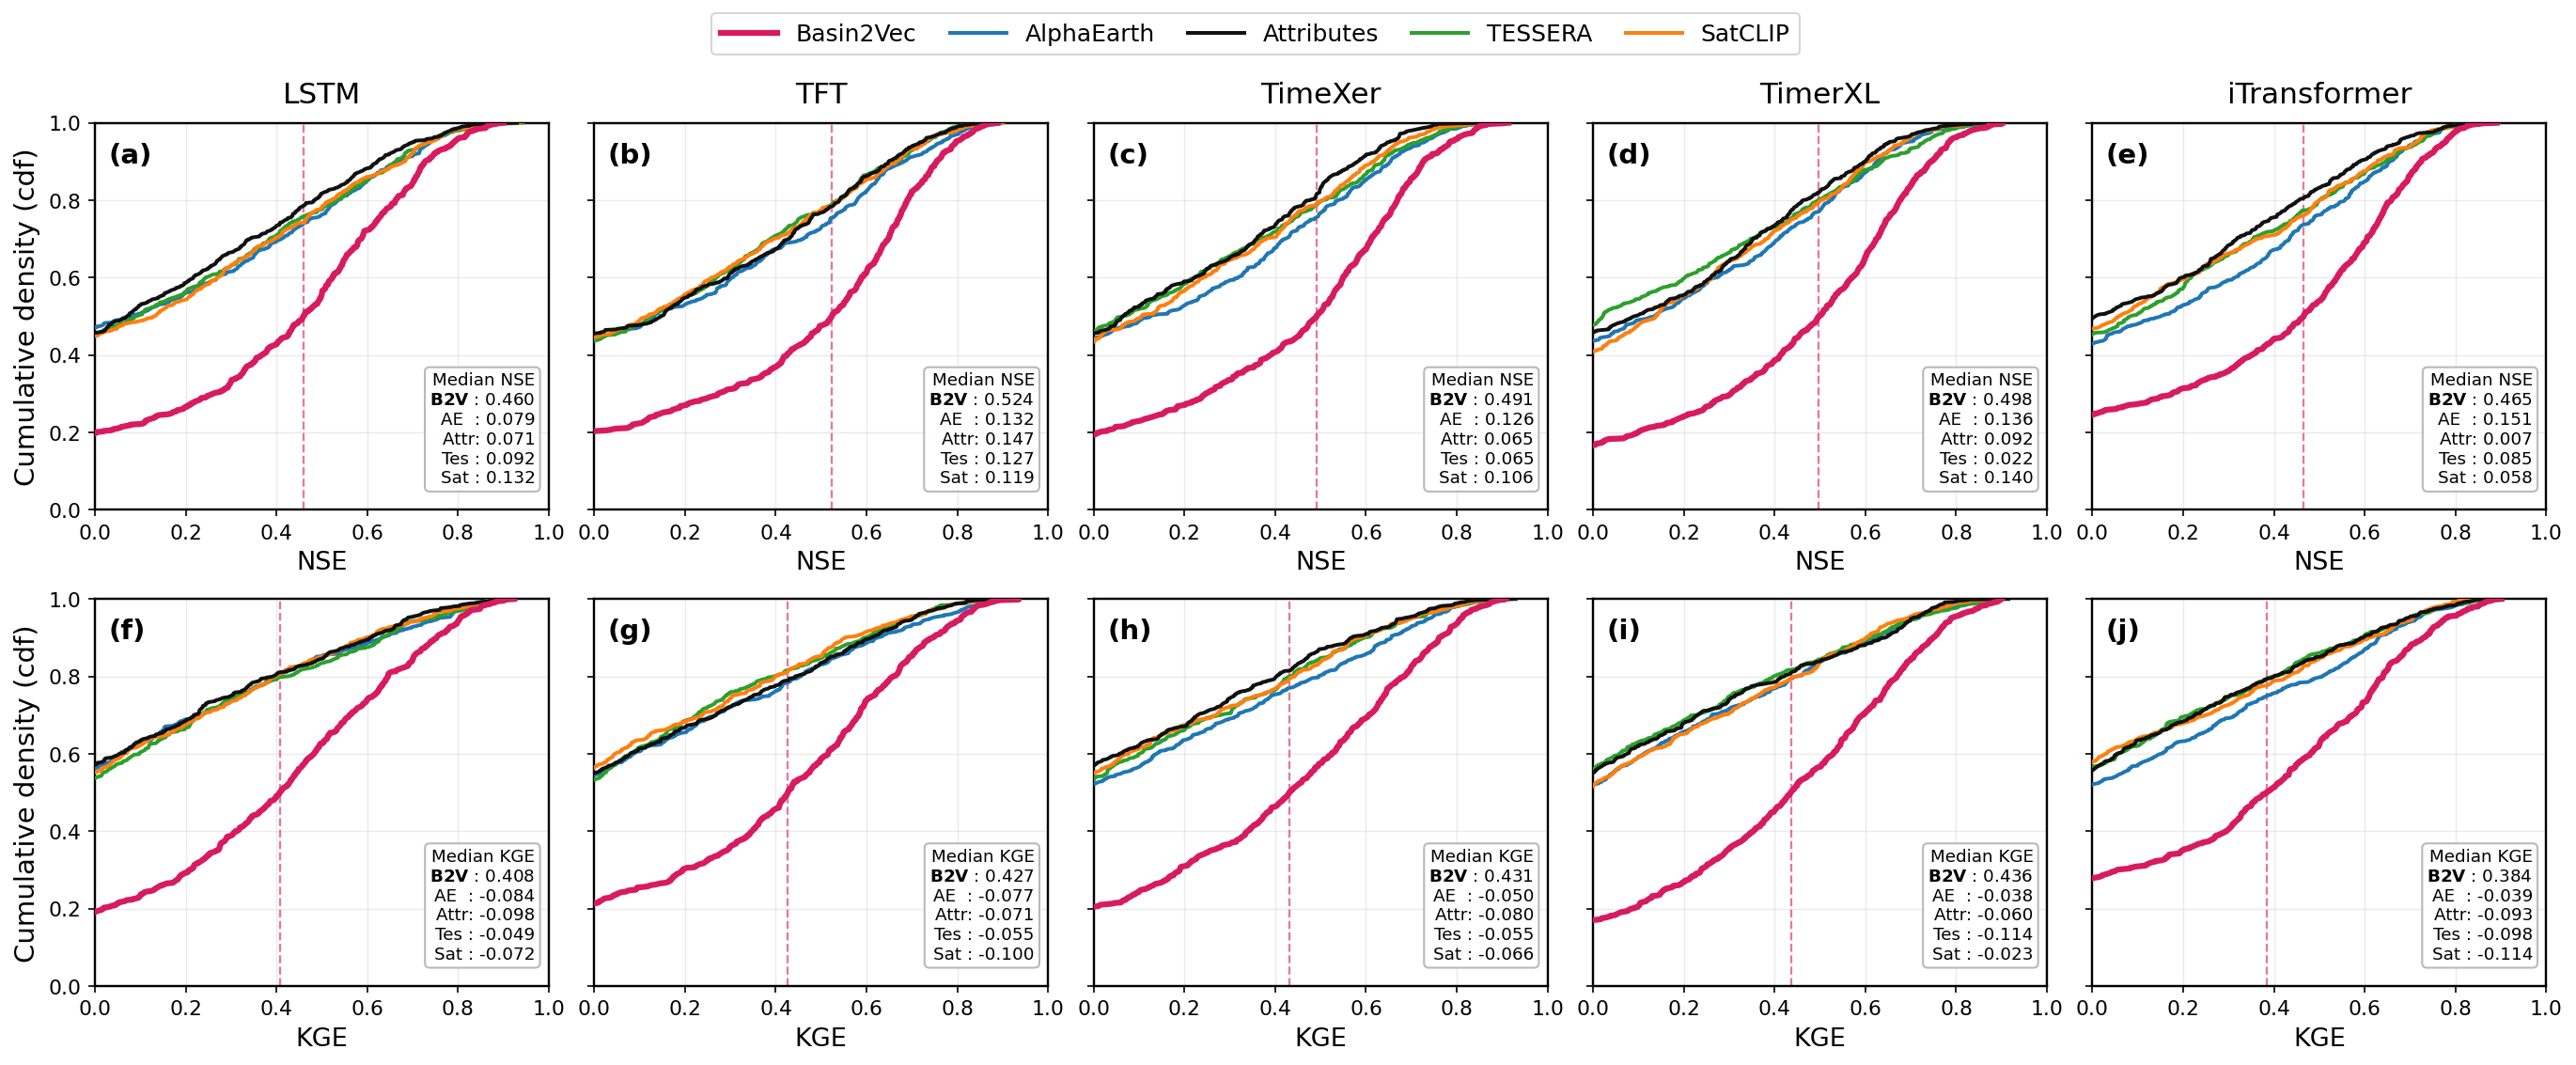

In [4]:
#!/usr/bin/env python3
# ==========================================================
# Spatial split per-basin CDF plots for unseen basins
#
# Layout:
#   2 rows x 5 columns
#   rows    = metrics [NSE, KGE]
#   columns = models [lstm, tft, timexer, timerxl, itransformer]
#   lines   = static sources [basin2vec, alphaearth, attributes, tessera, satclip]
#
# Fixed:
#   seq_len = 365
#   horizon = 1
#   lead = 0
#
# Expected input structure:
#   evaluation_outputs/camels_671_kratzert_style_ungauged_kfold_optionA_basin2vec_aggregated/
#       fold00_lstm_basin2vec_seq365_lead0_horizon1_camels671_kratzert_optionA/
#           test_per_basin_metrics_horizon1.csv
#       fold01_lstm_basin2vec_seq365_lead0_horizon1_camels671_kratzert_optionA/
#           test_per_basin_metrics_horizon1.csv
#       ...
#
# Outputs:
#   cdf_figures/
#       fig_spatial_per_basin_NSE_KGE_cdf_seq365.png
#       fig_spatial_per_basin_NSE_KGE_cdf_seq365.pdf
#       cdf_input_counts_spatial_NSE_KGE_seq365.csv
# ==========================================================

from __future__ import annotations

from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


# ==========================================================
# CONFIG
# ==========================================================

RESULTS_ROOT = Path(
    "evaluation_outputs/camels_671_kratzert_style_ungauged_kfold_optionA_basin2vec_aggregated"
)

OUT_DIR = RESULTS_ROOT / "cdf_figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)

HORIZON = 1
LEAD = 0
SEQ_LEN = 365

PLOT_METRICS = ["NSE", "KGE"]

MODEL_ORDER = [
    "lstm",
    "tft",
    "timexer",
    "timerxl",
    "itransformer"
]

MODEL_LABELS = {
    "lstm": "LSTM",
    "tft": "TFT",
    "timexer": "TimeXer",
    "timerxl": "TimerXL",
    "itransformer": "iTransformer",
}

STATIC_ORDER = [
    "basin2vec",
    "alphaearth",
    "attributes",
    "tessera",
    "satclip",
]

STATIC_LABELS = {
    "basin2vec": "Basin2Vec",
    "alphaearth": "AlphaEarth",
    "attributes": "Attributes",
    "tessera": "TESSERA",
    "satclip": "SatCLIP",
}

STATIC_SHORT = {
    "basin2vec": "B2V",
    "alphaearth": "AE",
    "attributes": "Attr",
    "tessera": "Tes",
    "satclip": "Sat",
}

STATIC_STYLES = {
    "basin2vec": {
        "color": "#D81B60",
        "linewidth": 3.0,
        "linestyle": "-",
        "zorder": 10,
    },
    "alphaearth": {
        "color": "#1F77B4",
        "linewidth": 1.9,
        "linestyle": "-",
        "zorder": 5,
    },
    "attributes": {
        "color": "#111111",
        "linewidth": 1.9,
        "linestyle": "-",
        "zorder": 6,
    },
    "tessera": {
        "color": "#2CA02C",
        "linewidth": 1.9,
        "linestyle": "-",
        "zorder": 5,
    },
    "satclip": {
        "color": "#FF7F0E",
        "linewidth": 1.9,
        "linestyle": "-",
        "zorder": 5,
    },
}

# Main-paper clean range.
# For appendix, you may use (-1.0, 1.0) for NSE/KGE to show failed basins.
XLIMS = {
    "NSE": (0.0, 1.0),
    "KGE": (0.0, 1.0),
}

Y_LIM = (0.0, 1.0)

MIN_BASINS_TO_PLOT = 5
SAVE_DPI = 300


# ==========================================================
# MATPLOTLIB STYLE
# ==========================================================

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": SAVE_DPI,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 13,
    "xtick.labelsize": 10.5,
    "ytick.labelsize": 10.5,
    "legend.fontsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.7,
    "axes.spines.top": True,
    "axes.spines.right": True,
})


# ==========================================================
# HELPERS
# ==========================================================

def normalize_name(x: str) -> str:
    x = str(x).strip().lower()

    if x in {"itransformer", "itransformer".lower(), "itransformer"}:
        return "itransformer"
    if x in {"iTransformer".lower(), "itransformer"}:
        return "itransformer"
    if x in {"b2v", "basin2vec"}:
        return "basin2vec"
    if x in {"ae", "alphaearth", "alpha_earth"}:
        return "alphaearth"
    if x in {"attr", "attribute", "attributes"}:
        return "attributes"
    if x in {"satclip", "satclip-8point", "satclip_8point"}:
        return "satclip"
    if x in {"tessera", "tessera_8point"}:
        return "tessera"

    return x


def parse_spatial_experiment_name(path: Path):
    """
    Parse folder name:
        fold00_lstm_basin2vec_seq365_lead0_horizon1_camels671_kratzert_optionA
    """
    name = path.name

    pat = (
        r"fold(?P<fold>\d+)_"
        r"(?P<model>.+?)_"
        r"(?P<static>.+?)_"
        r"seq(?P<seq>\d+)_"
        r"lead(?P<lead>\d+)_"
        r"horizon(?P<horizon>\d+)"
    )

    m = re.match(pat, name)

    if m is None:
        return {}

    return {
        "fold_id": int(m.group("fold")),
        "model_name": normalize_name(m.group("model")),
        "static_source": normalize_name(m.group("static")),
        "seq_len": int(m.group("seq")),
        "lead": int(m.group("lead")),
        "horizon": int(m.group("horizon")),
    }


def find_per_basin_metric_files(results_root: Path, horizon: int = 1):
    pattern = f"**/test_per_basin_metrics_horizon{horizon}.csv"
    return sorted(results_root.glob(pattern))


def load_all_spatial_per_basin_metrics(results_root: Path):
    files = find_per_basin_metric_files(results_root, horizon=HORIZON)

    if len(files) == 0:
        raise FileNotFoundError(
            f"No test_per_basin_metrics_horizon{HORIZON}.csv files found under:\n"
            f"  {results_root.resolve()}"
        )

    rows = []

    for f in files:
        try:
            df = pd.read_csv(f)
        except Exception as e:
            print(f"[skip] Could not read {f}: {e}")
            continue

        if df.empty:
            print(f"[skip] Empty file: {f}")
            continue

        fallback = parse_spatial_experiment_name(f.parent)

        for col, val in fallback.items():
            if col not in df.columns:
                df[col] = val

        required = [
            "fold_id",
            "model_name",
            "static_source",
            "seq_len",
            "horizon",
            "lead",
            "site_id",
        ] + PLOT_METRICS

        missing = [c for c in required if c not in df.columns]
        if missing:
            print(f"[skip] Missing columns {missing}: {f}")
            continue

        df["fold_id"] = pd.to_numeric(df["fold_id"], errors="coerce").astype("Int64")
        df["model_name"] = df["model_name"].map(normalize_name)
        df["static_source"] = df["static_source"].map(normalize_name)
        df["seq_len"] = pd.to_numeric(df["seq_len"], errors="coerce").astype("Int64")
        df["horizon"] = pd.to_numeric(df["horizon"], errors="coerce").astype("Int64")
        df["lead"] = pd.to_numeric(df["lead"], errors="coerce").astype("Int64")
        df["site_id"] = df["site_id"].astype(str)

        for metric in PLOT_METRICS:
            df[metric] = pd.to_numeric(df[metric], errors="coerce")

        df["source_file"] = str(f)
        rows.append(df)

    if len(rows) == 0:
        raise RuntimeError("No usable spatial per-basin metric files were loaded.")

    all_df = pd.concat(rows, ignore_index=True)

    all_df = all_df[
        (all_df["horizon"].astype(float) == float(HORIZON)) &
        (all_df["lead"].astype(float) == float(LEAD)) &
        (all_df["seq_len"].astype(float) == float(SEQ_LEN))
    ].copy()

    all_df = all_df[all_df["model_name"].isin(MODEL_ORDER)].copy()
    all_df = all_df[all_df["static_source"].isin(STATIC_ORDER)].copy()

    all_df = all_df.replace([np.inf, -np.inf], np.nan)

    # Prevent duplicate CDF weights if rerun folders or copied files exist.
    dedup_cols = [
        "fold_id",
        "model_name",
        "static_source",
        "seq_len",
        "horizon",
        "lead",
        "site_id",
    ]

    before = len(all_df)
    all_df = all_df.drop_duplicates(subset=dedup_cols, keep="last").copy()
    after = len(all_df)

    if before != after:
        print(f"[dedup] Dropped {before - after} duplicate per-basin rows.")

    return all_df


def empirical_cdf(values: np.ndarray):
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.array([]), np.array([])

    x = np.sort(values)
    y = np.arange(1, len(x) + 1, dtype=float) / float(len(x))

    return x, y


def get_metric_values(
    df: pd.DataFrame,
    model: str,
    static: str,
    metric: str,
):
    sub = df[
        (df["model_name"] == model) &
        (df["static_source"] == static)
    ].copy()

    values = sub[metric].to_numpy(dtype=float)
    values = values[np.isfinite(values)]

    return values


def get_n_folds(df: pd.DataFrame, model: str, static: str):
    sub = df[
        (df["model_name"] == model) &
        (df["static_source"] == static)
    ].copy()

    if len(sub) == 0:
        return 0

    return int(sub["fold_id"].nunique())


def make_counts_summary(df: pd.DataFrame):
    rows = []

    for model in MODEL_ORDER:
        for static in STATIC_ORDER:
            n_folds = get_n_folds(df, model, static)

            row = {
                "seq_len": int(SEQ_LEN),
                "model_name": model,
                "static_source": static,
                "n_folds": int(n_folds),
            }

            for metric in PLOT_METRICS:
                values = get_metric_values(df, model, static, metric)

                row[f"n_basins_valid_{metric}"] = int(len(values))
                row[f"median_{metric}"] = float(np.nanmedian(values)) if len(values) else np.nan
                row[f"mean_{metric}"] = float(np.nanmean(values)) if len(values) else np.nan
                row[f"q25_{metric}"] = float(np.nanquantile(values, 0.25)) if len(values) else np.nan
                row[f"q75_{metric}"] = float(np.nanquantile(values, 0.75)) if len(values) else np.nan
                row[f"frac_{metric}_gt_0"] = float(np.mean(values > 0.0)) if len(values) else np.nan
                row[f"frac_{metric}_gt_0_5"] = float(np.mean(values > 0.5)) if len(values) else np.nan
                row[f"frac_{metric}_gt_0_7"] = float(np.mean(values > 0.7)) if len(values) else np.nan

            rows.append(row)

    out = pd.DataFrame(rows)

    out_path = OUT_DIR / f"cdf_input_counts_spatial_NSE_KGE_seq{SEQ_LEN}.csv"
    out.to_csv(out_path, index=False)

    print(f"Saved counts summary: {out_path}")

    return out


def build_median_box_text(df: pd.DataFrame, model: str, metric: str):
    """
    Build small median metric box.

    B2V is bolded using matplotlib mathtext.
    """
    lines = [f"Median {metric}"]

    for static in STATIC_ORDER:
        vals = get_metric_values(df, model, static, metric)

        if len(vals) >= MIN_BASINS_TO_PLOT:
            med = float(np.nanmedian(vals))

            if static == "basin2vec":
                lines.append(r"$\mathbf{B2V}$" + f" : {med:.3f}")
            else:
                lines.append(f"{STATIC_SHORT[static]:<4}: {med:.3f}")

    return "\n".join(lines)


def annotate_missing(ax, text="No data"):
    ax.text(
        0.5,
        0.5,
        text,
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=13,
        color="0.45",
    )


# ==========================================================
# PLOTTING
# ==========================================================

def plot_cdf_grid(df: pd.DataFrame):
    n_rows = len(PLOT_METRICS)
    n_cols = len(MODEL_ORDER)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(18.5, 7.8),
        sharex=False,
        sharey=True,
        facecolor="white",
    )

    if n_rows == 1:
        axes = np.expand_dims(axes, axis=0)

    legend_handles = {}
    legend_labels = {}

    for r, metric in enumerate(PLOT_METRICS):
        for c, model in enumerate(MODEL_ORDER):
            ax = axes[r, c]

            any_line = False

            for static in STATIC_ORDER:
                values = get_metric_values(
                    df=df,
                    model=model,
                    static=static,
                    metric=metric,
                )

                if len(values) < MIN_BASINS_TO_PLOT:
                    continue

                x, y = empirical_cdf(values)
                style = STATIC_STYLES[static].copy()

                line, = ax.plot(
                    x,
                    y,
                    label=STATIC_LABELS[static],
                    **style,
                )

                any_line = True

                if static not in legend_handles:
                    legend_handles[static] = line
                    legend_labels[static] = STATIC_LABELS[static]

            ax.set_xlim(*XLIMS.get(metric, (0.0, 0.85)))
            ax.set_ylim(*Y_LIM)

            ax.grid(True, alpha=0.25, linewidth=0.7)

            for spine in ax.spines.values():
                spine.set_linewidth(1.15)

            # Column titles only on top row
            if r == 0:
                ax.set_title(
                    MODEL_LABELS.get(model, model),
                    fontsize=15,
                    pad=10,
                )

            # Row labels
            if c == 0:
                ax.set_ylabel(
                    f"Cumulative density (cdf)",
                    fontsize=14,
                )

            # X-axis label
            ax.set_xlabel(metric, fontsize=13)

            # Basin2Vec median vertical line for the current metric
            b2v_vals = get_metric_values(
                df=df,
                model=model,
                static="basin2vec",
                metric=metric,
            )

            if len(b2v_vals) >= MIN_BASINS_TO_PLOT:
                med = float(np.nanmedian(b2v_vals))
                ax.axvline(
                    med,
                    color=STATIC_STYLES["basin2vec"]["color"],
                    linestyle="--",
                    linewidth=1.1,
                    alpha=0.60,
                    zorder=2,
                )

            # Panel label
            panel_label = chr(ord("a") + r * n_cols + c)
            ax.text(
                0.03,
                0.95,
                f"({panel_label})",
                transform=ax.transAxes,
                fontsize=14,
                fontweight="bold",
                ha="left",
                va="top",
            )

            if any_line:
                box_text = build_median_box_text(df, model, metric)

                ax.text(
                    0.97,
                    0.06,
                    box_text,
                    transform=ax.transAxes,
                    ha="right",
                    va="bottom",
                    fontsize=8.8,
                    bbox=dict(
                        boxstyle="round,pad=0.28",
                        facecolor="white",
                        edgecolor="0.70",
                        alpha=0.92,
                    ),
                )
            else:
                annotate_missing(ax)

    # Shared legend, close to plots
    handles = [legend_handles[s] for s in STATIC_ORDER if s in legend_handles]
    labels = [legend_labels[s] for s in STATIC_ORDER if s in legend_labels]

    if handles:
        fig.legend(
            handles,
            labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.985),
            ncol=len(handles),
            frameon=True,
            fontsize=12,
            columnspacing=1.4,
            handlelength=2.4,
        )

    # No figure title for paper-ready version
    fig.subplots_adjust(
        left=0.055,
        right=0.995,
        bottom=0.09,
        top=0.875,
        wspace=0.10,
        hspace=0.23,
    )

    out_png = OUT_DIR / f"fig_spatial_per_basin_NSE_KGE_cdf_seq{SEQ_LEN}.png"
    out_pdf = OUT_DIR / f"fig_spatial_per_basin_NSE_KGE_cdf_seq{SEQ_LEN}.pdf"

    fig.savefig(out_png, dpi=SAVE_DPI, bbox_inches="tight")
    fig.savefig(out_pdf, dpi=SAVE_DPI, bbox_inches="tight")

    print(f"Saved: {out_png}")
    print(f"Saved: {out_pdf}")

    plt.show()


# ==========================================================
# MAIN
# ==========================================================

def main():
    print("=" * 80)
    print("Spatial split per-basin NSE/KGE CDF plot")
    print("=" * 80)
    print("RESULTS_ROOT:", RESULTS_ROOT.resolve())
    print("SEQ_LEN:", SEQ_LEN)
    print("PLOT_METRICS:", PLOT_METRICS)
    print("MODEL_ORDER:", MODEL_ORDER)
    print("STATIC_ORDER:", STATIC_ORDER)

    df = load_all_spatial_per_basin_metrics(RESULTS_ROOT)

    print("\nLoaded per-basin rows:", len(df))
    print("Models found:", sorted(df["model_name"].dropna().unique().tolist()))
    print("Static sources found:", sorted(df["static_source"].dropna().unique().tolist()))
    print("Seq lengths found:", sorted(df["seq_len"].dropna().astype(int).unique().tolist()))
    print("Folds found:", sorted(df["fold_id"].dropna().astype(int).unique().tolist()))

    counts = make_counts_summary(df)

    print("\nCounts / medians summary:")
    print(counts.to_string(index=False))

    plot_cdf_grid(df)


if __name__ == "__main__":
    main()

In [2]:
#!/usr/bin/env python3
# ==========================================================
# Plot spatial-split performance by basin-size class
#
# Reads:
#   - test_per_basin_metrics_horizon*.csv from spatial eval folders
#   - basin metadata parquet for basin area
#
# Outputs:
#   - area_class_summary.csv
#   - grouped boxplots for NSE/KGE by basin-size class
# ==========================================================

from __future__ import annotations

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# ==========================================================
# PATHS
# ==========================================================

RESULTS_ROOT = Path(
    "evaluation_outputs/camels_671_kratzert_style_ungauged_kfold_optionA_basin2vec_aggregated"
)

BASIN_METADATA = Path(
    "/data/basin2vec/cache/metadata/basin_metadata.parquet"
)

OUT_DIR = RESULTS_ROOT / "area_class_plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)


# ==========================================================
# FILTERS
# ==========================================================

SEQ_LEN = 365
HORIZON = 1
LEAD = 0

# Use None to include all available models.
# MODEL_FILTER = None
MODEL_FILTER = ["tft"]

STATIC_ORDER = [
    "basin2vec",
    "alphaearth",
    "tessera",
    "satclip",
    "attributes",
]

STATIC_LABELS = {
    "basin2vec": "Basin2Vec",
    "alphaearth": "AlphaEarth",
    "tessera": "TESSERA",
    "satclip": "SatCLIP",
    "attributes": "Attributes",
}

# Keep consistent with the paper-style colors.
STATIC_COLORS = {
    "basin2vec": "#4a86c5",   # blue
    "alphaearth": "#e07a5f",  # orange
    "tessera": "#59a14f",     # green
    "satclip": "#b07aa1",     # purple
    "attributes": "#8c8c8c",  # gray
}

METRICS = ["NSE", "KGE"]

# Use quartiles for balanced class sizes.
N_AREA_CLASSES = 3

# Hide extreme failed-basin tails in the plot, but keep all values in summary CSV.
SHOW_FLIERS = False
Y_LIMITS = {
    "NSE": (-1.0, 1.0),
    "KGE": (-1.0, 1.0),
}


# ==========================================================
# STYLE
# ==========================================================

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linewidth": 0.60,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
})


# ==========================================================
# HELPERS
# ==========================================================

def normalize_site_id(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if s.endswith(".0"):
        s = s[:-2]
    digits = re.sub(r"\D", "", s)
    if not digits:
        return None
    return digits.zfill(8) if len(digits) <= 8 else digits


def infer_site_id_column(df):
    candidates = [
        "site_id", "siteid", "gage_id", "gauge_id", "station_id",
        "staid", "site_no", "usgs_id", "basin_id", "GAGE_ID", "STAID",
    ]
    lower = {str(c).lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in lower:
            return lower[c.lower()]
    raise RuntimeError(
        f"Could not infer site_id column. Available columns: {df.columns.tolist()[:50]}"
    )


def infer_area_column(df):
    candidates = [
        "area_km2",
        "basin_area_km2",
        "drainage_area_km2",
        "area_gages2",
        "area_geospa_fabric",
        "area",
        "AREA",
    ]
    lower = {str(c).lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in lower:
            return lower[c.lower()], "raw_area"

    # If raw area is unavailable, use log-area or standardized log-area for quantile classes.
    fallback_candidates = [
        "log_area_km2",
        "log_area_km2_z",
    ]
    for c in fallback_candidates:
        if c.lower() in lower:
            return lower[c.lower()], "log_or_standardized_area"

    raise RuntimeError(
        "Could not find an area column. Expected raw area such as area_km2, "
        "area_gages2, or fallback log_area_km2/log_area_km2_z."
    )


def load_area_metadata(path):
    meta = pd.read_parquet(path).copy()

    site_col = infer_site_id_column(meta)
    area_col, area_mode = infer_area_column(meta)

    out = meta[[site_col, area_col]].copy()
    out = out.rename(columns={site_col: "site_id", area_col: "area_value"})
    out["site_id"] = out["site_id"].apply(normalize_site_id)
    out["area_value"] = pd.to_numeric(out["area_value"], errors="coerce")

    out = out.dropna(subset=["site_id", "area_value"]).copy()
    out = out[np.isfinite(out["area_value"])].copy()
    out = out.drop_duplicates("site_id", keep="first").reset_index(drop=True)

    print(f"Loaded area metadata: {len(out)} basins")
    print(f"Area column: {area_col}")
    print(f"Area mode: {area_mode}")

    return out, area_col, area_mode


def load_per_basin_metrics(results_root):
    files = sorted(results_root.rglob("test_per_basin_metrics_horizon*.csv"))

    if not files:
        raise FileNotFoundError(
            f"No test_per_basin_metrics_horizon*.csv files found under {results_root}"
        )

    rows = []

    for f in files:
        try:
            df = pd.read_csv(f)
            df["source_file"] = str(f)
            rows.append(df)
        except Exception as e:
            print(f"Skipping unreadable file: {f} | {e}")

    if not rows:
        raise RuntimeError("No readable per-basin metric files found.")

    out = pd.concat(rows, ignore_index=True)

    if "site_id" not in out.columns:
        raise RuntimeError("Per-basin metrics must contain site_id.")

    out["site_id"] = out["site_id"].apply(normalize_site_id)

    print(f"Loaded per-basin metric rows: {len(out)}")
    print(f"Files read: {len(files)}")
    print("Static sources:", sorted(out["static_source"].dropna().unique()))
    print("Models:", sorted(out["model_name"].dropna().unique()))

    return out


def add_area_classes(df, n_classes=4):
    df = df.copy()

    valid = df["area_value"].notna() & np.isfinite(df["area_value"])
    df = df.loc[valid].copy()

    # Balanced classes by quantiles.
    class_ids = pd.qcut(
        df["area_value"],
        q=n_classes,
        labels=False,
        duplicates="drop",
    )

    df["area_class_id"] = class_ids.astype(int)

    class_info = (
        df[["area_class_id", "area_value"]]
        .drop_duplicates()
        .groupby("area_class_id")["area_value"]
        .agg(["min", "max"])
        .reset_index()
    )

    labels = {}
    names_4 = ["Small", "Medium-small", "Medium-large", "Large"]
    names_3 = ["Small", "Medium", "Large"]

    names = names_4 if n_classes == 4 else names_3

    for _, row in class_info.iterrows():
        cid = int(row["area_class_id"])
        name = names[cid] if cid < len(names) else f"Class {cid + 1}"

        lo = float(row["min"])
        hi = float(row["max"])

        # If area is raw km2, these labels are meaningful.
        # If area_value is standardized log-area, labels still define ordered size classes.
        labels[cid] = f"{name}\nQ{cid + 1}"

    df["area_class"] = df["area_class_id"].map(labels)

    order = [
        labels[cid]
        for cid in sorted(labels)
    ]

    return df, order


def summarize_by_area_class(df, out_path):
    group_cols = [
        "model_name",
        "static_source",
        "seq_len",
        "horizon",
        "lead",
        "area_class_id",
        "area_class",
    ]

    metric_cols = [m for m in METRICS if m in df.columns]

    rows = []

    for keys, sub in df.groupby(group_cols, dropna=False):
        row = dict(zip(group_cols, keys))
        row["n_rows"] = int(len(sub))
        row["n_basins"] = int(sub["site_id"].nunique())

        for m in metric_cols:
            vals = pd.to_numeric(sub[m], errors="coerce")
            vals = vals[np.isfinite(vals)]
            row[f"median_{m}"] = float(vals.median()) if len(vals) else np.nan
            row[f"mean_{m}"] = float(vals.mean()) if len(vals) else np.nan
            row[f"q25_{m}"] = float(vals.quantile(0.25)) if len(vals) else np.nan
            row[f"q75_{m}"] = float(vals.quantile(0.75)) if len(vals) else np.nan

        rows.append(row)

    summary = pd.DataFrame(rows)
    summary = summary.sort_values(
        ["model_name", "seq_len", "horizon", "lead", "area_class_id", "static_source"]
    )
    summary.to_csv(out_path, index=False)
    print(f"Saved summary: {out_path}")
    return summary


def clean_for_plot(df, metric):
    d = df.copy()
    d[metric] = pd.to_numeric(d[metric], errors="coerce")
    d = d[np.isfinite(d[metric])].copy()
    return d


def plot_metric_boxplot(df, metric, model_name, area_order, out_prefix):
    d = clean_for_plot(df, metric)

    d = d[d["model_name"] == model_name].copy()

    if d.empty:
        print(f"No data for model={model_name}, metric={metric}")
        return

    static_sources = [
        s for s in STATIC_ORDER
        if s in set(d["static_source"].unique())
    ]

    if not static_sources:
        print(f"No requested static sources found for model={model_name}")
        return

    fig, ax = plt.subplots(figsize=(7.2, 3.4), facecolor="white")

    n_classes = len(area_order)
    n_sources = len(static_sources)

    centers = np.arange(n_classes)
    total_width = 0.76
    box_width = total_width / max(n_sources, 1)

    offsets = (
        np.arange(n_sources) - (n_sources - 1) / 2.0
    ) * box_width

    for j, source in enumerate(static_sources):
        data = []
        positions = []

        for i, area_class in enumerate(area_order):
            vals = d[
                (d["area_class"] == area_class)
                & (d["static_source"] == source)
            ][metric].dropna().to_numpy(dtype=float)

            if len(vals) == 0:
                vals = np.array([np.nan])

            data.append(vals)
            positions.append(centers[i] + offsets[j])

        bp = ax.boxplot(
            data,
            positions=positions,
            widths=box_width * 0.82,
            patch_artist=True,
            showfliers=SHOW_FLIERS,
            whis=(5, 95),
            medianprops={
                "color": "black",
                "linewidth": 1.25,
            },
            boxprops={
                "linewidth": 0.75,
                "edgecolor": "black",
            },
            whiskerprops={
                "linewidth": 0.75,
                "color": "black",
            },
            capprops={
                "linewidth": 0.75,
                "color": "black",
            },
        )

        color = STATIC_COLORS.get(source, "#999999")

        for patch in bp["boxes"]:
            patch.set_facecolor(color)
            patch.set_alpha(0.72)

    # Add counts under x-axis labels.
    counts = (
        d.groupby("area_class")["site_id"]
        .nunique()
        .reindex(area_order)
        .fillna(0)
        .astype(int)
    )

    xtick_labels = [
        f"{label}\n$n$={counts.loc[label]}"
        for label in area_order
    ]

    ax.set_xticks(centers)
    ax.set_xticklabels(xtick_labels)
    ax.set_xlabel("Basin-size class")
    ax.set_ylabel(metric)

    ax.axhline(0.0, color="0.35", linewidth=0.8, linestyle="--", alpha=0.7)

    if metric in Y_LIMITS and Y_LIMITS[metric] is not None:
        ax.set_ylim(*Y_LIMITS[metric])

    model_title = model_name.upper() if model_name.lower() == "lstm" else model_name
    ax.set_title(f"{model_title}: {metric} by basin-size class")

    handles = [
        Patch(
            facecolor=STATIC_COLORS.get(s, "#999999"),
            edgecolor="black",
            alpha=0.72,
            label=STATIC_LABELS.get(s, s),
        )
        for s in static_sources
    ]

    ax.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.23),
        ncol=len(handles),
        frameon=True,
        columnspacing=1.1,
        handlelength=1.4,
        handletextpad=0.45,
    )

    ax.grid(True, axis="y", alpha=0.22, linewidth=0.60)
    ax.grid(False, axis="x")

    for spine in ax.spines.values():
        spine.set_linewidth(0.85)

    fig.subplots_adjust(
        left=0.085,
        right=0.985,
        bottom=0.22,
        top=0.78,
    )

    out_png = OUT_DIR / f"{out_prefix}_{model_name}_{metric}_area_class_boxplot.png"
    out_pdf = OUT_DIR / f"{out_prefix}_{model_name}_{metric}_area_class_boxplot.pdf"

    fig.savefig(out_png, dpi=300, facecolor="white", bbox_inches="tight")
    fig.savefig(out_pdf, dpi=300, facecolor="white", bbox_inches="tight")

    print(f"Saved: {out_png}")
    print(f"Saved: {out_pdf}")

    plt.close(fig)


def plot_metric_panel(df, model_name, area_order, out_prefix):
    available_metrics = [m for m in METRICS if m in df.columns]

    if not available_metrics:
        print("No requested metrics available.")
        return

    d_model = df[df["model_name"] == model_name].copy()

    if d_model.empty:
        print(f"No data for model={model_name}")
        return

    static_sources = [
        s for s in STATIC_ORDER
        if s in set(d_model["static_source"].unique())
    ]

    if not static_sources:
        print(f"No requested static sources for model={model_name}")
        return

    fig, axes = plt.subplots(
        1,
        len(available_metrics),
        figsize=(7.2, 3.35),
        sharex=True,
        facecolor="white",
    )

    if len(available_metrics) == 1:
        axes = [axes]

    n_classes = len(area_order)
    n_sources = len(static_sources)
    centers = np.arange(n_classes)
    total_width = 0.76
    box_width = total_width / max(n_sources, 1)
    offsets = (
        np.arange(n_sources) - (n_sources - 1) / 2.0
    ) * box_width

    for ax, metric in zip(axes, available_metrics):
        d = clean_for_plot(d_model, metric)

        for j, source in enumerate(static_sources):
            data = []
            positions = []

            for i, area_class in enumerate(area_order):
                vals = d[
                    (d["area_class"] == area_class)
                    & (d["static_source"] == source)
                ][metric].dropna().to_numpy(dtype=float)

                if len(vals) == 0:
                    vals = np.array([np.nan])

                data.append(vals)
                positions.append(centers[i] + offsets[j])

            bp = ax.boxplot(
                data,
                positions=positions,
                widths=box_width * 0.82,
                patch_artist=True,
                showfliers=SHOW_FLIERS,
                whis=(5, 95),
                medianprops={"color": "black", "linewidth": 1.15},
                boxprops={"linewidth": 0.7, "edgecolor": "black"},
                whiskerprops={"linewidth": 0.7, "color": "black"},
                capprops={"linewidth": 0.7, "color": "black"},
            )

            color = STATIC_COLORS.get(source, "#999999")
            for patch in bp["boxes"]:
                patch.set_facecolor(color)
                patch.set_alpha(0.72)

        ax.axhline(0.0, color="0.35", linewidth=0.8, linestyle="--", alpha=0.7)

        if metric in Y_LIMITS and Y_LIMITS[metric] is not None:
            ax.set_ylim(*Y_LIMITS[metric])

        ax.set_ylabel(metric)
        ax.grid(True, axis="y", alpha=0.22, linewidth=0.60)
        ax.grid(False, axis="x")

        for spine in ax.spines.values():
            spine.set_linewidth(0.85)

    counts = (
        d_model.groupby("area_class")["site_id"]
        .nunique()
        .reindex(area_order)
        .fillna(0)
        .astype(int)
    )

    xtick_labels = [
        f"{label}\n$n$={counts.loc[label]}"
        for label in area_order
    ]

    for ax in axes:
        ax.set_xticks(centers)
        ax.set_xticklabels(xtick_labels)
        ax.set_xlabel("Basin-size class")

    handles = [
        Patch(
            facecolor=STATIC_COLORS.get(s, "#999999"),
            edgecolor="black",
            alpha=0.72,
            label=STATIC_LABELS.get(s, s),
        )
        for s in static_sources
    ]

    fig.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.99),
        ncol=len(handles),
        frameon=True,
        fontsize=8.8,
        columnspacing=1.0,
        handlelength=1.3,
        handletextpad=0.4,
    )

    model_title = model_name.upper() if model_name.lower() == "lstm" else model_name
    # fig.suptitle(
    #     f"{model_title}: spatial performance by basin-size class",
    #     fontsize=12.5,
    #     y=1.13,
    # )

    fig.subplots_adjust(
        left=0.075,
        right=0.985,
        bottom=0.24,
        top=0.88,
        wspace=0.22,
    )

    out_png = OUT_DIR / f"{out_prefix}_{model_name}_NSE_KGE_area_class_boxplot_panel.png"
    out_pdf = OUT_DIR / f"{out_prefix}_{model_name}_NSE_KGE_area_class_boxplot_panel.pdf"

    fig.savefig(out_png, dpi=300, facecolor="white", bbox_inches="tight")
    fig.savefig(out_pdf, dpi=300, facecolor="white", bbox_inches="tight")

    print(f"Saved: {out_png}")
    print(f"Saved: {out_pdf}")

    plt.close(fig)


# ==========================================================
# MAIN
# ==========================================================

def main():
    area_df, area_col, area_mode = load_area_metadata(BASIN_METADATA)
    metrics_df = load_per_basin_metrics(RESULTS_ROOT)

    # Standard filters.
    metrics_df = metrics_df.copy()
    metrics_df["site_id"] = metrics_df["site_id"].apply(normalize_site_id)

    if "seq_len" in metrics_df.columns:
        metrics_df = metrics_df[metrics_df["seq_len"] == SEQ_LEN].copy()

    if "horizon" in metrics_df.columns:
        metrics_df = metrics_df[metrics_df["horizon"] == HORIZON].copy()

    if "lead" in metrics_df.columns:
        metrics_df = metrics_df[metrics_df["lead"] == LEAD].copy()

    if MODEL_FILTER is not None:
        metrics_df = metrics_df[metrics_df["model_name"].isin(MODEL_FILTER)].copy()

    metrics_df = metrics_df[metrics_df["static_source"].isin(STATIC_ORDER)].copy()

    if metrics_df.empty:
        raise RuntimeError(
            "No metric rows remain after filtering. Check RESULTS_ROOT, STATIC_ORDER, "
            "MODEL_FILTER, SEQ_LEN, HORIZON, and LEAD."
        )

    df = metrics_df.merge(area_df, on="site_id", how="inner")

    if df.empty:
        raise RuntimeError("No rows matched between metrics and basin metadata.")

    df, area_order = add_area_classes(df, n_classes=N_AREA_CLASSES)

    print("\nRows after merging area metadata:", len(df))
    print("Unique basins:", df["site_id"].nunique())
    print("Area classes:", area_order)

    merged_path = OUT_DIR / "per_basin_metrics_with_area_classes.csv"
    df.to_csv(merged_path, index=False)
    print(f"Saved merged data: {merged_path}")

    summary_path = OUT_DIR / "area_class_summary.csv"
    summarize_by_area_class(df, summary_path)

    models = sorted(df["model_name"].dropna().unique())

    out_prefix = f"spatial_seq{SEQ_LEN}_H{HORIZON}_lead{LEAD}"

    for model_name in models:
        # Recommended compact paper figure: one panel with NSE and KGE.
        plot_metric_panel(
            df=df,
            model_name=model_name,
            area_order=area_order,
            out_prefix=out_prefix,
        )

        # Optional separate figures for each metric.
        for metric in METRICS:
            if metric in df.columns:
                plot_metric_boxplot(
                    df=df,
                    metric=metric,
                    model_name=model_name,
                    area_order=area_order,
                    out_prefix=out_prefix,
                )

    print("\nDone.")
    print("Output directory:", OUT_DIR)


if __name__ == "__main__":
    main()

Loaded area metadata: 9067 basins
Area column: area_km2
Area mode: raw_area
Loaded per-basin metric rows: 16775
Files read: 150
Static sources: ['alphaearth', 'attributes', 'basin2vec', 'satclip', 'tessera']
Models: ['iTransformer', 'lstm', 'tft', 'timerxl', 'timexer']

Rows after merging area metadata: 3355
Unique basins: 671
Area classes: ['Small\nQ1', 'Medium\nQ2', 'Large\nQ3']
Saved merged data: evaluation_outputs/camels_671_kratzert_style_ungauged_kfold_optionA_basin2vec_aggregated/area_class_plots/per_basin_metrics_with_area_classes.csv
Saved summary: evaluation_outputs/camels_671_kratzert_style_ungauged_kfold_optionA_basin2vec_aggregated/area_class_plots/area_class_summary.csv
Saved: evaluation_outputs/camels_671_kratzert_style_ungauged_kfold_optionA_basin2vec_aggregated/area_class_plots/spatial_seq365_H1_lead0_tft_NSE_KGE_area_class_boxplot_panel.png
Saved: evaluation_outputs/camels_671_kratzert_style_ungauged_kfold_optionA_basin2vec_aggregated/area_class_plots/spatial_seq365_H

In [1]:
#!/usr/bin/env python3
# ==========================================================
# Temporal split: performance by basin-size class
#
# Reads:
#   - val_per_basin_metrics_horizon*.csv from temporal experiment folders
#   - /data/basin2vec/cache/metadata/basin_metadata.parquet
#
# Outputs:
#   - per_basin_metrics_with_area_classes.csv
#   - area_class_summary.csv
#   - NSE/KGE boxplot panels by basin-size class
# ==========================================================

from __future__ import annotations

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch


# ==========================================================
# PATHS
# ==========================================================

RESULTS_ROOT = Path(
    "evaluation_outputs/camels_exogenous_multimodel_baselines_temporal"
)

BASIN_METADATA = Path(
    "/data/basin2vec/cache/metadata/basin_metadata.parquet"
)

OUT_DIR = RESULTS_ROOT / "area_class_plots_temporal"
OUT_DIR.mkdir(parents=True, exist_ok=True)


# ==========================================================
# FILTERS
# ==========================================================

SEQ_LEN = 365
HORIZON = 1
LEAD = 0

# Use None to include all available models.
# MODEL_FILTER = None
MODEL_FILTER = ["tft"]

STATIC_ORDER = [
    "basin2vec",
    "alphaearth",
    "tessera",
    "satclip",
    "attributes",
]

STATIC_LABELS = {
    "basin2vec": "Basin2Vec",
    "alphaearth": "AlphaEarth",
    "tessera": "TESSERA",
    "satclip": "SatCLIP",
    "attributes": "Attributes",
}

STATIC_COLORS = {
    "basin2vec": "#4a86c5",
    "alphaearth": "#e07a5f",
    "tessera": "#59a14f",
    "satclip": "#b07aa1",
    "attributes": "#8c8c8c",
}

METRICS = ["NSE", "KGE"]

# Use 4 balanced size classes by area quantiles.
N_AREA_CLASSES = 4

SHOW_FLIERS = False
Y_LIMITS = {
    "NSE": (-1.0, 1.0),
    "KGE": (-1.0, 1.0),
}


# ==========================================================
# STYLE
# ==========================================================

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.22,
    "grid.linewidth": 0.60,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
})


# ==========================================================
# HELPERS
# ==========================================================

def normalize_site_id(x):
    if pd.isna(x):
        return None

    s = str(x).strip()

    if s.endswith(".0"):
        s = s[:-2]

    digits = re.sub(r"\D", "", s)

    if not digits:
        return None

    return digits.zfill(8) if len(digits) <= 8 else digits


def infer_site_id_column(df):
    candidates = [
        "site_id", "siteid", "gage_id", "gageid", "gauge_id", "gaugeid",
        "station_id", "staid", "site_no", "usgs_id", "basin_id",
        "GAGE_ID", "STAID",
    ]

    lower = {str(c).lower(): c for c in df.columns}

    for c in candidates:
        if c.lower() in lower:
            return lower[c.lower()]

    raise RuntimeError(
        f"Could not infer site ID column. Available columns: {df.columns.tolist()[:80]}"
    )


def infer_area_column(df):
    raw_candidates = [
        "area_km2",
        "basin_area_km2",
        "drainage_area_km2",
        "area_gages2",
        "area_geospa_fabric",
        "area",
        "AREA",
    ]

    lower = {str(c).lower(): c for c in df.columns}

    for c in raw_candidates:
        if c.lower() in lower:
            return lower[c.lower()], "raw_area"

    fallback_candidates = [
        "log_area_km2",
        "log_area_km2_z",
    ]

    for c in fallback_candidates:
        if c.lower() in lower:
            return lower[c.lower()], "log_or_standardized_area"

    raise RuntimeError(
        "Could not find an area column. Expected area_km2, area_gages2, "
        "area_geospa_fabric, log_area_km2, or log_area_km2_z."
    )


def load_area_metadata(path):
    meta = pd.read_parquet(path).copy()

    site_col = infer_site_id_column(meta)
    area_col, area_mode = infer_area_column(meta)

    out = meta[[site_col, area_col]].copy()
    out = out.rename(columns={site_col: "site_id", area_col: "area_value"})
    out["site_id"] = out["site_id"].apply(normalize_site_id)
    out["area_value"] = pd.to_numeric(out["area_value"], errors="coerce")

    out = out.dropna(subset=["site_id", "area_value"]).copy()
    out = out[np.isfinite(out["area_value"])].copy()
    out = out.drop_duplicates("site_id", keep="first").reset_index(drop=True)

    print(f"Loaded area metadata: {len(out)} basins")
    print(f"Area column: {area_col}")
    print(f"Area mode: {area_mode}")

    return out, area_col, area_mode


def load_temporal_per_basin_metrics(results_root):
    files = sorted(results_root.rglob("val_per_basin_metrics_horizon*.csv"))

    if not files:
        raise FileNotFoundError(
            f"No val_per_basin_metrics_horizon*.csv files found under {results_root}"
        )

    rows = []

    for f in files:
        try:
            df = pd.read_csv(f)
            df["source_file"] = str(f)
            rows.append(df)
        except Exception as e:
            print(f"Skipping unreadable file: {f} | {e}")

    if not rows:
        raise RuntimeError("No readable temporal per-basin metric files found.")

    out = pd.concat(rows, ignore_index=True)

    if "site_id" not in out.columns:
        raise RuntimeError("Per-basin metrics must contain site_id.")

    out["site_id"] = out["site_id"].apply(normalize_site_id)

    print(f"Loaded temporal per-basin metric rows: {len(out)}")
    print(f"Files read: {len(files)}")
    print("Static sources:", sorted(out["static_source"].dropna().unique()))
    print("Models:", sorted(out["model_name"].dropna().unique()))

    return out


def add_area_classes(df, n_classes=4):
    df = df.copy()

    valid = df["area_value"].notna() & np.isfinite(df["area_value"])
    df = df.loc[valid].copy()

    df["area_class_id"] = pd.qcut(
        df["area_value"],
        q=n_classes,
        labels=False,
        duplicates="drop",
    ).astype(int)

    class_info = (
        df[["area_class_id", "area_value"]]
        .drop_duplicates()
        .groupby("area_class_id")["area_value"]
        .agg(["min", "max"])
        .reset_index()
    )

    names_4 = ["Small", "Medium-small", "Medium-large", "Large"]
    names_3 = ["Small", "Medium", "Large"]
    names = names_4 if n_classes == 4 else names_3

    labels = {}

    for _, row in class_info.iterrows():
        cid = int(row["area_class_id"])
        name = names[cid] if cid < len(names) else f"Class {cid + 1}"
        labels[cid] = f"{name}\nQ{cid + 1}"

    df["area_class"] = df["area_class_id"].map(labels)

    area_order = [labels[cid] for cid in sorted(labels)]

    return df, area_order


def summarize_by_area_class(df, out_path):
    group_cols = [
        "model_name",
        "static_source",
        "seq_len",
        "horizon",
        "lead",
        "area_class_id",
        "area_class",
    ]

    metric_cols = [m for m in METRICS if m in df.columns]

    rows = []

    for keys, sub in df.groupby(group_cols, dropna=False):
        row = dict(zip(group_cols, keys))
        row["n_rows"] = int(len(sub))
        row["n_basins"] = int(sub["site_id"].nunique())

        for m in metric_cols:
            vals = pd.to_numeric(sub[m], errors="coerce")
            vals = vals[np.isfinite(vals)]

            row[f"median_{m}"] = float(vals.median()) if len(vals) else np.nan
            row[f"mean_{m}"] = float(vals.mean()) if len(vals) else np.nan
            row[f"q25_{m}"] = float(vals.quantile(0.25)) if len(vals) else np.nan
            row[f"q75_{m}"] = float(vals.quantile(0.75)) if len(vals) else np.nan

        rows.append(row)

    summary = pd.DataFrame(rows)

    summary = summary.sort_values(
        ["model_name", "seq_len", "horizon", "lead", "area_class_id", "static_source"]
    )

    summary.to_csv(out_path, index=False)
    print(f"Saved summary: {out_path}")

    return summary


def clean_for_plot(df, metric):
    d = df.copy()
    d[metric] = pd.to_numeric(d[metric], errors="coerce")
    d = d[np.isfinite(d[metric])].copy()
    return d


def plot_metric_panel(df, model_name, area_order, out_prefix):
    available_metrics = [m for m in METRICS if m in df.columns]

    if not available_metrics:
        print("No requested metrics available.")
        return

    d_model = df[df["model_name"] == model_name].copy()

    if d_model.empty:
        print(f"No data for model={model_name}")
        return

    static_sources = [
        s for s in STATIC_ORDER
        if s in set(d_model["static_source"].unique())
    ]

    if not static_sources:
        print(f"No requested static sources for model={model_name}")
        return

    fig, axes = plt.subplots(
        1,
        len(available_metrics),
        figsize=(7.2, 3.35),
        sharex=True,
        facecolor="white",
    )

    if len(available_metrics) == 1:
        axes = [axes]

    n_classes = len(area_order)
    n_sources = len(static_sources)

    centers = np.arange(n_classes)
    total_width = 0.76
    box_width = total_width / max(n_sources, 1)
    offsets = (np.arange(n_sources) - (n_sources - 1) / 2.0) * box_width

    for ax, metric in zip(axes, available_metrics):
        d = clean_for_plot(d_model, metric)

        for j, source in enumerate(static_sources):
            data = []
            positions = []

            for i, area_class in enumerate(area_order):
                vals = d[
                    (d["area_class"] == area_class)
                    & (d["static_source"] == source)
                ][metric].dropna().to_numpy(dtype=float)

                if len(vals) == 0:
                    vals = np.array([np.nan])

                data.append(vals)
                positions.append(centers[i] + offsets[j])

            bp = ax.boxplot(
                data,
                positions=positions,
                widths=box_width * 0.82,
                patch_artist=True,
                showfliers=SHOW_FLIERS,
                whis=(5, 95),
                medianprops={"color": "black", "linewidth": 1.15},
                boxprops={"linewidth": 0.7, "edgecolor": "black"},
                whiskerprops={"linewidth": 0.7, "color": "black"},
                capprops={"linewidth": 0.7, "color": "black"},
            )

            color = STATIC_COLORS.get(source, "#999999")

            for patch in bp["boxes"]:
                patch.set_facecolor(color)
                patch.set_alpha(0.72)

        ax.axhline(0.0, color="0.35", linewidth=0.8, linestyle="--", alpha=0.7)

        if metric in Y_LIMITS and Y_LIMITS[metric] is not None:
            ax.set_ylim(*Y_LIMITS[metric])

        ax.set_ylabel(metric)
        ax.grid(True, axis="y", alpha=0.22, linewidth=0.60)
        ax.grid(False, axis="x")

        for spine in ax.spines.values():
            spine.set_linewidth(0.85)

    counts = (
        d_model.groupby("area_class")["site_id"]
        .nunique()
        .reindex(area_order)
        .fillna(0)
        .astype(int)
    )

    xtick_labels = [
        f"{label}\n$n$={counts.loc[label]}"
        for label in area_order
    ]

    for ax in axes:
        ax.set_xticks(centers)
        ax.set_xticklabels(xtick_labels)
        ax.set_xlabel("Basin-size class")

    handles = [
        Patch(
            facecolor=STATIC_COLORS.get(s, "#999999"),
            edgecolor="black",
            alpha=0.72,
            label=STATIC_LABELS.get(s, s),
        )
        for s in static_sources
    ]

    fig.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=len(handles),
        frameon=True,
        fontsize=8.8,
        columnspacing=1.0,
        handlelength=1.3,
        handletextpad=0.4,
    )

    model_title = model_name.upper() if model_name.lower() == "lstm" else model_name

    fig.suptitle(
        f"{model_title}: temporal performance by basin-size class",
        fontsize=12.5,
        y=1.13,
    )

    fig.subplots_adjust(
        left=0.075,
        right=0.985,
        bottom=0.24,
        top=0.78,
        wspace=0.22,
    )

    out_png = OUT_DIR / f"{out_prefix}_{model_name}_NSE_KGE_area_class_boxplot_panel.png"
    out_pdf = OUT_DIR / f"{out_prefix}_{model_name}_NSE_KGE_area_class_boxplot_panel.pdf"

    fig.savefig(out_png, dpi=300, facecolor="white", bbox_inches="tight")
    fig.savefig(out_pdf, dpi=300, facecolor="white", bbox_inches="tight")

    print(f"Saved: {out_png}")
    print(f"Saved: {out_pdf}")

    plt.close(fig)


def plot_metric_boxplot(df, metric, model_name, area_order, out_prefix):
    d = clean_for_plot(df, metric)
    d = d[d["model_name"] == model_name].copy()

    if d.empty:
        print(f"No data for model={model_name}, metric={metric}")
        return

    static_sources = [
        s for s in STATIC_ORDER
        if s in set(d["static_source"].unique())
    ]

    if not static_sources:
        print(f"No requested static sources found for model={model_name}")
        return

    fig, ax = plt.subplots(figsize=(7.2, 3.4), facecolor="white")

    n_classes = len(area_order)
    n_sources = len(static_sources)

    centers = np.arange(n_classes)
    total_width = 0.76
    box_width = total_width / max(n_sources, 1)
    offsets = (np.arange(n_sources) - (n_sources - 1) / 2.0) * box_width

    for j, source in enumerate(static_sources):
        data = []
        positions = []

        for i, area_class in enumerate(area_order):
            vals = d[
                (d["area_class"] == area_class)
                & (d["static_source"] == source)
            ][metric].dropna().to_numpy(dtype=float)

            if len(vals) == 0:
                vals = np.array([np.nan])

            data.append(vals)
            positions.append(centers[i] + offsets[j])

        bp = ax.boxplot(
            data,
            positions=positions,
            widths=box_width * 0.82,
            patch_artist=True,
            showfliers=SHOW_FLIERS,
            whis=(5, 95),
            medianprops={"color": "black", "linewidth": 1.25},
            boxprops={"linewidth": 0.75, "edgecolor": "black"},
            whiskerprops={"linewidth": 0.75, "color": "black"},
            capprops={"linewidth": 0.75, "color": "black"},
        )

        color = STATIC_COLORS.get(source, "#999999")

        for patch in bp["boxes"]:
            patch.set_facecolor(color)
            patch.set_alpha(0.72)

    counts = (
        d.groupby("area_class")["site_id"]
        .nunique()
        .reindex(area_order)
        .fillna(0)
        .astype(int)
    )

    xtick_labels = [
        f"{label}\n$n$={counts.loc[label]}"
        for label in area_order
    ]

    ax.set_xticks(centers)
    ax.set_xticklabels(xtick_labels)
    ax.set_xlabel("Basin-size class")
    ax.set_ylabel(metric)

    ax.axhline(0.0, color="0.35", linewidth=0.8, linestyle="--", alpha=0.7)

    if metric in Y_LIMITS and Y_LIMITS[metric] is not None:
        ax.set_ylim(*Y_LIMITS[metric])

    model_title = model_name.upper() if model_name.lower() == "lstm" else model_name
    ax.set_title(f"{model_title}: temporal {metric} by basin-size class")

    handles = [
        Patch(
            facecolor=STATIC_COLORS.get(s, "#999999"),
            edgecolor="black",
            alpha=0.72,
            label=STATIC_LABELS.get(s, s),
        )
        for s in static_sources
    ]

    ax.legend(
        handles=handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 1.23),
        ncol=len(handles),
        frameon=True,
        columnspacing=1.1,
        handlelength=1.4,
        handletextpad=0.45,
    )

    ax.grid(True, axis="y", alpha=0.22, linewidth=0.60)
    ax.grid(False, axis="x")

    for spine in ax.spines.values():
        spine.set_linewidth(0.85)

    fig.subplots_adjust(
        left=0.085,
        right=0.985,
        bottom=0.22,
        top=0.78,
    )

    out_png = OUT_DIR / f"{out_prefix}_{model_name}_{metric}_area_class_boxplot.png"
    out_pdf = OUT_DIR / f"{out_prefix}_{model_name}_{metric}_area_class_boxplot.pdf"

    fig.savefig(out_png, dpi=300, facecolor="white", bbox_inches="tight")
    fig.savefig(out_pdf, dpi=300, facecolor="white", bbox_inches="tight")

    print(f"Saved: {out_png}")
    print(f"Saved: {out_pdf}")

    plt.close(fig)


# ==========================================================
# MAIN
# ==========================================================

def main():
    area_df, area_col, area_mode = load_area_metadata(BASIN_METADATA)
    metrics_df = load_temporal_per_basin_metrics(RESULTS_ROOT)

    metrics_df = metrics_df.copy()
    metrics_df["site_id"] = metrics_df["site_id"].apply(normalize_site_id)

    if "seq_len" in metrics_df.columns:
        metrics_df = metrics_df[metrics_df["seq_len"] == SEQ_LEN].copy()

    if "horizon" in metrics_df.columns:
        metrics_df = metrics_df[metrics_df["horizon"] == HORIZON].copy()

    if "lead" in metrics_df.columns:
        metrics_df = metrics_df[metrics_df["lead"] == LEAD].copy()

    if MODEL_FILTER is not None:
        metrics_df = metrics_df[metrics_df["model_name"].isin(MODEL_FILTER)].copy()

    metrics_df = metrics_df[metrics_df["static_source"].isin(STATIC_ORDER)].copy()

    if metrics_df.empty:
        raise RuntimeError(
            "No metric rows remain after filtering. Check RESULTS_ROOT, STATIC_ORDER, "
            "MODEL_FILTER, SEQ_LEN, HORIZON, and LEAD."
        )

    df = metrics_df.merge(area_df, on="site_id", how="inner")

    if df.empty:
        raise RuntimeError("No rows matched between temporal metrics and basin metadata.")

    df, area_order = add_area_classes(df, n_classes=N_AREA_CLASSES)

    print("\nRows after merging area metadata:", len(df))
    print("Unique basins:", df["site_id"].nunique())
    print("Area classes:", area_order)

    merged_path = OUT_DIR / "per_basin_metrics_with_area_classes.csv"
    df.to_csv(merged_path, index=False)
    print(f"Saved merged data: {merged_path}")

    summary_path = OUT_DIR / "area_class_summary.csv"
    summarize_by_area_class(df, summary_path)

    models = sorted(df["model_name"].dropna().unique())

    out_prefix = f"temporal_seq{SEQ_LEN}_H{HORIZON}_lead{LEAD}"

    for model_name in models:
        plot_metric_panel(
            df=df,
            model_name=model_name,
            area_order=area_order,
            out_prefix=out_prefix,
        )

        for metric in METRICS:
            if metric in df.columns:
                plot_metric_boxplot(
                    df=df,
                    metric=metric,
                    model_name=model_name,
                    area_order=area_order,
                    out_prefix=out_prefix,
                )

    print("\nDone.")
    print("Output directory:", OUT_DIR)


if __name__ == "__main__":
    main()

Loaded area metadata: 9067 basins
Area column: area_km2
Area mode: raw_area
Loaded temporal per-basin metric rows: 41536
Files read: 62
Static sources: ['alphaearth', 'attributes', 'basin2vec', 'satclip', 'tessera']
Models: ['ealstm', 'itransformer', 'lstm', 'tft', 'timemixer', 'timerxl', 'timexer']

Rows after merging area metadata: 3353
Unique basins: 671
Area classes: ['Small\nQ1', 'Medium-small\nQ2', 'Medium-large\nQ3', 'Large\nQ4']
Saved merged data: evaluation_outputs/camels_exogenous_multimodel_baselines_temporal/area_class_plots_temporal/per_basin_metrics_with_area_classes.csv
Saved summary: evaluation_outputs/camels_exogenous_multimodel_baselines_temporal/area_class_plots_temporal/area_class_summary.csv
Saved: evaluation_outputs/camels_exogenous_multimodel_baselines_temporal/area_class_plots_temporal/temporal_seq365_H1_lead0_tft_NSE_KGE_area_class_boxplot_panel.png
Saved: evaluation_outputs/camels_exogenous_multimodel_baselines_temporal/area_class_plots_temporal/temporal_seq36